# 1. EDA Setup and Data Loading

## Purpose

This notebook performs exploratory data analysis (EDA) on the cleaned Rossmann Store Sales datasets.

The objective is to understand the main distributions, relationships, group differences, and temporal patterns in the data before feature engineering and predictive modelling.

This first section loads the processed datasets, restores the required data types, prepares the output directory for figures, and establishes a consistent visualization style for the analysis.

## Input

The following processed datasets are used:

- `data/processed/train_clean.csv`
- `data/processed/store_clean.csv`

These files were created and validated in the previous cleaning stage.

## Output

No analytical result or figure is generated in this section.

The following objects are prepared in memory:

- `train`: cleaned daily store sales data;
- `store`: cleaned store-level information.

The following directory is also prepared for later figures:

- `outputs/figures/`

All figures generated during EDA will be displayed directly in the notebook and important figures will also be saved as PNG files for later reporting.

## Method

The processed CSV files are loaded using Pandas.

Because CSV does not preserve Pandas data-type metadata, the required string, nullable numeric, and datetime representations are explicitly restored during loading.

Matplotlib is used as the primary visualization library.

A consistent scientific-style visualization configuration is established using:

- a white background;
- subtle grid lines;
- low-saturation pastel colours;
- dark grey text for high readability;
- restrained borders and visual decoration.

The colour palette is used consistently throughout the notebook, but chart type and colour assignment will be determined by the analytical purpose of each figure rather than by appearance alone.

## Principle

EDA should present the underlying data as clearly and faithfully as possible.

Visual design is therefore treated as a communication tool rather than a decorative objective.

The visual style will remain consistent across figures, while the type of chart, data aggregation, axis scale, and highlighting strategy will be selected according to the statistical question being examined.

## Evaluation Criteria

The setup is considered successful if:

1. both processed datasets are loaded successfully;
2. their expected dimensions are preserved;
3. `Date` is restored as a datetime variable;
4. the intended nullable and string data types are restored;
5. the figures directory exists;
6. the visualization configuration is successfully initialized.

No statistical interpretation is performed in this section.

In [1]:
# Load the cleaned datasets and initialize the EDA visualization environment.

from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Define project paths
# ------------------------------------------------------------

PROJECT_ROOT = Path.cwd().parent

TRAIN_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "train_clean.csv"
)

STORE_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "store_clean.csv"
)

FIGURES_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "figures"
)

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------
# 2. Load the cleaned training dataset
# ------------------------------------------------------------

train = pd.read_csv(
    TRAIN_PATH,
    dtype={
        "StateHoliday": "string"
    }
)

train["Date"] = pd.to_datetime(
    train["Date"],
    format="%Y-%m-%d",
    errors="raise"
)


# ------------------------------------------------------------
# 3. Load the cleaned store dataset
# ------------------------------------------------------------

store = pd.read_csv(
    STORE_PATH,
    dtype={
        "CompetitionDistance": "Float64",
        "CompetitionOpenSinceMonth": "Int64",
        "CompetitionOpenSinceYear": "Int64",
        "Promo2SinceWeek": "Int64",
        "Promo2SinceYear": "Int64",
        "PromoInterval": "string"
    }
)


# ------------------------------------------------------------
# 4. Define the project colour palette
# ------------------------------------------------------------

PASTEL_BLUE = "#AFCBFF"
PASTEL_GREEN = "#B7E4C7"
PASTEL_PURPLE = "#D9C2F0"
PASTEL_YELLOW = "#F6E7A1"
PASTEL_PINK = "#F7C6D9"
PASTEL_ORANGE = "#F7D6A3"

DARK_GREY = "#4A4A4A"
MID_GREY = "#7A7A7A"
LIGHT_GREY = "#EAEAEA"

PASTEL_PALETTE = [
    PASTEL_BLUE,
    PASTEL_GREEN,
    PASTEL_PURPLE,
    PASTEL_YELLOW,
    PASTEL_PINK,
    PASTEL_ORANGE
]


# ------------------------------------------------------------
# 5. Configure the default Matplotlib appearance
# ------------------------------------------------------------

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "figure.dpi": 120,

    "figure.facecolor": "white",
    "axes.facecolor": "white",

    "axes.edgecolor": MID_GREY,
    "axes.labelcolor": DARK_GREY,
    "axes.titlecolor": DARK_GREY,

    "axes.grid": True,
    "grid.color": LIGHT_GREY,
    "grid.linewidth": 0.7,
    "grid.alpha": 0.7,

    "xtick.color": DARK_GREY,
    "ytick.color": DARK_GREY,

    "text.color": DARK_GREY,

    "axes.spines.top": False,
    "axes.spines.right": False,

    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,

    "legend.frameon": False
})


# ------------------------------------------------------------
# 6. Validate the EDA setup
# ------------------------------------------------------------

eda_setup = pd.DataFrame({
    "Item": [
        "train rows",
        "train columns",
        "store rows",
        "store columns",
        "Date dtype",
        "StateHoliday dtype",
        "Figures directory exists"
    ],
    "Result": [
        train.shape[0],
        train.shape[1],
        store.shape[0],
        store.shape[1],
        str(train["Date"].dtype),
        str(train["StateHoliday"].dtype),
        FIGURES_DIR.exists()
    ]
})

display(eda_setup)

,Item,Result
0,train rows,1017209
1,train columns,9
2,store rows,1115
3,store columns,10
4,Date dtype,datetime64[us]
5,StateHoliday dtype,string
6,Figures directory exists,True


# 2. Descriptive Statistics of Core Daily Variables

## Purpose

This section summarizes the central tendency, variability, and distribution range of the two core daily numerical variables:

- `Sales`
- `Customers`

Because closed stores naturally have zero sales and zero customers, descriptive statistics are calculated for two analytical scopes:

1. all daily records;
2. operating-day records where `Open = 1`.

This distinction prevents structural zeros caused by store closure from being interpreted as ordinary low-sales observations.

## Input

This section uses the cleaned daily dataset:

- `train`

No additional file is read.

The main variables are:

- `Sales`
- `Customers`
- `Open`

## Statistical Measures

### Arithmetic Mean

The arithmetic mean represents the average value of a variable.

$$
\boxed{
\bar{x}
=
\frac{1}{n}
\sum_{i=1}^{n} x_i
}
$$

where:

- $x_i$ is the value of observation $i$;
- $n$ is the number of valid observations;
- $\bar{x}$ is the arithmetic mean.

The calculation can also be written as:

$$
\boxed{
\bar{x}
=
\frac{x_1+x_2+\cdots+x_n}{n}
}
$$

---

### Median

The median is the middle value after the observations are sorted from smallest to largest.

For an odd number of observations:

$$
\boxed{
\tilde{x}
=
x_{\left(\frac{n+1}{2}\right)}
}
$$

For an even number of observations:

$$
\boxed{
\tilde{x}
=
\frac{
x_{\left(\frac{n}{2}\right)}
+
x_{\left(\frac{n}{2}+1\right)}
}{2}
}
$$

The median is less sensitive to extreme values than the arithmetic mean.

---

### Sample Variance

Variance measures the average squared dispersion of observations around the mean.

The sample variance is calculated as:

$$
\boxed{
s^2
=
\frac{
\sum_{i=1}^{n}
(x_i-\bar{x})^2
}{
n-1
}
}
$$

where:

- $x_i-\bar{x}$ is the deviation of each observation from the mean;
- the deviations are squared so that positive and negative deviations do not cancel;
- $n-1$ is used for the sample variance.

Pandas calculates variance using this sample-variance definition by default when `ddof=1`.

---

### Standard Deviation

The standard deviation is the square root of the variance:

$$
\boxed{
s
=
\sqrt{s^2}
}
$$

Unlike variance, standard deviation is expressed in the same unit as the original variable and is therefore easier to interpret directly.

---

### Quartiles and Interquartile Range

The first and third quartiles are:

$$
\boxed{
Q_1=P_{25}
}
$$

$$
\boxed{
Q_3=P_{75}
}
$$

The interquartile range is:

$$
\boxed{
IQR
=
Q_3-Q_1
}
$$

The IQR describes the range containing the middle 50% of observations and is relatively resistant to extreme values.

## Output

Three outputs are produced:

1. a record-status summary showing the number and percentage of open and closed daily observations;
2. a descriptive-statistics table for `Sales` and `Customers`;
3. a calculation audit for operating-day `Sales` showing the intermediate quantities used to obtain the main statistics.

The descriptive-statistics table contains:

- Count
- Mean
- Median
- Variance
- Standard Deviation
- Minimum
- First Quartile
- Third Quartile
- IQR
- Maximum

No figure is generated in this section.

## Method

Statistics are calculated separately for:

- all daily observations;
- observations where `Open = 1`.

Missing values are excluded from each calculation if present.

Variance and standard deviation are calculated using the sample definitions with:

`ddof = 1`

The quartiles are calculated using Pandas' quantile method.

The calculation audit explicitly reconstructs the mean, variance, and other statistics for operating-day `Sales` rather than relying only on a single summary function.

## Principle

Different statistics describe different properties of a distribution.

The mean is sensitive to extreme values, whereas the median represents the central ordered observation and is more robust to highly skewed distributions.

Variance and standard deviation measure dispersion, while quartiles and the IQR describe the central spread without being strongly influenced by extreme observations.

For this dataset, separating closed-store records from operating-day records is particularly important because zero sales caused by store closure have a different meaning from low sales during normal operation.

## Evaluation Criteria

The descriptive analysis is considered successful if:

1. all records are correctly classified as open or closed;
2. summary statistics are calculated for both analytical scopes;
3. mean and median are calculated independently;
4. variance uses the stated sample-variance definition;
5. the standard deviation is consistent with the square root of the variance;
6. the IQR equals $Q_3-Q_1$;
7. the calculation audit reproduces the corresponding summary statistics.

The results will subsequently be used to determine the most appropriate visualization strategy for the distributions of `Sales` and `Customers`.

In [2]:
# Calculate descriptive statistics for the core daily variables.

# ------------------------------------------------------------
# 1. Summarize open and closed daily records
# ------------------------------------------------------------

total_records = len(train)

open_records = int(
    (train["Open"] == 1).sum()
)

closed_records = int(
    (train["Open"] == 0).sum()
)

record_status_summary = pd.DataFrame({
    "Store Status": [
        "All records",
        "Open = 1",
        "Open = 0"
    ],
    "Records": [
        total_records,
        open_records,
        closed_records
    ],
    "Percentage (%)": [
        100.0,
        open_records / total_records * 100,
        closed_records / total_records * 100
    ]
})

print("Daily record status:")
display(
    record_status_summary.style.format({
        "Records": "{:,}",
        "Percentage (%)": "{:.2f}"
    })
)


# ------------------------------------------------------------
# 2. Create the operating-day subset
# ------------------------------------------------------------

train_open = train.loc[
    train["Open"] == 1
].copy()


# ------------------------------------------------------------
# 3. Define a reusable descriptive-statistics function
# ------------------------------------------------------------

def calculate_descriptive_statistics(
    series,
    scope,
    variable
):
    values = (
        series
        .dropna()
        .astype(float)
    )

    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)

    return {
        "Scope": scope,
        "Variable": variable,
        "Count": int(values.count()),
        "Mean": values.mean(),
        "Median": values.median(),
        "Variance": values.var(ddof=1),
        "Std. Dev.": values.std(ddof=1),
        "Min": values.min(),
        "Q1": q1,
        "Q3": q3,
        "IQR": q3 - q1,
        "Max": values.max()
    }


# ------------------------------------------------------------
# 4. Calculate statistics for Sales and Customers
# ------------------------------------------------------------

descriptive_statistics = pd.DataFrame([
    calculate_descriptive_statistics(
        train["Sales"],
        "All records",
        "Sales"
    ),
    calculate_descriptive_statistics(
        train_open["Sales"],
        "Open = 1",
        "Sales"
    ),
    calculate_descriptive_statistics(
        train["Customers"],
        "All records",
        "Customers"
    ),
    calculate_descriptive_statistics(
        train_open["Customers"],
        "Open = 1",
        "Customers"
    )
])


# ------------------------------------------------------------
# 5. Display the descriptive-statistics table
# ------------------------------------------------------------

print("\nDescriptive statistics:")

display(
    descriptive_statistics.style
    .format({
        "Count": "{:,}",
        "Mean": "{:,.2f}",
        "Median": "{:,.2f}",
        "Variance": "{:,.2f}",
        "Std. Dev.": "{:,.2f}",
        "Min": "{:,.2f}",
        "Q1": "{:,.2f}",
        "Q3": "{:,.2f}",
        "IQR": "{:,.2f}",
        "Max": "{:,.2f}"
    })
    .set_properties(
        subset=[
            "Mean",
            "Median",
            "Variance"
        ],
        **{
            "font-weight": "bold"
        }
    )
)


# ------------------------------------------------------------
# 6. Reconstruct the calculations for open-store Sales
# ------------------------------------------------------------

sales_open = (
    train_open["Sales"]
    .dropna()
    .astype(float)
)

n_sales = sales_open.count()

sum_sales = sales_open.sum()

mean_sales = (
    sum_sales / n_sales
)

median_sales = sales_open.median()

sum_squared_deviations = (
    (
        sales_open
        - mean_sales
    ) ** 2
).sum()

variance_sales = (
    sum_squared_deviations
    / (n_sales - 1)
)

std_sales = np.sqrt(
    variance_sales
)

q1_sales = sales_open.quantile(0.25)
q3_sales = sales_open.quantile(0.75)

iqr_sales = (
    q3_sales
    - q1_sales
)


# ------------------------------------------------------------
# 7. Build the calculation audit
# ------------------------------------------------------------

sales_calculation_audit = pd.DataFrame({
    "Statistic": [
        "Count (n)",
        "Sum (Σx)",
        "Mean",
        "Median",
        "Σ(x - mean)^2",
        "Sample Variance",
        "Standard Deviation",
        "Q1",
        "Q3",
        "IQR"
    ],
    "Calculation": [
        "Number of valid open-store Sales observations",
        "Sum of all open-store Sales values",
        f"{sum_sales:,.0f} / {n_sales:,}",
        "Middle value of ordered Sales observations",
        "Sum of squared deviations from the mean",
        f"{sum_squared_deviations:.4e} / {n_sales - 1:,}",
        "sqrt(Sample Variance)",
        "25th percentile",
        "75th percentile",
        "Q3 - Q1"
    ],
    "Result": [
        n_sales,
        sum_sales,
        mean_sales,
        median_sales,
        sum_squared_deviations,
        variance_sales,
        std_sales,
        q1_sales,
        q3_sales,
        iqr_sales
    ]
})


print("\nCalculation audit for Sales when Open = 1:")

display(
    sales_calculation_audit.style
    .format({
        "Result": "{:,.2f}"
    })
    .set_properties(
        subset=["Result"],
        **{
            "font-weight": "bold"
        }
    )
)


# ------------------------------------------------------------
# 8. Numerical consistency checks
# ------------------------------------------------------------

calculation_checks = pd.DataFrame({
    "Check": [
        "Mean reconstructed correctly",
        "Variance reconstructed correctly",
        "Std. Dev. = sqrt(Variance)",
        "IQR = Q3 - Q1"
    ],
    "Result": [
        np.isclose(
            mean_sales,
            sales_open.mean()
        ),
        np.isclose(
            variance_sales,
            sales_open.var(ddof=1)
        ),
        np.isclose(
            std_sales,
            sales_open.std(ddof=1)
        ),
        np.isclose(
            iqr_sales,
            q3_sales - q1_sales
        )
    ]
})

print("\nCalculation consistency checks:")
display(calculation_checks)

Daily record status:


,Store Status,Records,Percentage (%)
0,All records,"1,017,209",100.00
1,Open = 1,"844,392",83.01
2,Open = 0,"172,817",16.99



Descriptive statistics:


,Scope,Variable,Count,Mean,Median,Variance,Std. Dev.,Min,Q1,Q3,IQR,Max
0,All records,Sales,"1,017,209","5,773.82","5,744.00","14,821,931.55","3,849.93",0.00,"3,727.00","7,856.00","4,129.00","41,551.00"
1,Open = 1,Sales,"844,392","6,955.51","6,369.00","9,636,148.78","3,104.21",0.00,"4,859.00","8,360.00","3,501.00","41,551.00"
2,All records,Customers,"1,017,209",633.15,609.00,"215,678.26",464.41,0.00,405.00,837.00,432.00,"7,388.00"
3,Open = 1,Customers,"844,392",762.73,676.00,"160,983.65",401.23,0.00,519.00,893.00,374.00,"7,388.00"



Calculation audit for Sales when Open = 1:


,Statistic,Calculation,Result
0,Count (n),Number of valid open-store Sales observations,"844,392.00"
1,Sum (Σx),Sum of all open-store Sales values,"5,873,180,623.00"
2,Mean,"5,873,180,623 / 844,392","6,955.51"
3,Median,Middle value of ordered Sales observations,"6,369.00"
4,Σ(x - mean)^2,Sum of squared deviations from the mean,"8,136,677,306,339.55"
5,Sample Variance,"8.1367e+12 / 844,391","9,636,148.78"
6,Standard Deviation,sqrt(Sample Variance),"3,104.21"
7,Q1,25th percentile,"4,859.00"
8,Q3,75th percentile,"8,360.00"
9,IQR,Q3 - Q1,"3,501.00"



Calculation consistency checks:


,Check,Result
0,Mean reconstructed correctly,True
1,Variance reconstructed correctly,True
2,Std. Dev. = sqrt(Variance),True
3,IQR = Q3 - Q1,True


## Results and Interpretation

The dataset contains **1,017,209** daily store records.

Among these observations:

- **844,392 records (83.01%)** correspond to operating days (`Open = 1`);
- **172,817 records (16.99%)** correspond to closed-store days (`Open = 0`).

This distinction has a substantial effect on the descriptive statistics because closed stores contribute structural zero values to both `Sales` and `Customers`.

### Sales

Across all daily records, mean sales were **5,773.82**, with a median of **5,744.00**.

When the analysis was restricted to operating days, mean sales increased to **6,955.51**, while the median was **6,369.00**.

The operating-day mean was reconstructed directly from the data as:

$$
\boxed{
\bar{x}_{Sales}
=
\frac{\sum x_i}{n}
=
\frac{5,873,180,623}{844,392}
=
6,955.51
}
$$

The difference between the operating-day mean and median was:

$$
\boxed{
6,955.51-6,369.00
=
586.51
}
$$

The higher mean relative to the median, together with a maximum value of **41,551.00**, substantially above the third quartile of **8,360.00**, suggests a positively skewed distribution with a high-value right tail.

The middle 50% of operating-day sales were bounded by:

$$
\boxed{
Q_1=4,859.00
}
$$

and

$$
\boxed{
Q_3=8,360.00
}
$$

giving:

$$
\boxed{
IQR
=
8,360.00-4,859.00
=
3,501.00
}
$$

The sample variance was **9,636,148.78**, and the corresponding standard deviation was **3,104.21**:

$$
\boxed{
s
=
\sqrt{9,636,148.78}
=
3,104.21
}
$$

### Customers

For all daily records, the mean number of customers was **633.15**, with a median of **609.00**.

For operating days, the mean increased to **762.73 customers**, while the median was **676.00 customers**.

The middle 50% of operating-day customer counts ranged from:

$$
\boxed{
Q_1=519
}
$$

to:

$$
\boxed{
Q_3=893
}
$$

resulting in:

$$
\boxed{
IQR
=
893-519
=
374
}
$$

The operating-day standard deviation was **401.23 customers**, while the maximum observed customer count was **7,388**.

As with `Sales`, the operating-day mean is greater than the median and the maximum is far above the upper quartile. These statistics suggest that the customer-count distribution may also be positively skewed.

### Effect of Structural Zero Values

Because closed stores recorded zero sales and zero customers, including all calendar-day records lowers the observed averages.

For `Sales`, the difference is:

$$
\boxed{
6,955.51-5,773.82
=
1,181.69
}
$$

Therefore, the all-record mean describes average sales across calendar-day observations, whereas the `Open = 1` mean more directly represents sales performance during actual store operation.

For subsequent distributional analysis of normal store activity, operating-day observations will therefore be used as the primary analytical scope, while closed-store observations will remain part of the original dataset.

### Statistical Validation

The independent calculation audit confirmed that:

- the arithmetic mean was reconstructed correctly;
- the sample variance was reconstructed correctly;
- the standard deviation equals the square root of the variance;
- the IQR equals $Q_3-Q_1$.

All numerical consistency checks returned `True`.

These descriptive results provide evidence that both `Sales` and `Customers` should next be examined visually for distribution shape, concentration, and right-tail behaviour.

# 3. Distribution of Operating-Day Sales

## Purpose

This section examines the empirical distribution of daily `Sales` during actual store operation.

Only observations where:

`Open = 1`

are used because zero sales caused by store closure represent structural zeros rather than ordinary operating-day sales outcomes.

The objective is to determine:

- where most operating-day sales observations are concentrated;
- whether the distribution is symmetric or skewed;
- how the mean and median are positioned relative to the distribution;
- whether a substantial high-sales tail is visible.

## Input

The analysis uses:

- `train_open`

created from the cleaned daily dataset using:

`Open = 1`

The variable examined is:

- `Sales`

There are **844,392** operating-day observations.

## Method

A histogram is used because `Sales` is a continuous numerical variable and the objective is to examine its empirical frequency distribution.

The histogram divides the observed sales range into numerical intervals and counts the number of observations falling within each interval.

For bin $j$, the plotted frequency is:

$$
\boxed{
f_j
=
\sum_{i=1}^{n}
I(x_i \in B_j)
}
$$

where:

- $B_j$ is histogram bin $j$;
- $I(\cdot)$ is an indicator function;
- $f_j$ is the number of observations contained in that bin.

The complete observed sales range is retained. No high-sales observation is removed for visualization purposes.

The operating-day mean and median are added as reference lines:

$$
\boxed{
\bar{x}
=
6,955.51
}
$$

$$
\boxed{
\tilde{x}
=
6,369.00
}
$$

Their relative positions help visually assess distributional asymmetry.

## Visualization Design

The histogram uses a low-saturation pastel blue to maintain visual consistency with the project style.

Important statistical references are displayed using dark grey lines so that they remain visually prominent.

The figure dimensions, number of bins, transparency, and axis scales are selected to preserve the actual distribution while maintaining clear readability.

No logarithmic transformation or axis truncation is applied in this initial visualization.

## Output

The figure is:

- displayed directly in the notebook;
- saved as `outputs/figures/sales_distribution_open.png`.

The saved image uses 300 DPI for later use in the project report.

## Evaluation

The distribution will be evaluated using:

- concentration of observations;
- relationship between mean and median;
- tail length;
- frequency of high-sales observations;
- consistency with the descriptive statistics obtained in the previous section.

The visual evidence will be interpreted together with, rather than independently from, the numerical summary statistics.

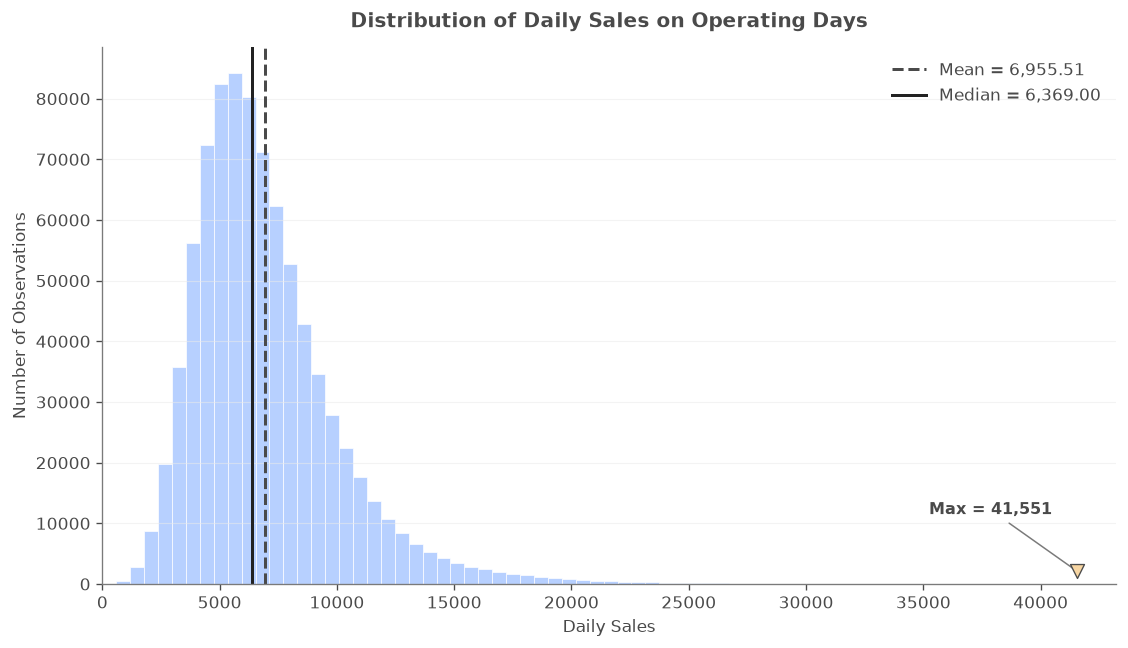

Figure saved to: d:\Coding\NTUHomeworks\AssignmentOfCA6000\outputs\figures\sales_distribution_open.png


In [4]:
# Visualize the distribution of Sales for operating days.

sales_open = (
    train_open["Sales"]
    .dropna()
)


# ------------------------------------------------------------
# 1. Retrieve reference statistics
# ------------------------------------------------------------

sales_mean = sales_open.mean()
sales_median = sales_open.median()
sales_max = sales_open.max()


# ------------------------------------------------------------
# 2. Create the histogram
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(9.5, 5.5)
)

counts, bin_edges, patches = ax.hist(
    sales_open,
    bins=70,
    color=PASTEL_BLUE,
    edgecolor="white",
    linewidth=0.45,
    alpha=0.90
)


# ------------------------------------------------------------
# 3. Add mean and median reference lines
# ------------------------------------------------------------

ax.axvline(
    sales_mean,
    color=DARK_GREY,
    linestyle="--",
    linewidth=1.8,
    label=f"Mean = {sales_mean:,.2f}"
)

ax.axvline(
    sales_median,
    color="#222222",
    linestyle="-",
    linewidth=1.8,
    label=f"Median = {sales_median:,.2f}"
)


# ------------------------------------------------------------
# 4. Mark the maximum observed value
# ------------------------------------------------------------

histogram_peak = counts.max()

max_marker_y = (
    histogram_peak * 0.025
)

ax.scatter(
    sales_max,
    max_marker_y,
    marker="v",
    s=70,
    color=PASTEL_ORANGE,
    edgecolor=DARK_GREY,
    linewidth=0.8,
    zorder=5
)

ax.annotate(
    f"Max = {sales_max:,.0f}",
    xy=(
        sales_max,
        max_marker_y
    ),
    xytext=(-15, 32),
    textcoords="offset points",
    ha="right",
    va="bottom",
    color=DARK_GREY,
    fontsize=9.5,
    fontweight="bold",
    arrowprops={
        "arrowstyle": "-",
        "color": MID_GREY,
        "linewidth": 0.9
    }
)


# ------------------------------------------------------------
# 5. Format the figure
# ------------------------------------------------------------

ax.set_title(
    "Distribution of Daily Sales on Operating Days",
    pad=12,
    fontweight="bold"
)

ax.set_xlabel(
    "Daily Sales"
)

ax.set_ylabel(
    "Number of Observations"
)

# Explicitly show the complete observed Sales range.
ax.set_xlim(
    left=0,
    right=sales_max * 1.04
)

ax.ticklabel_format(
    style="plain",
    axis="y"
)

ax.legend(
    loc="upper right"
)

ax.grid(
    axis="x",
    visible=False
)

ax.grid(
    axis="y",
    alpha=0.55
)

fig.tight_layout()


# ------------------------------------------------------------
# 6. Save and display
# ------------------------------------------------------------

figure_path = (
    FIGURES_DIR
    / "sales_distribution_open.png"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"Figure saved to: {figure_path}"
)

## 4. Boxplot Analysis of Operating-Day Sales

## Purpose

The histogram demonstrated that operating-day sales exhibit a long right tail.

A boxplot is further used to quantify the spread of Sales and identify observations beyond the conventional statistical outlier boundary.

Unlike the histogram, which focuses on the overall frequency distribution, the boxplot summarizes:

- median value;
- interquartile range;
- potential extreme observations.

## Input

The analysis uses:

- `train_open`

with:

- `Open = 1`

The variable analysed is:

- `Sales`

A total of **844,392** operating-day observations are included.

## Method

The boxplot is based on quartile statistics.

The interquartile range is defined as:

$$
IQR = Q_3-Q_1
$$

The lower and upper outlier boundaries are:

$$
Lower = Q_1-1.5\times IQR
$$

$$
Upper = Q_3+1.5\times IQR
$$

For operating-day Sales:

$$
Q_1=4,859
$$

$$
Q_3=8,360
$$

Therefore:

$$
IQR=8,360-4,859=3,501
$$

The upper boundary is:

$$
Upper=8,360+1.5\times3,501
$$

$$
=13,611.5
$$

Observations above this threshold are identified as statistical high-end outliers.

## Visualization Design

A pastel purple box is used to represent the central distribution.

Outlier observations are displayed with low-opacity markers because many high-sales observations exist. Reduced transparency prevents dense regions from visually dominating the figure.

Important statistics are represented using dark grey elements to maintain readability.

The full dataset range is retained. No observations are removed.

## Output

The figure is displayed in the notebook and saved as:

`outputs/figures/sales_boxplot_open.png`

## Evaluation

The boxplot is interpreted together with the histogram.

The main evaluation points are:

- whether the distribution has substantial asymmetry;
- the proportion of observations beyond the upper boundary;
- whether detected outliers represent errors or meaningful high-sales events.

Because the identified high-sales observations correspond to valid records, they are retained for subsequent modelling.

C:\Users\31729\AppData\Local\Temp\ipykernel_32120\1664490463.py:58: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


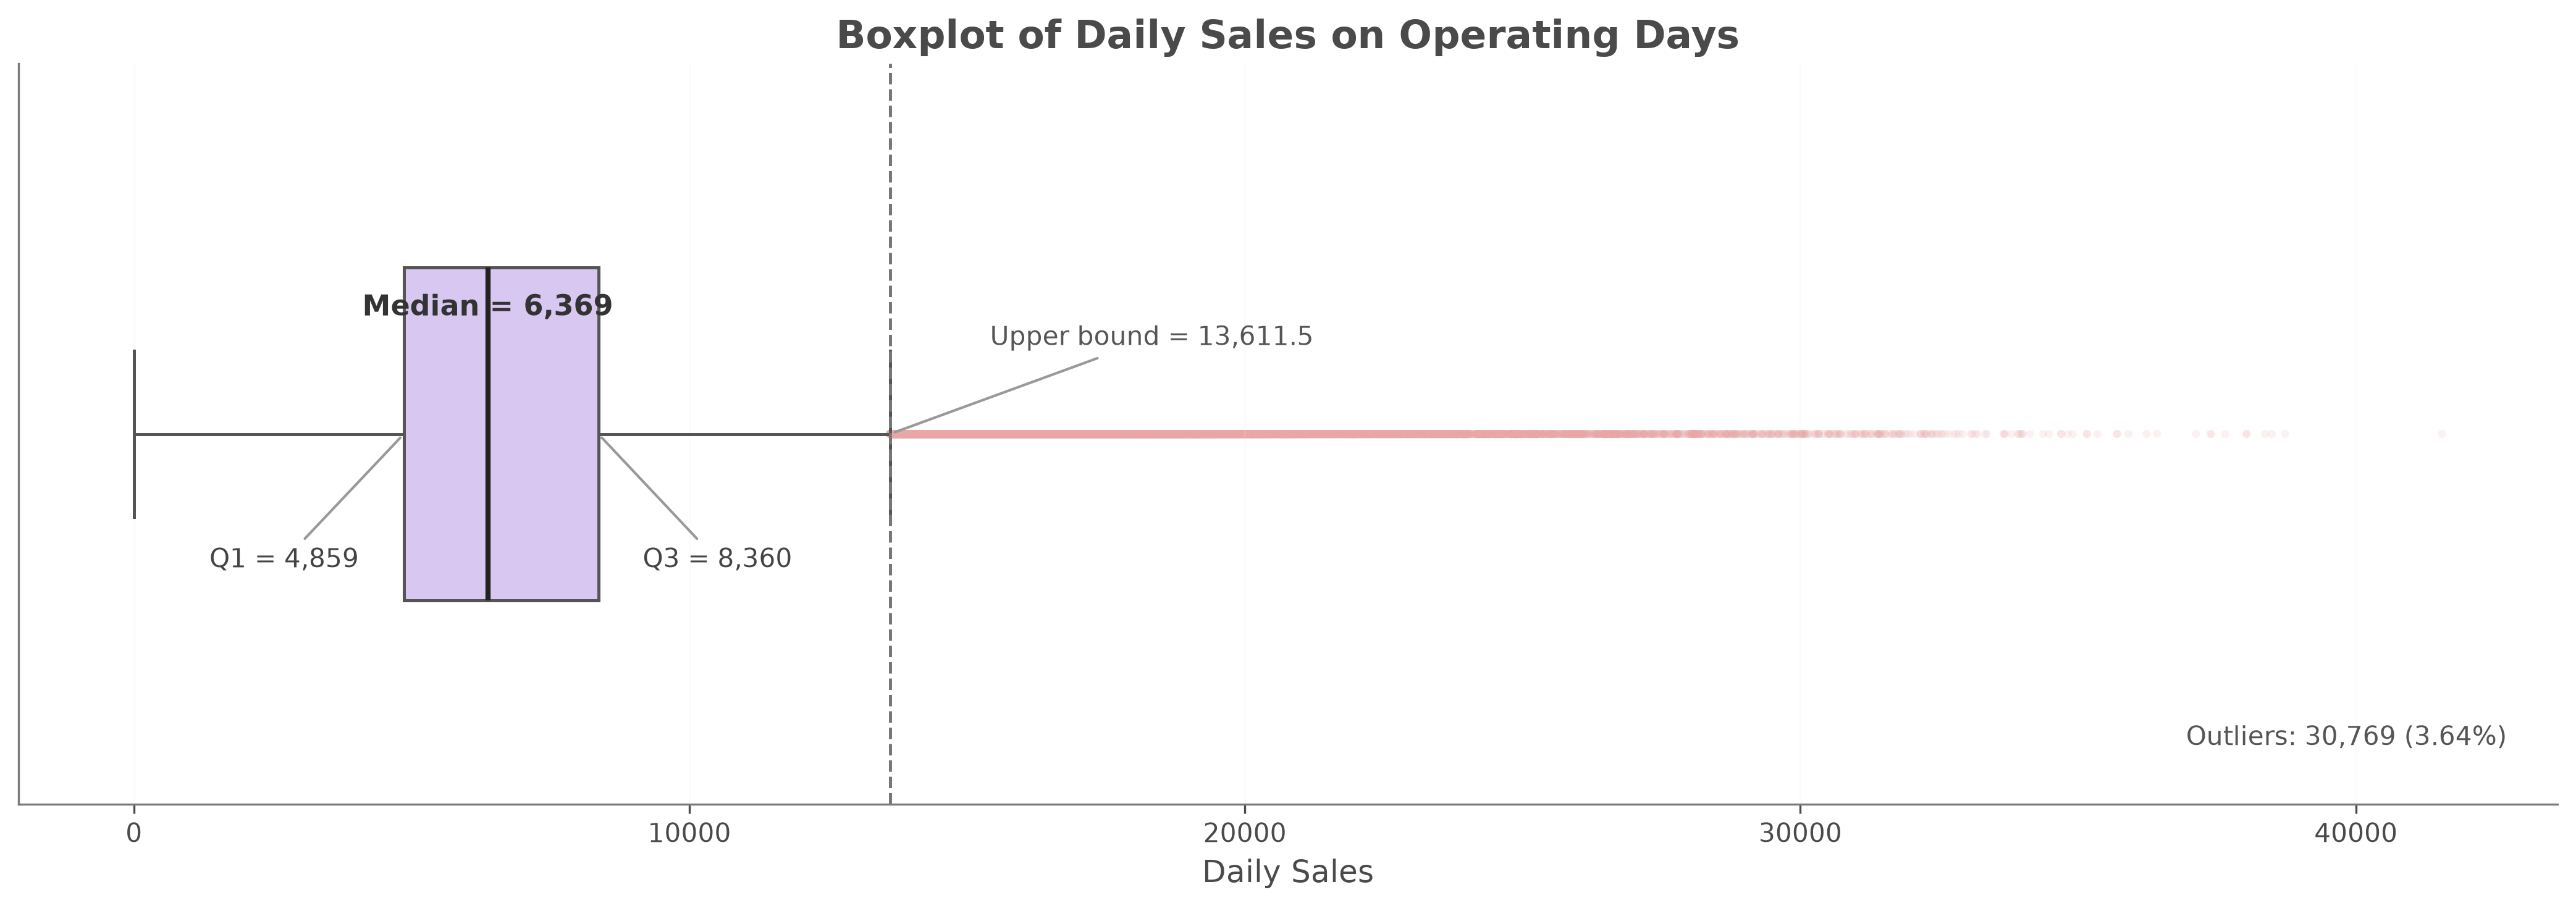

Q1: 4,859.00
Median: 6,369.00
Q3: 8,360.00
IQR: 3,501.00
Upper outlier boundary: 13,611.50
Outliers: 30,769 (3.64%)
Figure saved to: ../outputs/figures/sales_boxplot_open.png


In [12]:
import matplotlib.pyplot as plt
import numpy as np


# =========================================
# Boxplot of Daily Sales on Operating Days
# =========================================


# Select operating days only
sales_open = train.loc[
    train["Open"] == 1,
    "Sales"
]


# =========================================
# Calculate statistics
# =========================================

q1 = sales_open.quantile(0.25)
median = sales_open.quantile(0.50)
q3 = sales_open.quantile(0.75)

iqr = q3 - q1

upper_bound = q3 + 1.5 * iqr


# Outliers
outliers = sales_open[
    sales_open > upper_bound
]

outlier_count = len(outliers)

outlier_percentage = (
    outlier_count / len(sales_open) * 100
)



# =========================================
# Create figure
# =========================================

plt.figure(
    figsize=(14, 5),
    dpi=300
)



# =========================================
# Main boxplot
# =========================================

plt.boxplot(
    sales_open,
    vert=False,
    patch_artist=True,
    widths=0.45,
    showfliers=False,

    boxprops={
        "facecolor": "#D8C7F0",
        "edgecolor": "#555555",
        "linewidth": 1.2
    },

    medianprops={
        "color": "#222222",
        "linewidth": 2
    },

    whiskerprops={
        "color": "#555555",
        "linewidth": 1.2
    },

    capprops={
        "color": "#555555",
        "linewidth": 1.2
    }
)



# =========================================
# Plot outliers
# =========================================

plt.scatter(
    outliers,
    np.ones(len(outliers)),
    s=10,
    color="#E8A6A6",
    alpha=0.15,
    edgecolors="none"
)



# =========================================
# Annotation
# =========================================


# Median
plt.text(
    median,
    1.16,
    f"Median = {median:,.0f}",
    ha="center",
    fontsize=11,
    fontweight="bold",
    color="#333333"
)



# Q1
plt.annotate(
    f"Q1 = {q1:,.0f}",
    xy=(q1, 1),
    xytext=(q1-3500, 0.82),

    fontsize=10,
    color="#444444",

    arrowprops={
        "arrowstyle": "-",
        "color": "#999999"
    }
)



# Q3
plt.annotate(
    f"Q3 = {q3:,.0f}",
    xy=(q3, 1),
    xytext=(q3+800, 0.82),

    fontsize=10,
    color="#444444",

    arrowprops={
        "arrowstyle": "-",
        "color": "#999999"
    }
)



# Upper outlier boundary

plt.axvline(
    upper_bound,
    linestyle="--",
    linewidth=1.2,
    color="#777777"
)


plt.annotate(
    f"Upper bound = {upper_bound:,.1f}",

    xy=(upper_bound, 1),

    xytext=(
        upper_bound + 1800,
        1.12
    ),

    fontsize=10,
    color="#555555",

    arrowprops={
        "arrowstyle": "-",
        "color": "#999999"
    }
)



# Outlier summary

plt.text(
    0.98,
    0.08,

    f"Outliers: {outlier_count:,} "
    f"({outlier_percentage:.2f}%)",

    transform=plt.gca().transAxes,

    ha="right",

    fontsize=10,

    color="#555555"
)



# =========================================
# Style
# =========================================


plt.title(
    "Boxplot of Daily Sales on Operating Days",

    fontsize=15,

    fontweight="bold"
)


plt.xlabel(
    "Daily Sales",

    fontsize=12
)


plt.yticks([])


plt.grid(
    axis="x",
    alpha=0.15
)


plt.tight_layout()



# =========================================
# Save
# =========================================

output_path = (
    "../outputs/figures/"
    "sales_boxplot_open.png"
)


plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)


plt.show()



# =========================================
# Audit output
# =========================================

print(f"Q1: {q1:,.2f}")
print(f"Median: {median:,.2f}")
print(f"Q3: {q3:,.2f}")
print(f"IQR: {iqr:,.2f}")
print(f"Upper outlier boundary: {upper_bound:,.2f}")

print(
    f"Outliers: {outlier_count:,} "
    f"({outlier_percentage:.2f}%)"
)

print(
    f"Figure saved to: {output_path}"
)

# 5. Temporal Pattern Analysis

## 5.1 Daily Average Sales Trend

## Purpose

Retail sales are usually affected by temporal factors, including long-term trends, seasonal changes and calendar effects.

This section investigates whether daily sales performance changes systematically over the observation period.

Instead of using total daily sales, the average sales per operating store is calculated to remove the influence of the number of open stores on a given day.

## Input

The analysis uses:

- Cleaned daily transaction dataset

Variables:

- `Date`
- `Store`
- `Sales`
- `Open`

Only observations with:

`Open = 1`

are included.

## Method

For each date, average sales per operating store are calculated as:

$$
\bar{S_t}
=
\frac{
\sum_{i=1}^{n_t} Sales_{i,t}
}
{
n_t
}
$$

where:

- $S_t$ represents average sales on date $t$;
- $n_t$ represents the number of stores operating on date $t$.

This normalization prevents changes in the number of operating stores from being interpreted as changes in sales performance.

## Visualization Design

A line plot is selected because the objective is to observe changes over a continuous time axis.

The line represents daily average sales.

A pastel blue line is used to maintain consistency with the project visualization style.

No smoothing is applied because the purpose is to preserve the actual temporal variation.

## Output

The figure:

- is displayed in the notebook;
- is saved as:

`outputs/figures/daily_average_sales_trend.png`

## Evaluation

The temporal trend is evaluated based on:

- overall growth or decline;
- periodic fluctuations;
- abnormal sales peaks;
- potential seasonal patterns.

The observed temporal characteristics will guide later feature engineering and model development.

In [13]:
import matplotlib.pyplot as plt
import pandas as pd


# =====================================
# Prepare daily average sales
# =====================================


daily_sales = (
    train
    .loc[train["Open"] == 1]
    .groupby("Date")
    .agg(
        AverageSales=("Sales", "mean"),
        OpenStores=("Store", "nunique")
    )
    .reset_index()
)


daily_sales.head()

,Date,AverageSales,OpenStores
0,2013-01-01,5719.705882,17
1,2013-01-02,6255.471647,1111
2,2013-01-03,5723.913436,1109
3,2013-01-04,5991.835740,1108
4,2013-01-05,5376.326107,1107


C:\Users\31729\AppData\Local\Temp\ipykernel_32120\4086895493.py:17: DtypeWarning: Columns (0: StateHoliday) have mixed types. Specify dtype option on import or set low_memory=False.
  train_clean = pd.read_csv(


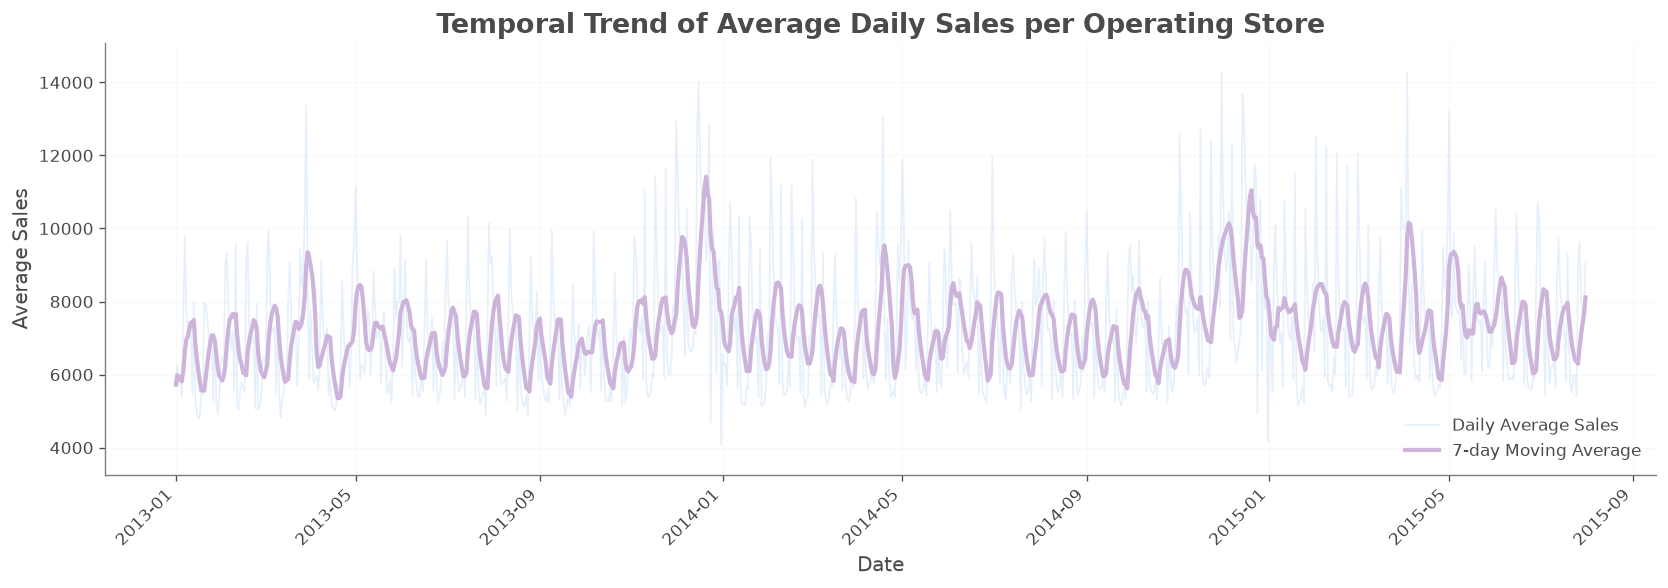

Figure saved to: ../outputs/figures/daily_average_sales_trend_ma7.png


,Date,AverageSales,OpenStores,MA7
0,2013-01-01,5719.705882,17,5719.705882
1,2013-01-02,6255.471647,1111,5987.588765
2,2013-01-03,5723.913436,1109,5899.696988
3,2013-01-04,5991.835740,1108,5922.731676
4,2013-01-05,5376.326107,1107,5813.450562



Calculation:

Daily Average Sales:

AverageSales_t =
Σ Sales_t / Number of Operating Stores_t


7-day Moving Average:

MA7_t =
(AverageSales_t-6 + ... + AverageSales_t) / 7




In [17]:
# ==========================================
# 03 EDA - Temporal Pattern Analysis
# Daily Average Sales Trend with 7-day Moving Average
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt
import os


# ------------------------------------------
# 1. Load cleaned dataset
# ------------------------------------------

TRAIN_CLEAN_PATH = "../data/processed/train_clean.csv"

train_clean = pd.read_csv(
    TRAIN_CLEAN_PATH
)


# Convert date format

train_clean["Date"] = pd.to_datetime(
    train_clean["Date"]
)


# ------------------------------------------
# 2. Calculate daily average sales
#    considering operating stores only
# ------------------------------------------

daily_sales = (
    train_clean[train_clean["Open"] == 1]
    .groupby("Date")
    .agg(
        AverageSales=("Sales", "mean"),
        OpenStores=("Store", "count")
    )
    .reset_index()
)


daily_sales = daily_sales.sort_values(
    "Date"
)


# ------------------------------------------
# 3. Calculate 7-day moving average
# ------------------------------------------

daily_sales["MA7"] = (
    daily_sales["AverageSales"]
    .rolling(
        window=7,
        min_periods=1
    )
    .mean()
)


# ------------------------------------------
# 4. Plot
# ------------------------------------------

plt.figure(
    figsize=(14,5)
)


# Raw daily values

plt.plot(
    daily_sales["Date"],
    daily_sales["AverageSales"],
    color="#B7D4F5",
    linewidth=1,
    alpha=0.35,
    label="Daily Average Sales"
)


# Moving average

plt.plot(
    daily_sales["Date"],
    daily_sales["MA7"],
    color="#CDB4DB",
    linewidth=2.5,
    label="7-day Moving Average"
)


# ------------------------------------------
# 5. Formatting
# ------------------------------------------

plt.title(
    "Temporal Trend of Average Daily Sales per Operating Store",
    fontsize=16,
    fontweight="bold"
)


plt.xlabel(
    "Date",
    fontsize=12
)


plt.ylabel(
    "Average Sales",
    fontsize=12
)


# Do not start y-axis from zero
# Preserve visual variation

y_min = daily_sales["AverageSales"].min()
y_max = daily_sales["AverageSales"].max()

margin = (y_max-y_min)*0.08


plt.ylim(
    y_min-margin,
    y_max+margin
)


plt.grid(
    alpha=0.25
)


plt.legend(
    frameon=False
)


plt.xticks(
    rotation=45,
    ha="right"
)


plt.tight_layout()


# ------------------------------------------
# 6. Save figure
# ------------------------------------------

FIGURE_PATH = "../outputs/figures/daily_average_sales_trend_ma7.png"


os.makedirs(
    "../outputs/figures",
    exist_ok=True
)


plt.savefig(
    FIGURE_PATH,
    dpi=300,
    bbox_inches="tight"
)


plt.show()


print(
    f"Figure saved to: {FIGURE_PATH}"
)


# ------------------------------------------
# 7. Display calculated data
# ------------------------------------------

display(
    daily_sales.head()
)


print(
"""
Calculation:

Daily Average Sales:

AverageSales_t =
Σ Sales_t / Number of Operating Stores_t


7-day Moving Average:

MA7_t =
(AverageSales_t-6 + ... + AverageSales_t) / 7

"""
)

## 5.2 Weekly Seasonality Analysis

### Purpose

Daily sales may vary systematically depending on the day of week.
This section investigates whether weekly purchasing patterns exist.

### Method

Operating-day sales are grouped by `DayOfWeek`.
Boxplots are used to compare sales distributions across weekdays,
while mean values are calculated and displayed to quantify average differences.

The mean daily sales for each weekday are calculated as:

$$
\bar{x}_{d}=
\frac{\sum_{i=1}^{n_d}x_i}{n_d}
$$

where:

- $d$ represents the weekday,
- $n_d$ represents the number of observations for that weekday,
- $x_i$ represents daily sales observations.

The interquartile range (IQR) is used to describe variability:

$$
IQR=Q_3-Q_1
$$

where $Q_1$ and $Q_3$ represent the 25th and 75th percentiles.

In [18]:
# ============================================================
# 5.2 Weekly Seasonality Analysis
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# -----------------------------
# Load cleaned dataset
# -----------------------------

train_clean = pd.read_csv(
    "../data/processed/train_clean.csv"
)


train_clean["Date"] = pd.to_datetime(
    train_clean["Date"]
)


# -----------------------------
# Select operating days only
# -----------------------------

sales_open = train_clean[
    train_clean["Open"] == 1
].copy()


# -----------------------------
# Weekday mapping
# -----------------------------

weekday_labels = {
    1: "Mon",
    2: "Tue",
    3: "Wed",
    4: "Thu",
    5: "Fri",
    6: "Sat",
    7: "Sun"
}


sales_open["Weekday"] = (
    sales_open["DayOfWeek"]
    .map(weekday_labels)
)


# -----------------------------
# Summary statistics
# -----------------------------

weekday_stats = (
    sales_open
    .groupby("Weekday")["Sales"]
    .agg(
        Count="count",
        Mean="mean",
        Median="median",
        Q1=lambda x: x.quantile(0.25),
        Q3=lambda x: x.quantile(0.75)
    )
)


weekday_stats["IQR"] = (
    weekday_stats["Q3"]
    -
    weekday_stats["Q1"]
)


# keep weekday order

weekday_order = [
    "Mon",
    "Tue",
    "Wed",
    "Thu",
    "Fri",
    "Sat",
    "Sun"
]


weekday_stats = (
    weekday_stats
    .loc[weekday_order]
)


weekday_stats

C:\Users\31729\AppData\Local\Temp\ipykernel_32120\599603827.py:14: DtypeWarning: Columns (0: StateHoliday) have mixed types. Specify dtype option on import or set low_memory=False.
  train_clean = pd.read_csv(


,Count,Mean,Median,Q1,Q3,IQR
Weekday,,,,,,
Mon,137560,8216.073074,7539.0,5538.0,10133.0,4595.0
Tue,143961,7088.113656,6502.0,4960.0,8521.0,3561.0
Wed,141936,6728.122978,6210.0,4829.0,7987.0,3158.0
Thu,134644,6767.310159,6246.0,4900.0,7987.0,3087.0
Fri,138640,7072.677012,6580.0,5205.0,8324.0,3119.0
Sat,144058,5874.840238,5425.0,3925.0,7232.0,3307.0
Sun,3593,8224.723908,6876.0,3314.0,11418.0,8104.0


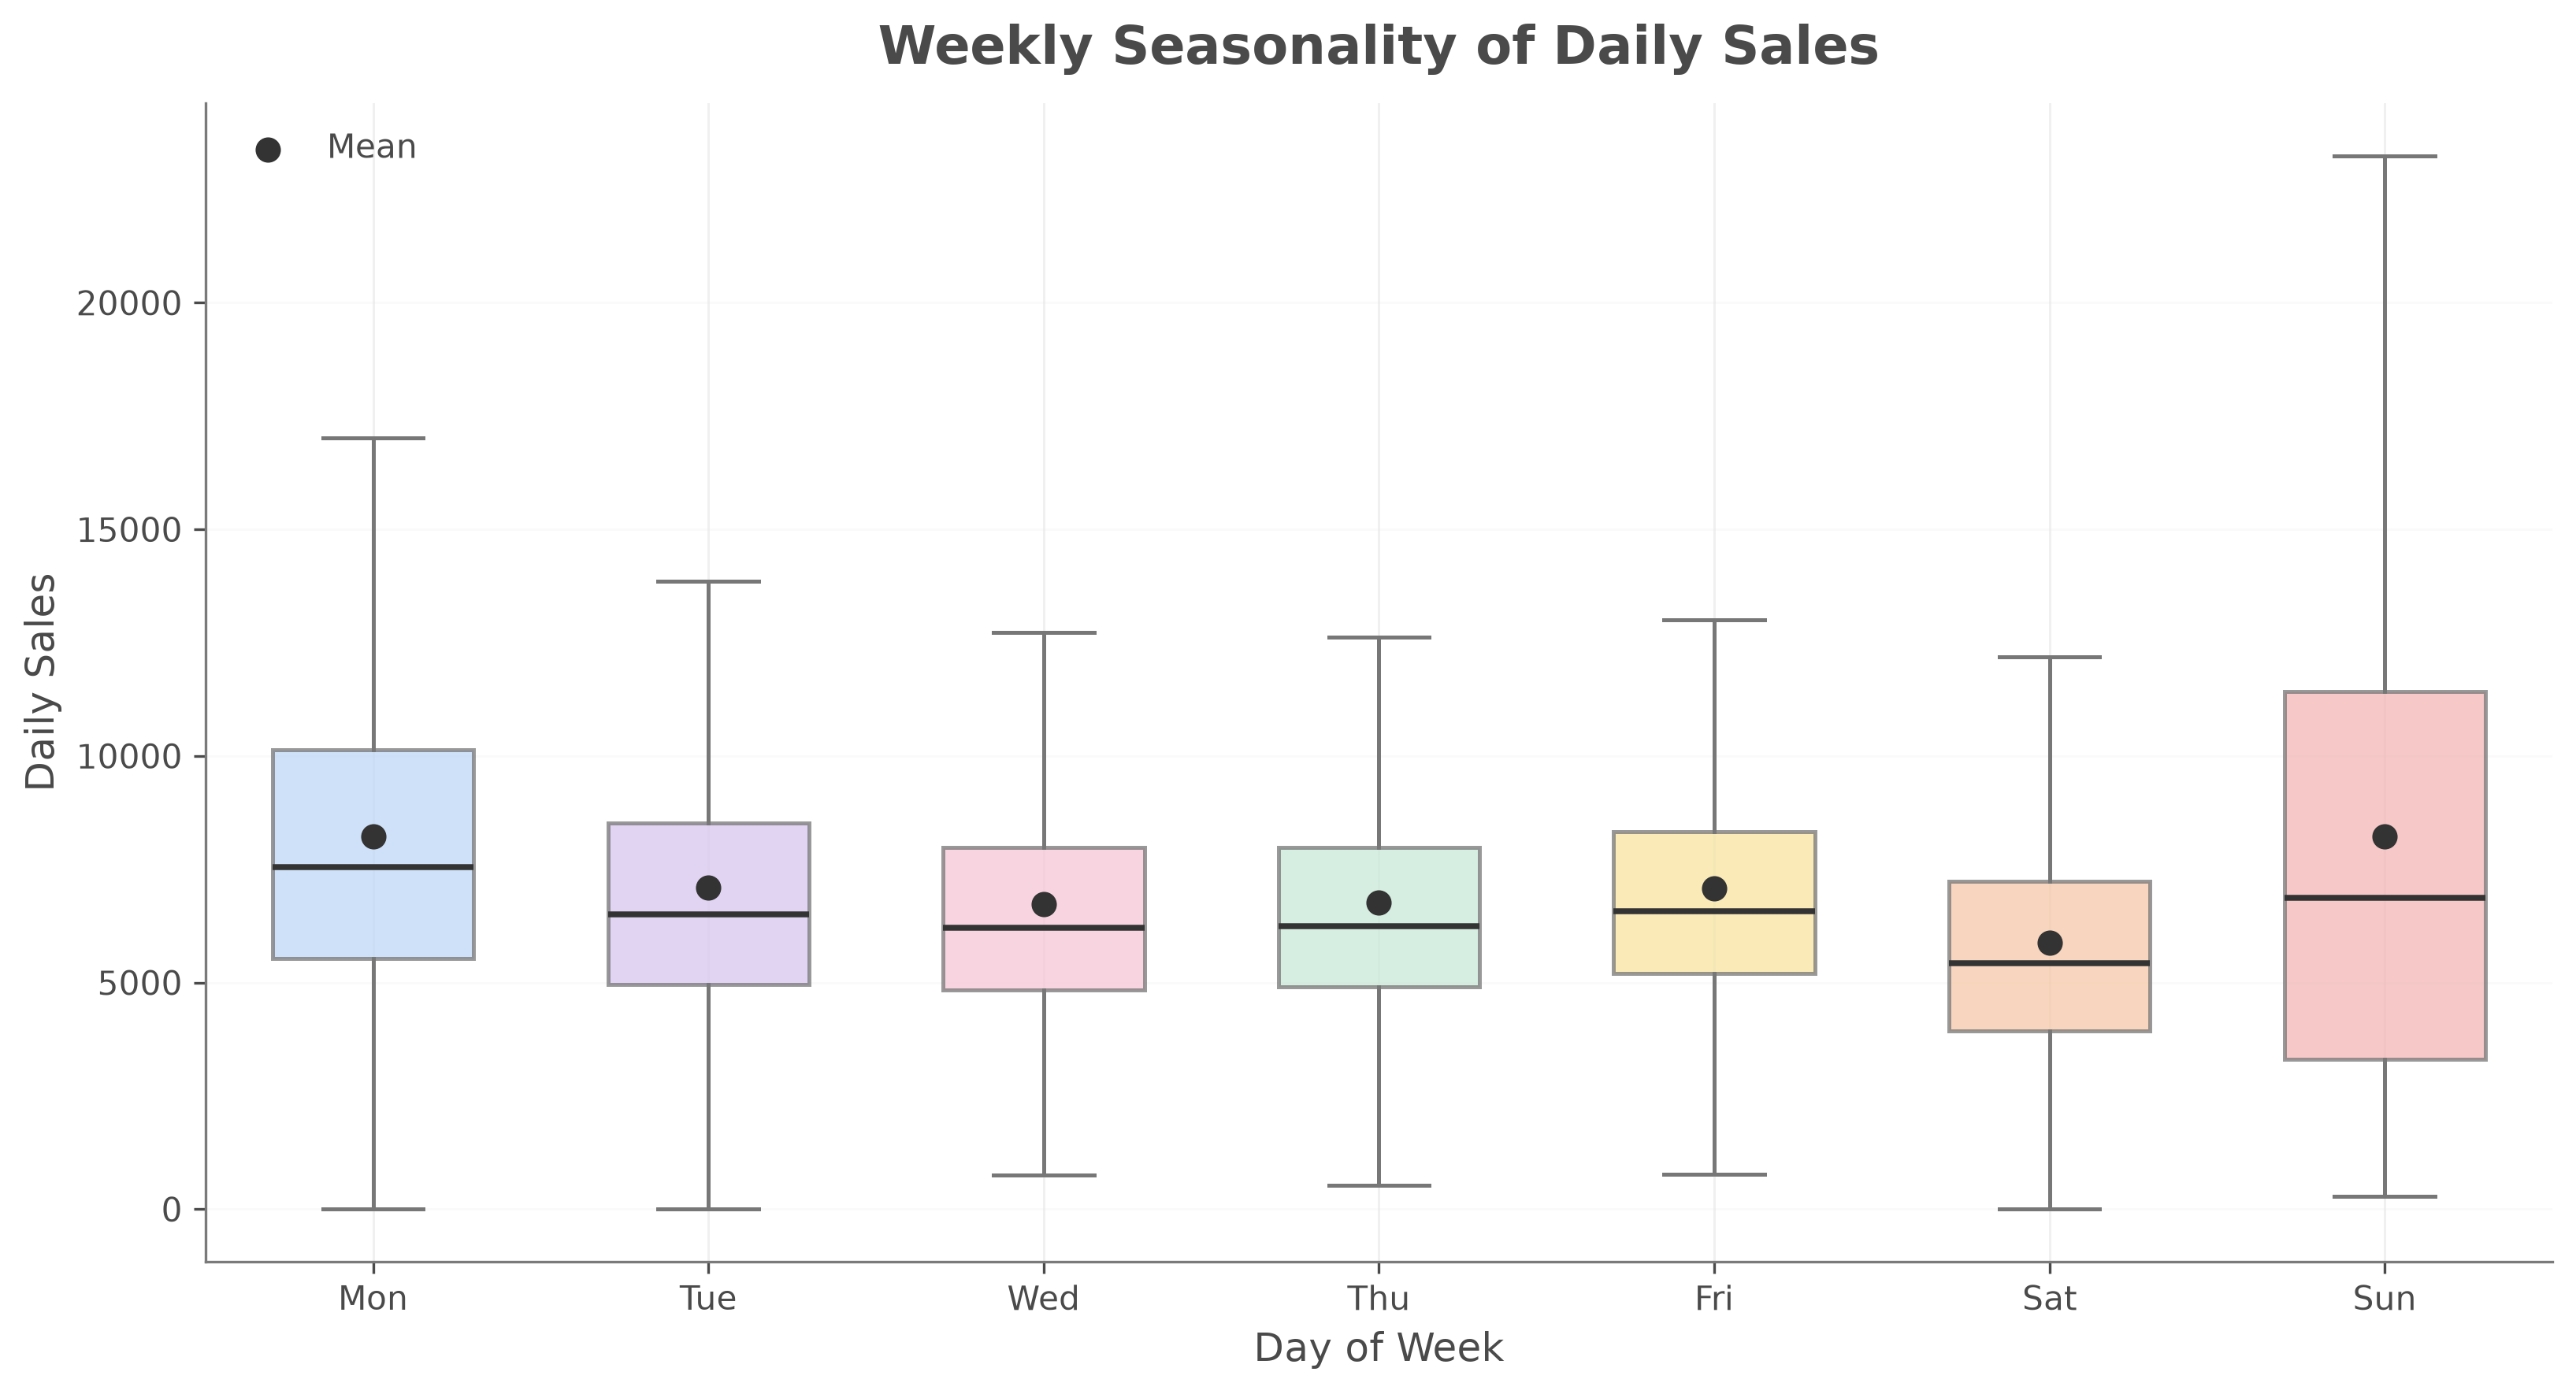

Figure saved to: ../outputs/figures/weekday_sales_boxplot.png


In [20]:
# ============================================================
# 5.2 Weekly Seasonality Analysis
# Boxplot of Daily Sales by Day of Week
# ============================================================


import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Prepare boxplot data
# ------------------------------------------------------------

weekday_order = [
    "Mon",
    "Tue",
    "Wed",
    "Thu",
    "Fri",
    "Sat",
    "Sun"
]


box_data = [
    sales_open.loc[
        sales_open["Weekday"] == day,
        "Sales"
    ]
    for day in weekday_order
]


# ------------------------------------------------------------
# Create figure
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(11, 6),
    dpi=300
)


# ------------------------------------------------------------
# Pastel SCI colors
# ------------------------------------------------------------

colors = [
    "#BFD7F6",  # soft blue
    "#D8C6F0",  # soft purple
    "#F5C6D6",  # soft pink
    "#C9E7D8",  # soft green
    "#F7E3A1",  # soft yellow
    "#F6C8A8",  # soft orange
    "#F3B6B6"   # soft rose
]


# ------------------------------------------------------------
# Boxplot
# ------------------------------------------------------------

bp = ax.boxplot(
    box_data,

    # matplotlib >= 3.11
    tick_labels=weekday_order,

    patch_artist=True,

    # hide extreme points
    showfliers=False,

    widths=0.6,

    medianprops={
        "color": "#333333",
        "linewidth": 1.8
    },

    whiskerprops={
        "color": "#777777",
        "linewidth": 1.2
    },

    capprops={
        "color": "#777777",
        "linewidth": 1.2
    },

    boxprops={
        "color": "#777777",
        "linewidth": 1.2
    }
)


# Apply pastel colors

for patch, color in zip(
    bp["boxes"],
    colors
):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)



# ------------------------------------------------------------
# Add mean points
# ------------------------------------------------------------

weekday_mean = (
    sales_open
    .groupby("Weekday")["Sales"]
    .mean()
    .reindex(weekday_order)
)


ax.scatter(
    range(1, 8),
    weekday_mean,

    color="#333333",

    s=45,

    zorder=3,

    label="Mean"
)



# ------------------------------------------------------------
# Style
# ------------------------------------------------------------

ax.set_title(
    "Weekly Seasonality of Daily Sales",
    fontsize=16,
    fontweight="bold",
    pad=12
)


ax.set_xlabel(
    "Day of Week",
    fontsize=12
)


ax.set_ylabel(
    "Daily Sales",
    fontsize=12
)


ax.grid(
    axis="y",
    alpha=0.2
)


ax.legend(
    frameon=False,
    fontsize=10
)


plt.tight_layout()



# ------------------------------------------------------------
# Save figure
# ------------------------------------------------------------

output_path = (
    "../outputs/figures/"
    "weekday_sales_boxplot.png"
)


plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)


plt.show()


print(
    f"Figure saved to: {output_path}"
)

### Weekly seasonality

A boxplot was used to compare sales distributions across different days of the week.

The median and interquartile range were used to describe the central tendency and variability, while black dots represent mean sales values.

The results indicate noticeable weekly differences. Monday shows relatively higher sales levels, whereas Saturday has lower typical sales. Sunday exhibits the largest variability, suggesting heterogeneous store operation patterns.

However, substantial overlap among weekday distributions indicates that day-of-week alone is unlikely to fully explain sales variation.

# 6. Relationship Between Customers and Sales

## Purpose

The previous sections analysed the distribution and temporal characteristics of daily sales. 
However, sales performance is not only determined by time-related factors, but also by operational factors.

Customer traffic is expected to be one of the most important drivers of retail sales. 
This section investigates the relationship between the number of customers and daily sales to understand whether higher customer traffic generally corresponds to higher sales.

The analysis provides evidence for later feature engineering, where `Customers` may be included as an important predictive variable in the neural network model.

## Input

The analysis uses:

- `train_clean`

Only operating-day observations are considered:

\[
Open = 1
\]

because closed stores naturally have:

\[
Sales = 0,\quad Customers = 0
\]

which would distort the relationship between customer traffic and sales performance.

## Method

Three aspects are examined:

1. Correlation analysis between `Customers` and `Sales`;
2. Scatter plot analysis to observe the overall relationship pattern;
3. Customer-volume grouping analysis to compare average sales under different customer levels.

The Pearson correlation coefficient is calculated as:

$$
r =
\frac{
\sum_{i=1}^{n}(x_i-\bar{x})(y_i-\bar{y})
}
{
\sqrt{\sum_{i=1}^{n}(x_i-\bar{x})^2}
\sqrt{\sum_{i=1}^{n}(y_i-\bar{y})^2}
}
$$

where:

- \(x_i\) represents daily customer numbers;
- \(y_i\) represents daily sales;
- \(r\) measures the linear association between customers and sales.

A positive correlation indicates that higher customer traffic tends to be associated with higher sales.

## Visualization

A scatter plot is used to display the relationship between customers and sales.

The figure follows the visualization requirements of this project:

- clear representation of data characteristics is the primary objective;
- a scientific and clean visual style is adopted;
- pastel colours are used where appropriate;
- figures are saved both inside the notebook and separately under:


Pearson correlation between Customers and Sales: 0.8236


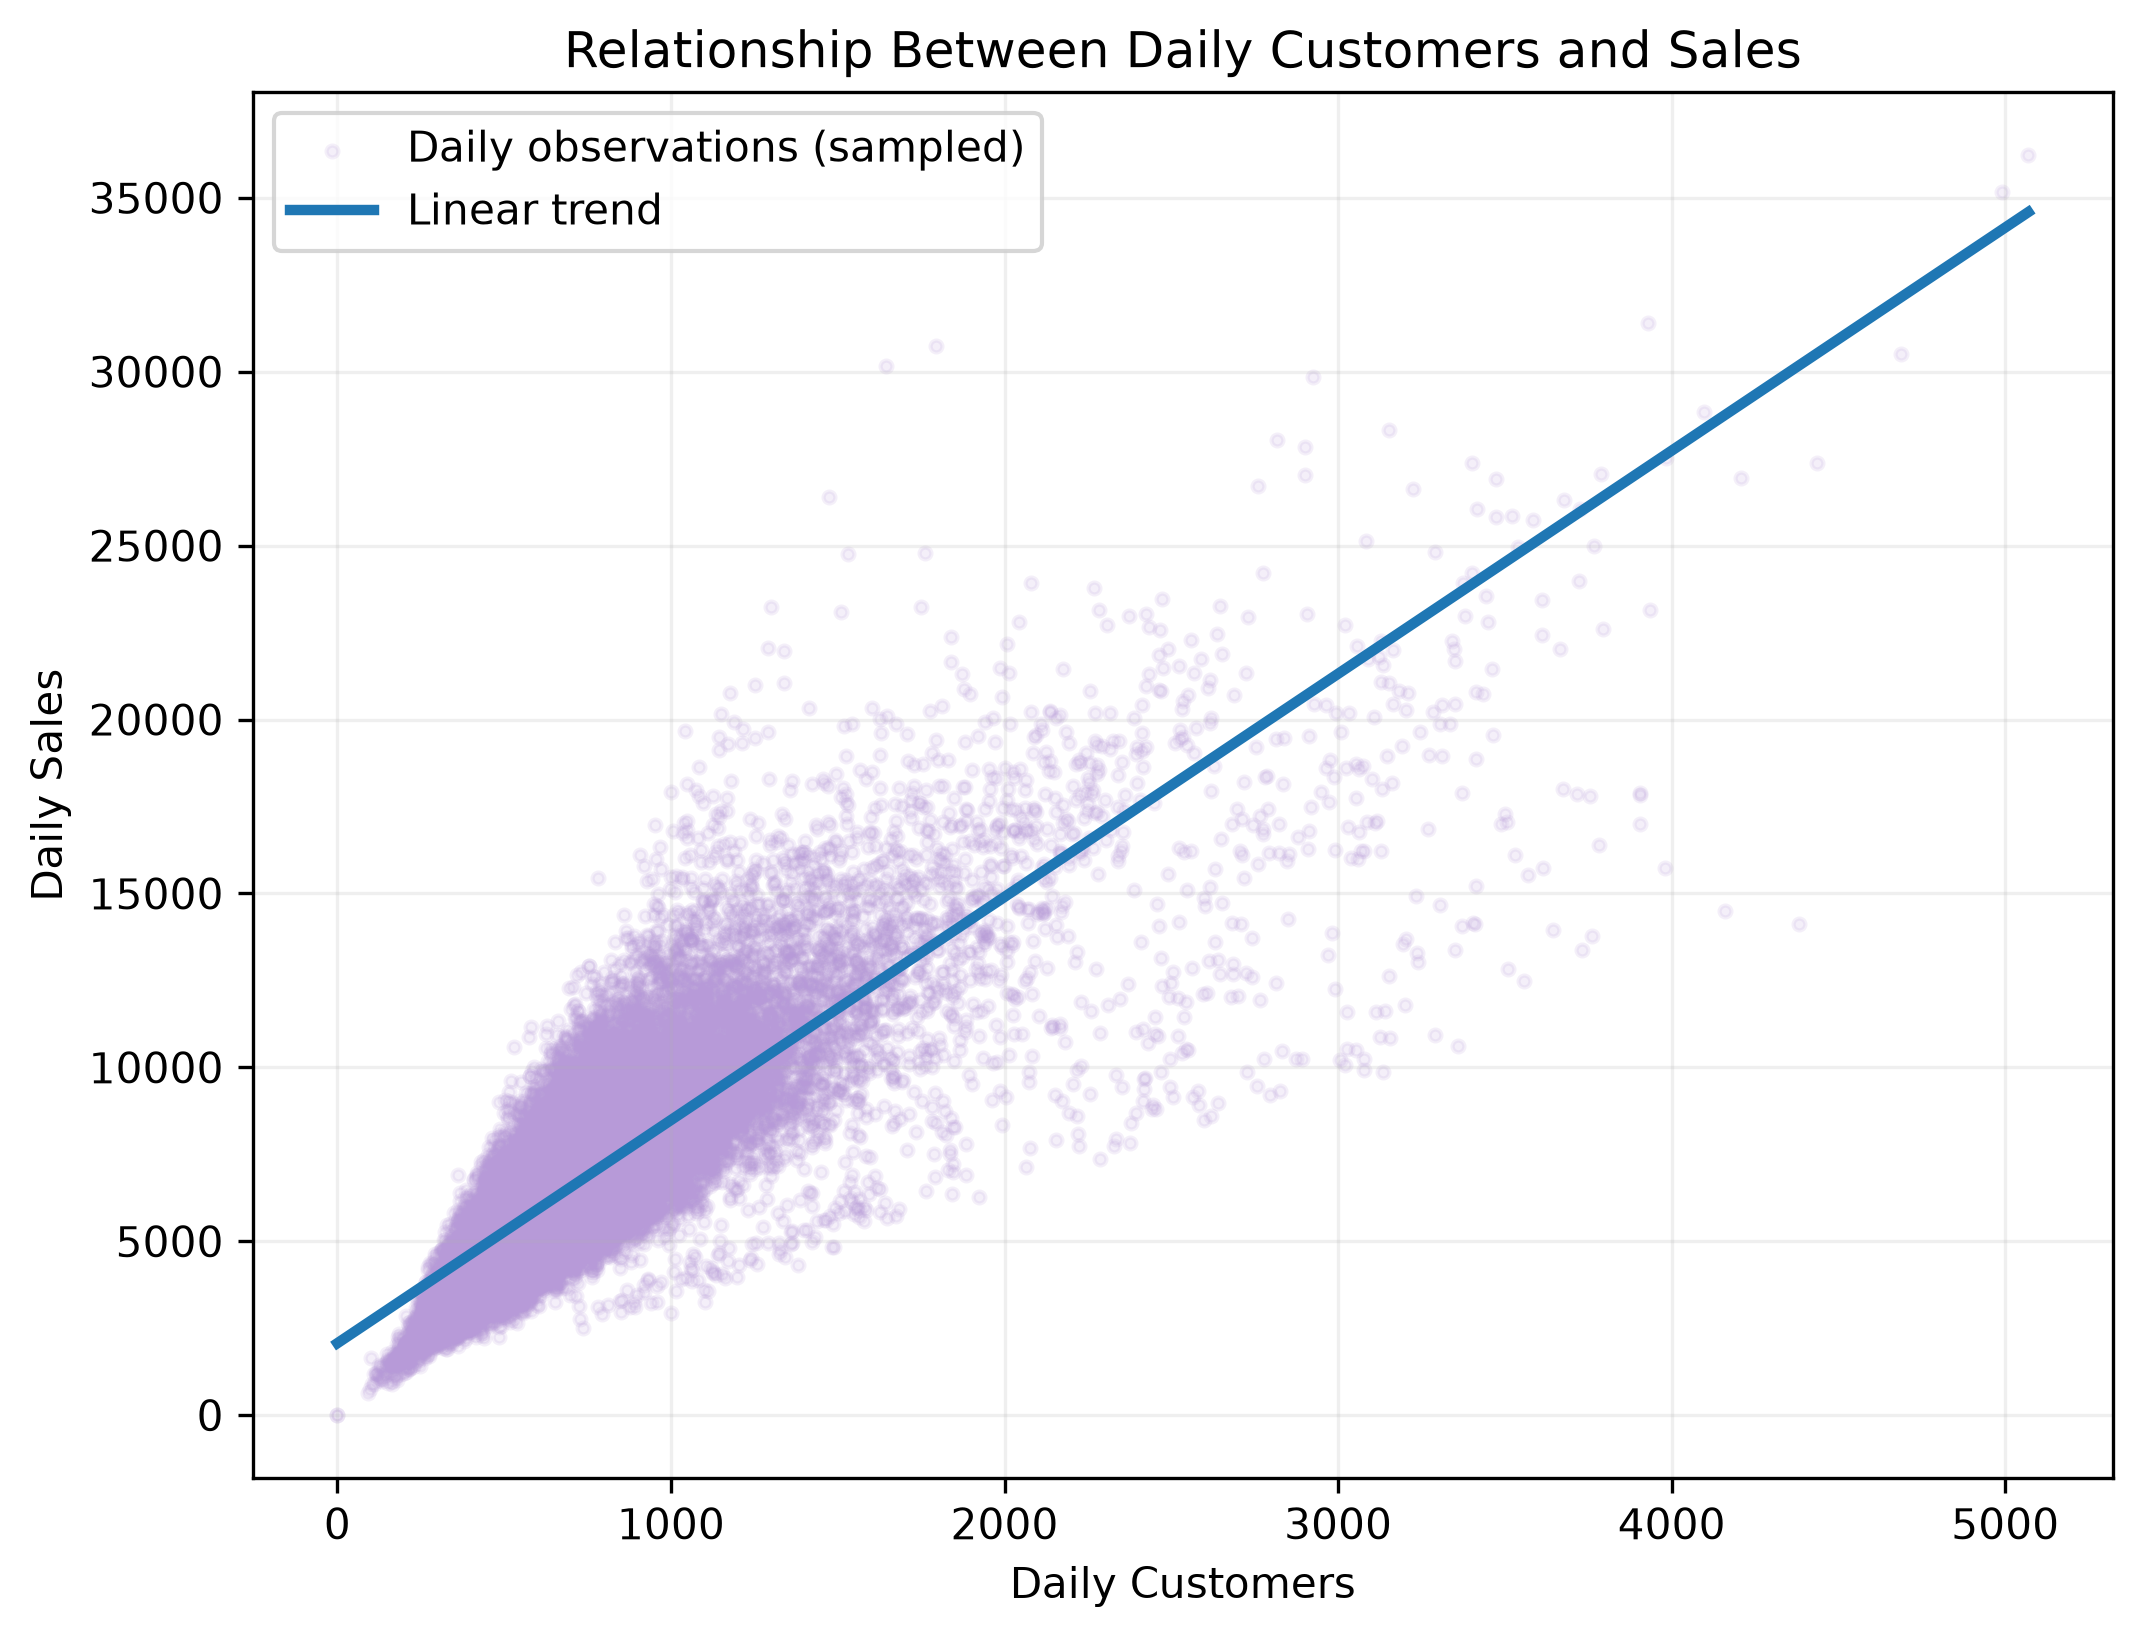

In [4]:
# ============================================================
# 6. Relationship Between Customers and Sales
# Correlation Analysis and Scatter Visualization
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


# ------------------------------------------------------------
# 1. Load cleaned dataset
# ------------------------------------------------------------

train_clean = pd.read_csv(
    "../data/processed/train_clean.csv",
    dtype={
        "StateHoliday": "string"
    },
    low_memory=False
)

train_clean["Date"] = pd.to_datetime(
    train_clean["Date"]
)


# ------------------------------------------------------------
# 2. Select operating-day observations
# ------------------------------------------------------------

train_open = train_clean.loc[
    train_clean["Open"] == 1
].copy()


# ------------------------------------------------------------
# 3. Pearson correlation
# ------------------------------------------------------------

customer_sales_corr = train_open[
    "Customers"
].corr(
    train_open["Sales"],
    method="pearson"
)


print(
    f"Pearson correlation between Customers and Sales: "
    f"{customer_sales_corr:.4f}"
)


# ------------------------------------------------------------
# 4. Figure directory
# ------------------------------------------------------------

FIGURE_DIR = Path(
    "../outputs/figures"
)

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------
# 5. Sampling
# ------------------------------------------------------------

sample_size = min(
    30000,
    len(train_open)
)


sample_df = train_open.sample(
    n=sample_size,
    random_state=42
)


# ------------------------------------------------------------
# 6. Scatter plot
# ------------------------------------------------------------

plt.figure(
    figsize=(8,6),
    dpi=300
)


plt.scatter(
    sample_df["Customers"],
    sample_df["Sales"],
    alpha=0.15,
    s=8,
    color="#B79AD8",
    label="Daily observations (sampled)"
)


# ------------------------------------------------------------
# 7. Linear regression trend
# ------------------------------------------------------------

z = np.polyfit(
    sample_df["Customers"],
    sample_df["Sales"],
    1
)

p = np.poly1d(z)


x_line = np.linspace(
    sample_df["Customers"].min(),
    sample_df["Customers"].max(),
    200
)


plt.plot(
    x_line,
    p(x_line),
    linewidth=2.5,
    color="#1F77B4",
    label="Linear trend"
)


# ------------------------------------------------------------
# 8. Formatting
# ------------------------------------------------------------

plt.xlabel(
    "Daily Customers"
)

plt.ylabel(
    "Daily Sales"
)


plt.title(
    "Relationship Between Daily Customers and Sales"
)


plt.legend(
    frameon=True
)


plt.grid(
    alpha=0.2
)


# ------------------------------------------------------------
# 9. Save figure
# ------------------------------------------------------------

plt.savefig(
    FIGURE_DIR / "customers_sales_scatter.png",
    bbox_inches="tight"
)


plt.show()

# 7. Impact of Promotion on Sales Performance

## Purpose

The previous analysis demonstrated that customer traffic has a strong positive relationship with sales. 
However, customer volume alone cannot fully explain sales variation, indicating that other operational factors may also influence sales performance.

Promotion activity is an important managerial decision variable in retail operations. 
This section investigates whether promotional campaigns are associated with higher daily sales.

Understanding the effect of promotion is important for two reasons:

1. It helps explain variations in historical sales data;
2. It provides evidence for selecting meaningful features for the later neural network prediction model.

## Input

The analysis uses the cleaned training dataset:

- `train_clean`

Only operating-day observations are considered:

\[
Open = 1
\]

because closed stores naturally have zero sales and are not meaningful for evaluating promotion effectiveness.

The key variable is:

- `Promo`

where:

- `Promo = 1`: promotion is active;
- `Promo = 0`: no promotion.

## Method

Sales distributions under two promotion conditions are compared.

The following statistics are calculated:

- Mean sales;
- Median sales;
- Number of observations.

The difference between promotion and non-promotion groups is examined using descriptive comparison.

The mean sales value is calculated as:

$$
\bar{S}
=
\frac{1}{n}
\sum_{i=1}^{n}S_i
$$

where:

- \(S_i\) represents daily sales;
- \(n\) represents the number of observations.

## Visualization

A boxplot is used to compare sales distributions between promotion and non-promotion days.

The visualization follows the project requirements:

- clear representation of data characteristics is the primary objective;
- scientific and clean style is adopted;
- pastel colours are used;
- the figure is saved both inside the notebook and separately under:


        count         mean  median          std
Promo                                          
0      467496  5929.407603  5459.0  2629.648385
1      376896  8228.281239  7649.0  3175.759157


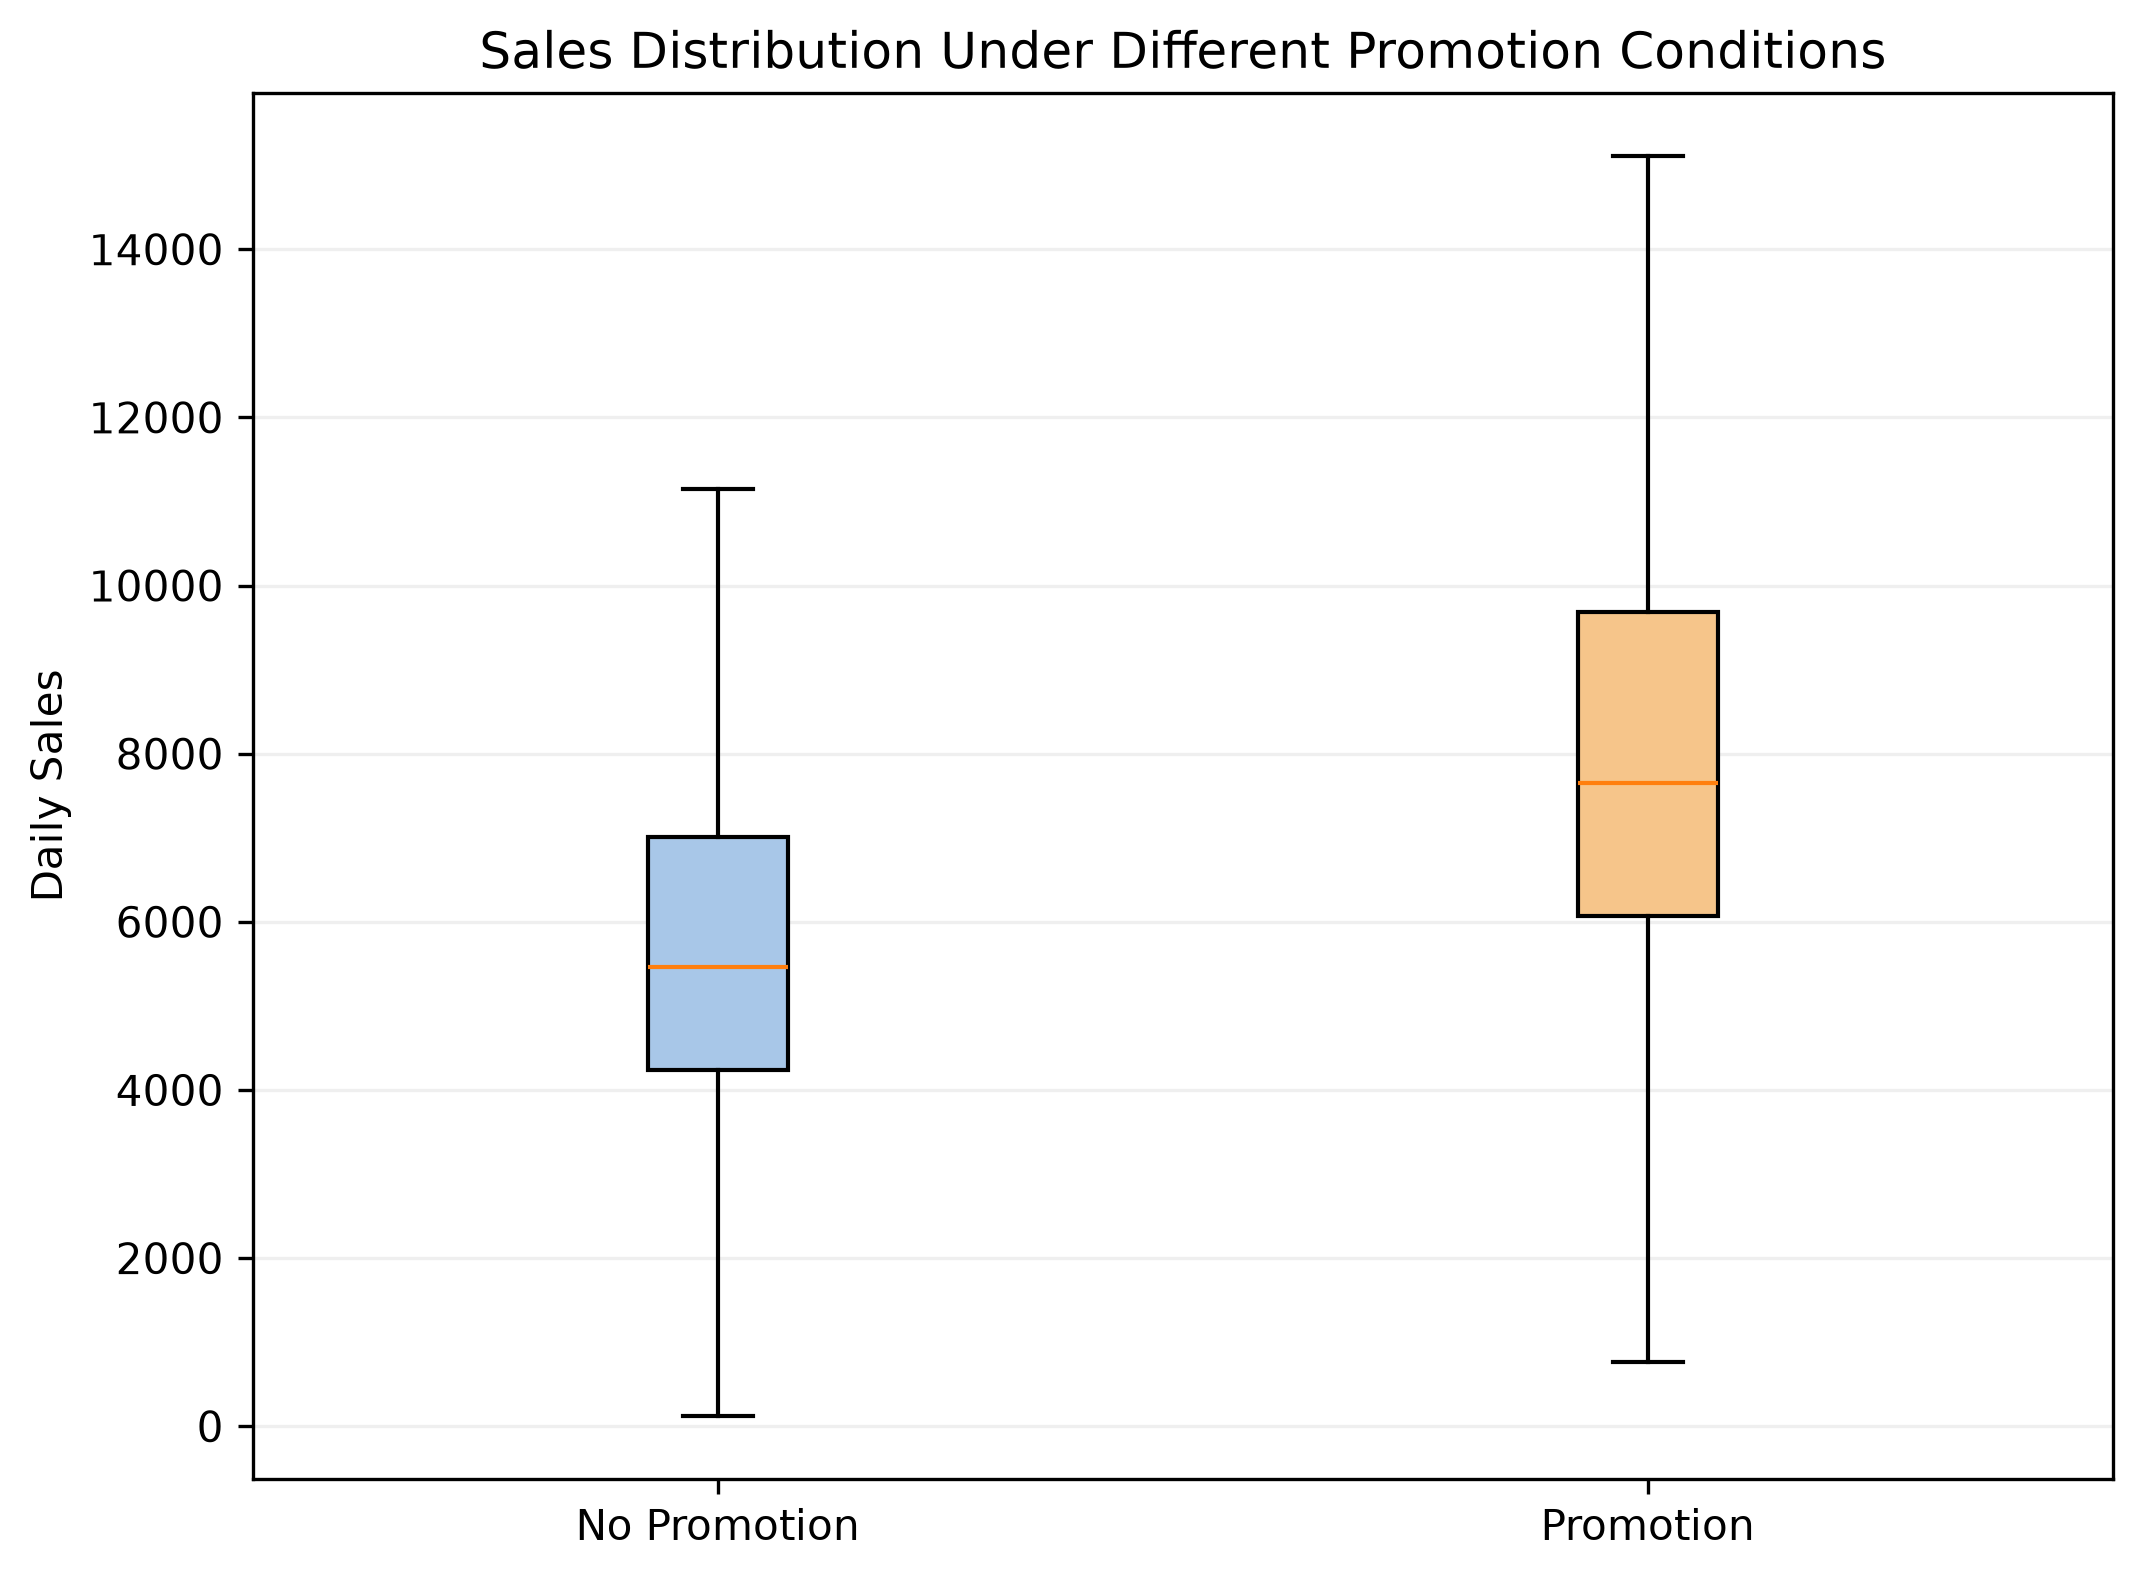

In [6]:
# ============================================================
# 7. Impact of Promotion on Sales Performance
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


# ------------------------------------------------------------
# 1. Load cleaned dataset
# ------------------------------------------------------------

train_clean = pd.read_csv(
    "../data/processed/train_clean.csv",
    dtype={
        "StateHoliday": "string"
    },
    low_memory=False
)


# ------------------------------------------------------------
# 2. Select operating-day observations
# ------------------------------------------------------------

train_open = train_clean.loc[
    train_clean["Open"] == 1
].copy()


# ------------------------------------------------------------
# 3. Summary statistics by promotion status
# ------------------------------------------------------------

promo_summary = (
    train_open
    .groupby("Promo")["Sales"]
    .agg(
        [
            "count",
            "mean",
            "median",
            "std"
        ]
    )
)


print(promo_summary)



# ------------------------------------------------------------
# 4. Figure directory
# ------------------------------------------------------------

FIGURE_DIR = Path(
    "../outputs/figures"
)

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True
)



# ------------------------------------------------------------
# 5. Prepare sales groups
# ------------------------------------------------------------

sales_no_promo = train_open.loc[
    train_open["Promo"] == 0,
    "Sales"
]


sales_promo = train_open.loc[
    train_open["Promo"] == 1,
    "Sales"
]



# ------------------------------------------------------------
# 6. Boxplot visualization
# ------------------------------------------------------------

plt.figure(
    figsize=(8,6),
    dpi=300
)


box = plt.boxplot(
    [
        sales_no_promo,
        sales_promo
    ],
    tick_labels=[
        "No Promotion",
        "Promotion"
    ],
    showfliers=False,
    patch_artist=True
)


# ------------------------------------------------------------
# 7. Apply pastel colors
# ------------------------------------------------------------

colors = [
    "#A8C7E8",   # pastel blue
    "#F6C58A"    # pastel orange
]


for patch, color in zip(
    box["boxes"],
    colors
):
    patch.set_facecolor(
        color
    )


plt.ylabel(
    "Daily Sales"
)


plt.title(
    "Sales Distribution Under Different Promotion Conditions"
)


plt.grid(
    axis="y",
    alpha=0.2
)



# ------------------------------------------------------------
# 8. Save figure
# ------------------------------------------------------------

plt.savefig(
    FIGURE_DIR / "sales_promotion_boxplot.png",
    bbox_inches="tight"
)


plt.show()

# 8. Impact of State Holidays on Sales Performance

## Purpose

Previous analyses showed that customer traffic and promotion activities are important factors associated with daily sales variation.

However, retail demand is also affected by temporal events, especially public holidays.

This section investigates whether state holidays are associated with different sales performance compared with regular working days.

Understanding holiday effects is important because holiday-related variables may provide additional predictive information for the later neural network model.

## Input

The analysis uses:

- `train_clean`

Only operating-day observations are included:

\[
Open = 1
\]

because closed stores naturally generate zero sales and cannot reflect holiday-related sales differences.

The key variable is:

- `StateHoliday`

According to the dataset definition:

- `0`: no state holiday;
- `a`, `b`, `c`: different holiday categories.

## Method

Daily sales distributions are compared among different `StateHoliday` categories.

For each category, descriptive statistics are calculated:

- Number of observations;
- Mean sales;
- Median sales;
- Standard deviation.

The mean sales value is defined as:

$$
\bar{S}
=
\frac{1}{n}
\sum_{i=1}^{n}S_i
$$

where:

- \(S_i\) represents daily sales;
- \(n\) represents the number of observations within each holiday category.

## Visualization

A boxplot is used to compare sales distributions across different state holiday categories.

The visualization follows project requirements:

- data interpretation is the primary objective;
- clean SCI-style visualization is adopted;
- pastel colours are used;
- outliers are hidden to improve distribution readability;
- the figure is saved under:


                   count         mean  median          std
StateHoliday                                              
No Holiday        843482  6953.515034  6368.0  3098.870455
Public Holiday A     694  8487.471182  7556.0  5708.626230
Public Holiday B     145  9887.889655  8423.0  7551.782095
Public Holiday C      71  9743.746479  8397.0  5980.858729


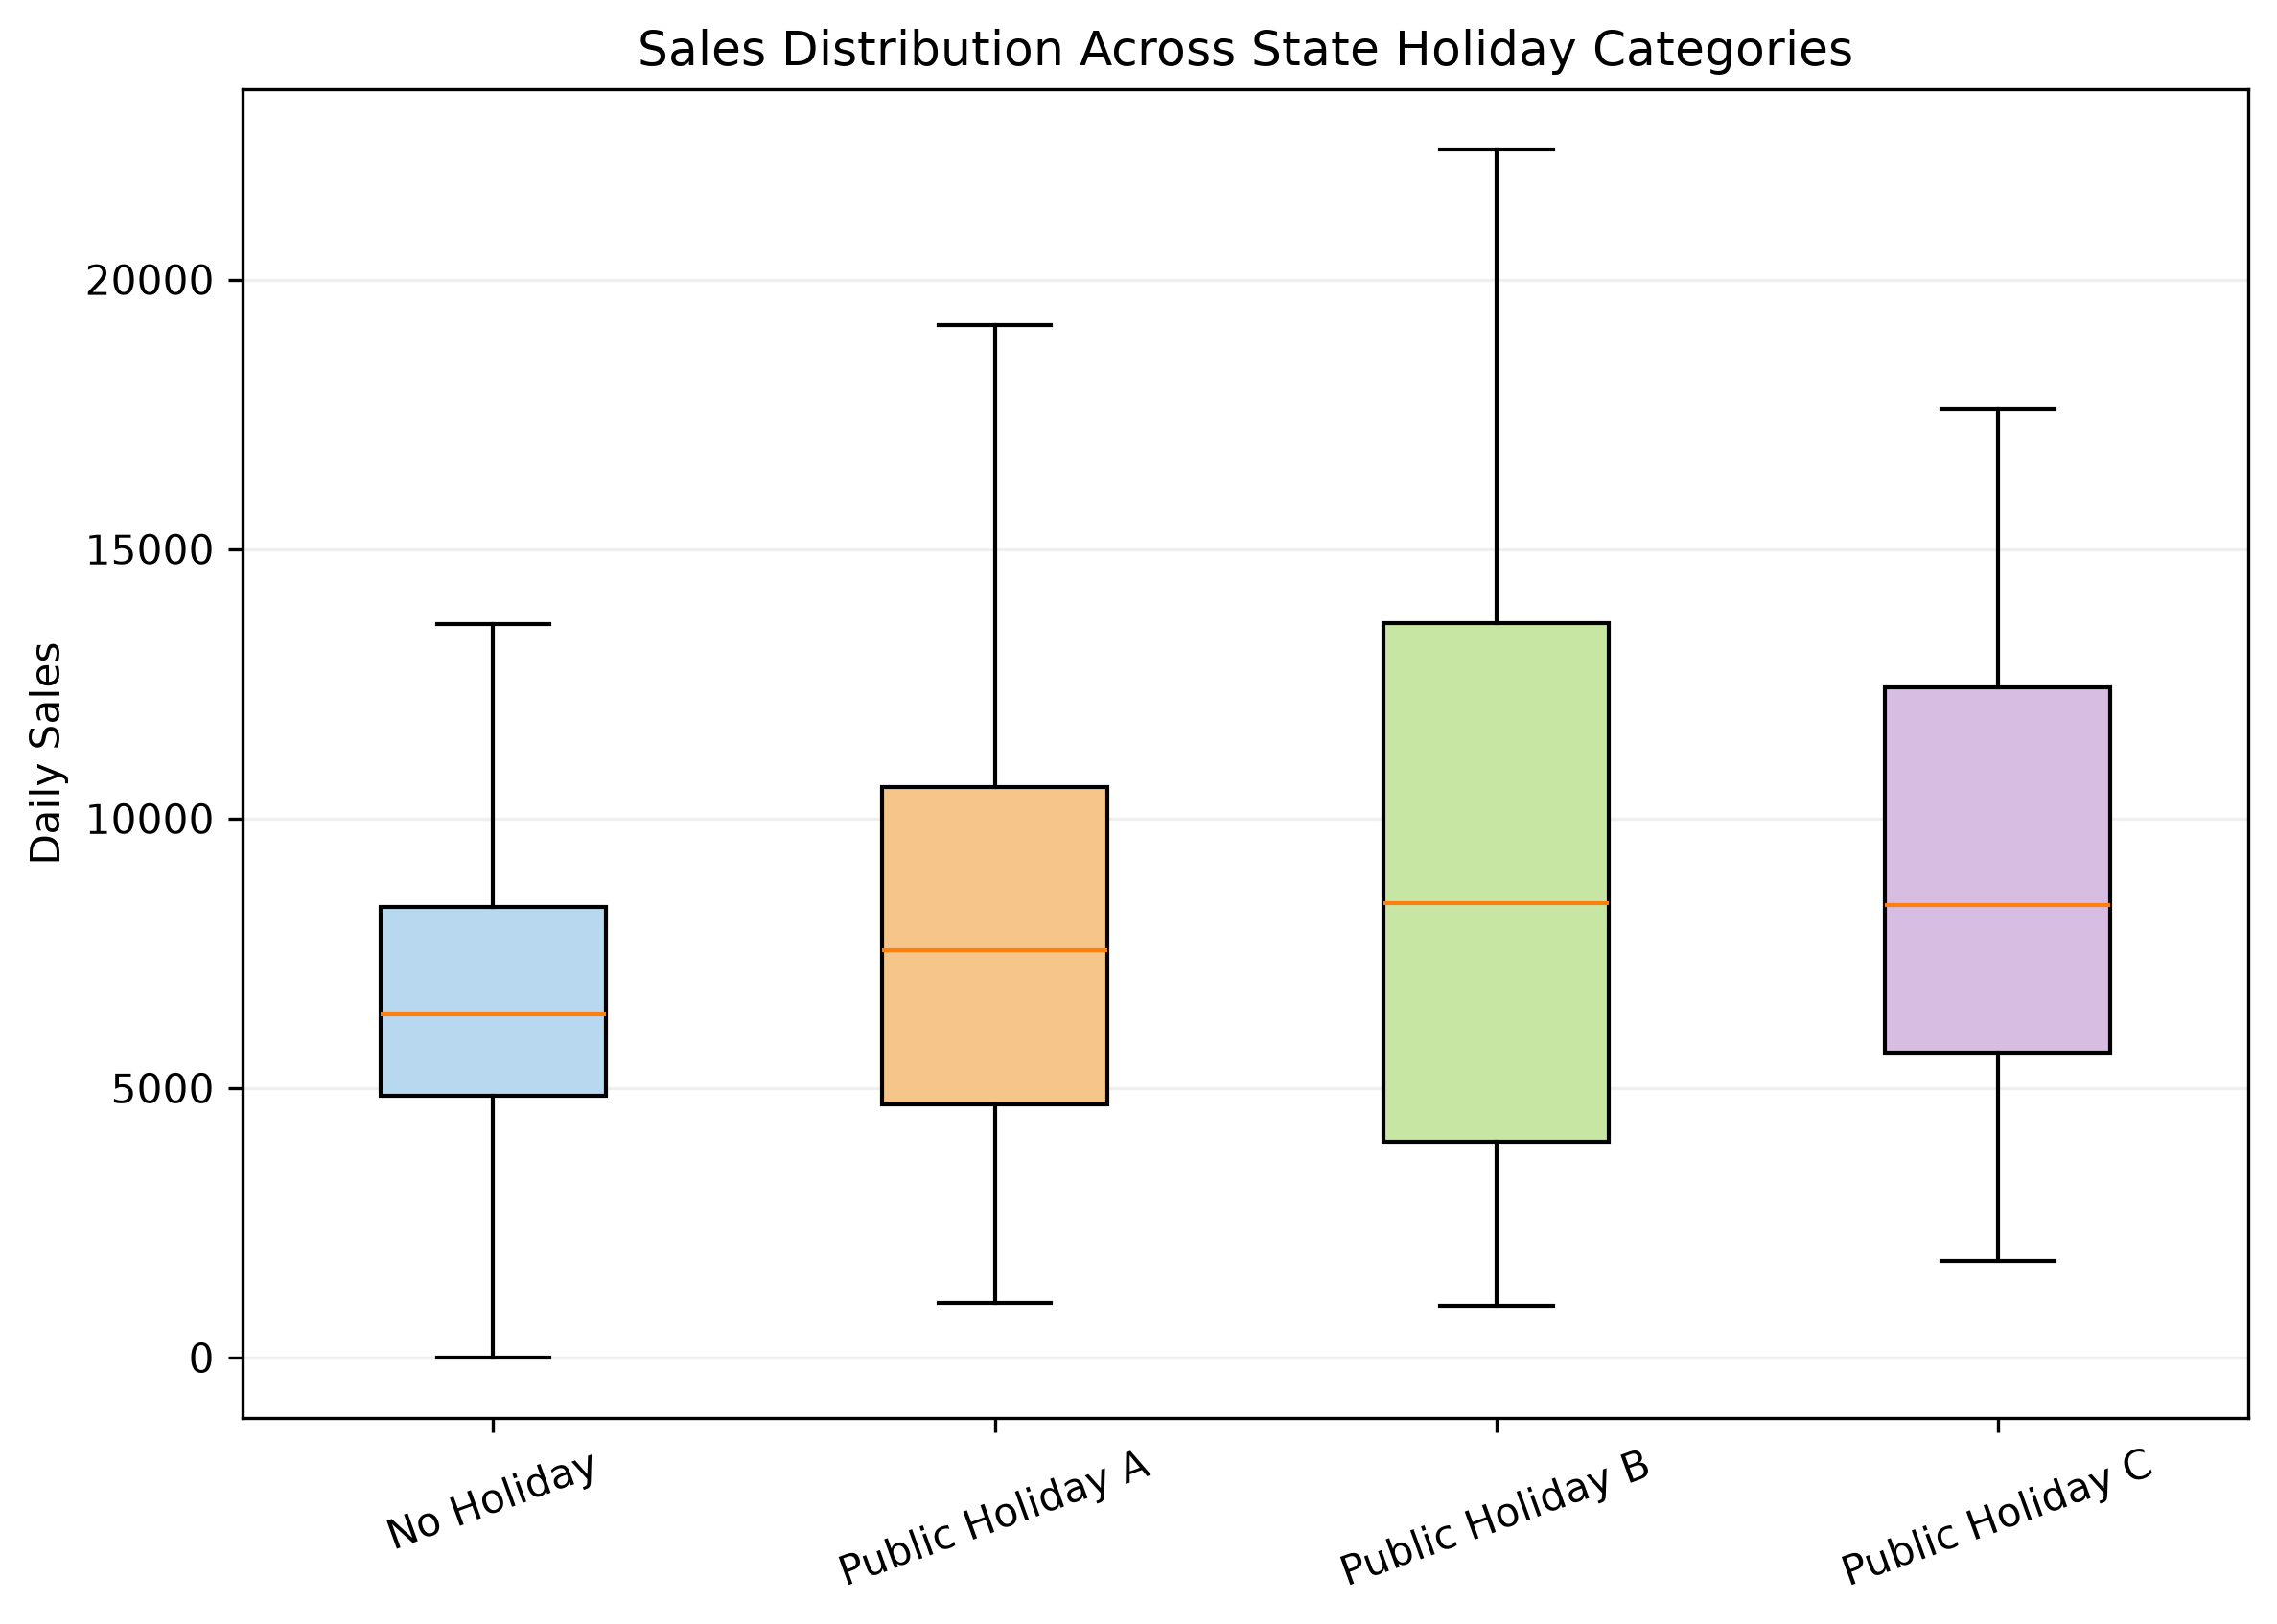

In [7]:
# ============================================================
# 8. Impact of State Holidays on Sales Performance
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


# ------------------------------------------------------------
# 1. Load cleaned dataset
# ------------------------------------------------------------

train_clean = pd.read_csv(
    "../data/processed/train_clean.csv",
    dtype={
        "StateHoliday": "string"
    },
    low_memory=False
)


# ------------------------------------------------------------
# 2. Select operating-day observations
# ------------------------------------------------------------

train_open = train_clean.loc[
    train_clean["Open"] == 1
].copy()


# ------------------------------------------------------------
# 3. Standardize StateHoliday representation
# ------------------------------------------------------------
# The check notebook identified that StateHoliday
# contains both numeric 0 and string "0".
# Here we ensure consistent category representation.
# ------------------------------------------------------------

train_open["StateHoliday"] = (
    train_open["StateHoliday"]
    .astype(str)
)


train_open["StateHoliday"] = (
    train_open["StateHoliday"]
    .replace(
        {
            "0": "No Holiday",
            "a": "Public Holiday A",
            "b": "Public Holiday B",
            "c": "Public Holiday C"
        }
    )
)



# ------------------------------------------------------------
# 4. Summary statistics
# ------------------------------------------------------------

holiday_summary = (
    train_open
    .groupby("StateHoliday")["Sales"]
    .agg(
        [
            "count",
            "mean",
            "median",
            "std"
        ]
    )
)


print(
    holiday_summary
)



# ------------------------------------------------------------
# 5. Prepare figure directory
# ------------------------------------------------------------

FIGURE_DIR = Path(
    "../outputs/figures"
)

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True
)



# ------------------------------------------------------------
# 6. Boxplot visualization
# ------------------------------------------------------------

holiday_categories = (
    holiday_summary
    .index
    .tolist()
)


holiday_sales = [
    train_open.loc[
        train_open["StateHoliday"] == category,
        "Sales"
    ]
    for category in holiday_categories
]


plt.figure(
    figsize=(9,6),
    dpi=300
)


box = plt.boxplot(
    holiday_sales,
    tick_labels=holiday_categories,
    showfliers=False,
    patch_artist=True
)



# ------------------------------------------------------------
# 7. Apply pastel colors
# ------------------------------------------------------------

colors = [
    "#B8D8F0",
    "#F6C58A",
    "#C7E6A3",
    "#D7BDE2"
]


for patch, color in zip(
    box["boxes"],
    colors
):
    patch.set_facecolor(
        color
    )


plt.ylabel(
    "Daily Sales"
)


plt.title(
    "Sales Distribution Across State Holiday Categories"
)


plt.xticks(
    rotation=20
)


plt.grid(
    axis="y",
    alpha=0.2
)



# ------------------------------------------------------------
# 8. Save figure
# ------------------------------------------------------------

plt.savefig(
    FIGURE_DIR / "sales_stateholiday_boxplot.png",
    bbox_inches="tight"
)


plt.show()

# 8. Impact of State Holidays on Sales Performance

## Purpose

Previous analyses identified that customer traffic and promotion activities are important factors associated with daily sales variation.

Retail sales are also influenced by temporal events, especially public holidays. 
This section investigates whether different state holiday categories are associated with different sales performance.

The objective is to determine whether holiday-related information provides useful predictive signals for the later neural network model.

## Input

The analysis uses:

- `train_clean`

Only operating-day observations are included:

$$
Open=1
$$

because closed stores contain structural zero sales.

The key variable is:

`StateHoliday`

Categories:

- No Holiday
- Public Holiday A
- Public Holiday B
- Public Holiday C

## Method

The average daily sales under each holiday category are calculated.

The mean sales value is defined as:

$$
\bar{S}
=
\frac{1}{n}
\sum_{i=1}^{n}S_i
$$

where:

- \(S_i\) represents daily sales;
- \(n\) represents the number of observations.

## Visualization

A bar chart is used because `StateHoliday` is a categorical variable.

The chart directly compares average sales levels across different holiday categories.

Visualization requirements:

- scientific and clean style;
- pastel colours;
- clear labels;
- figures saved to:


                   count         mean  median          std
StateHoliday                                              
No Holiday        843482  6953.515034  6368.0  3098.870455
Public Holiday A     694  8487.471182  7556.0  5708.626230
Public Holiday B     145  9887.889655  8423.0  7551.782095
Public Holiday C      71  9743.746479  8397.0  5980.858729


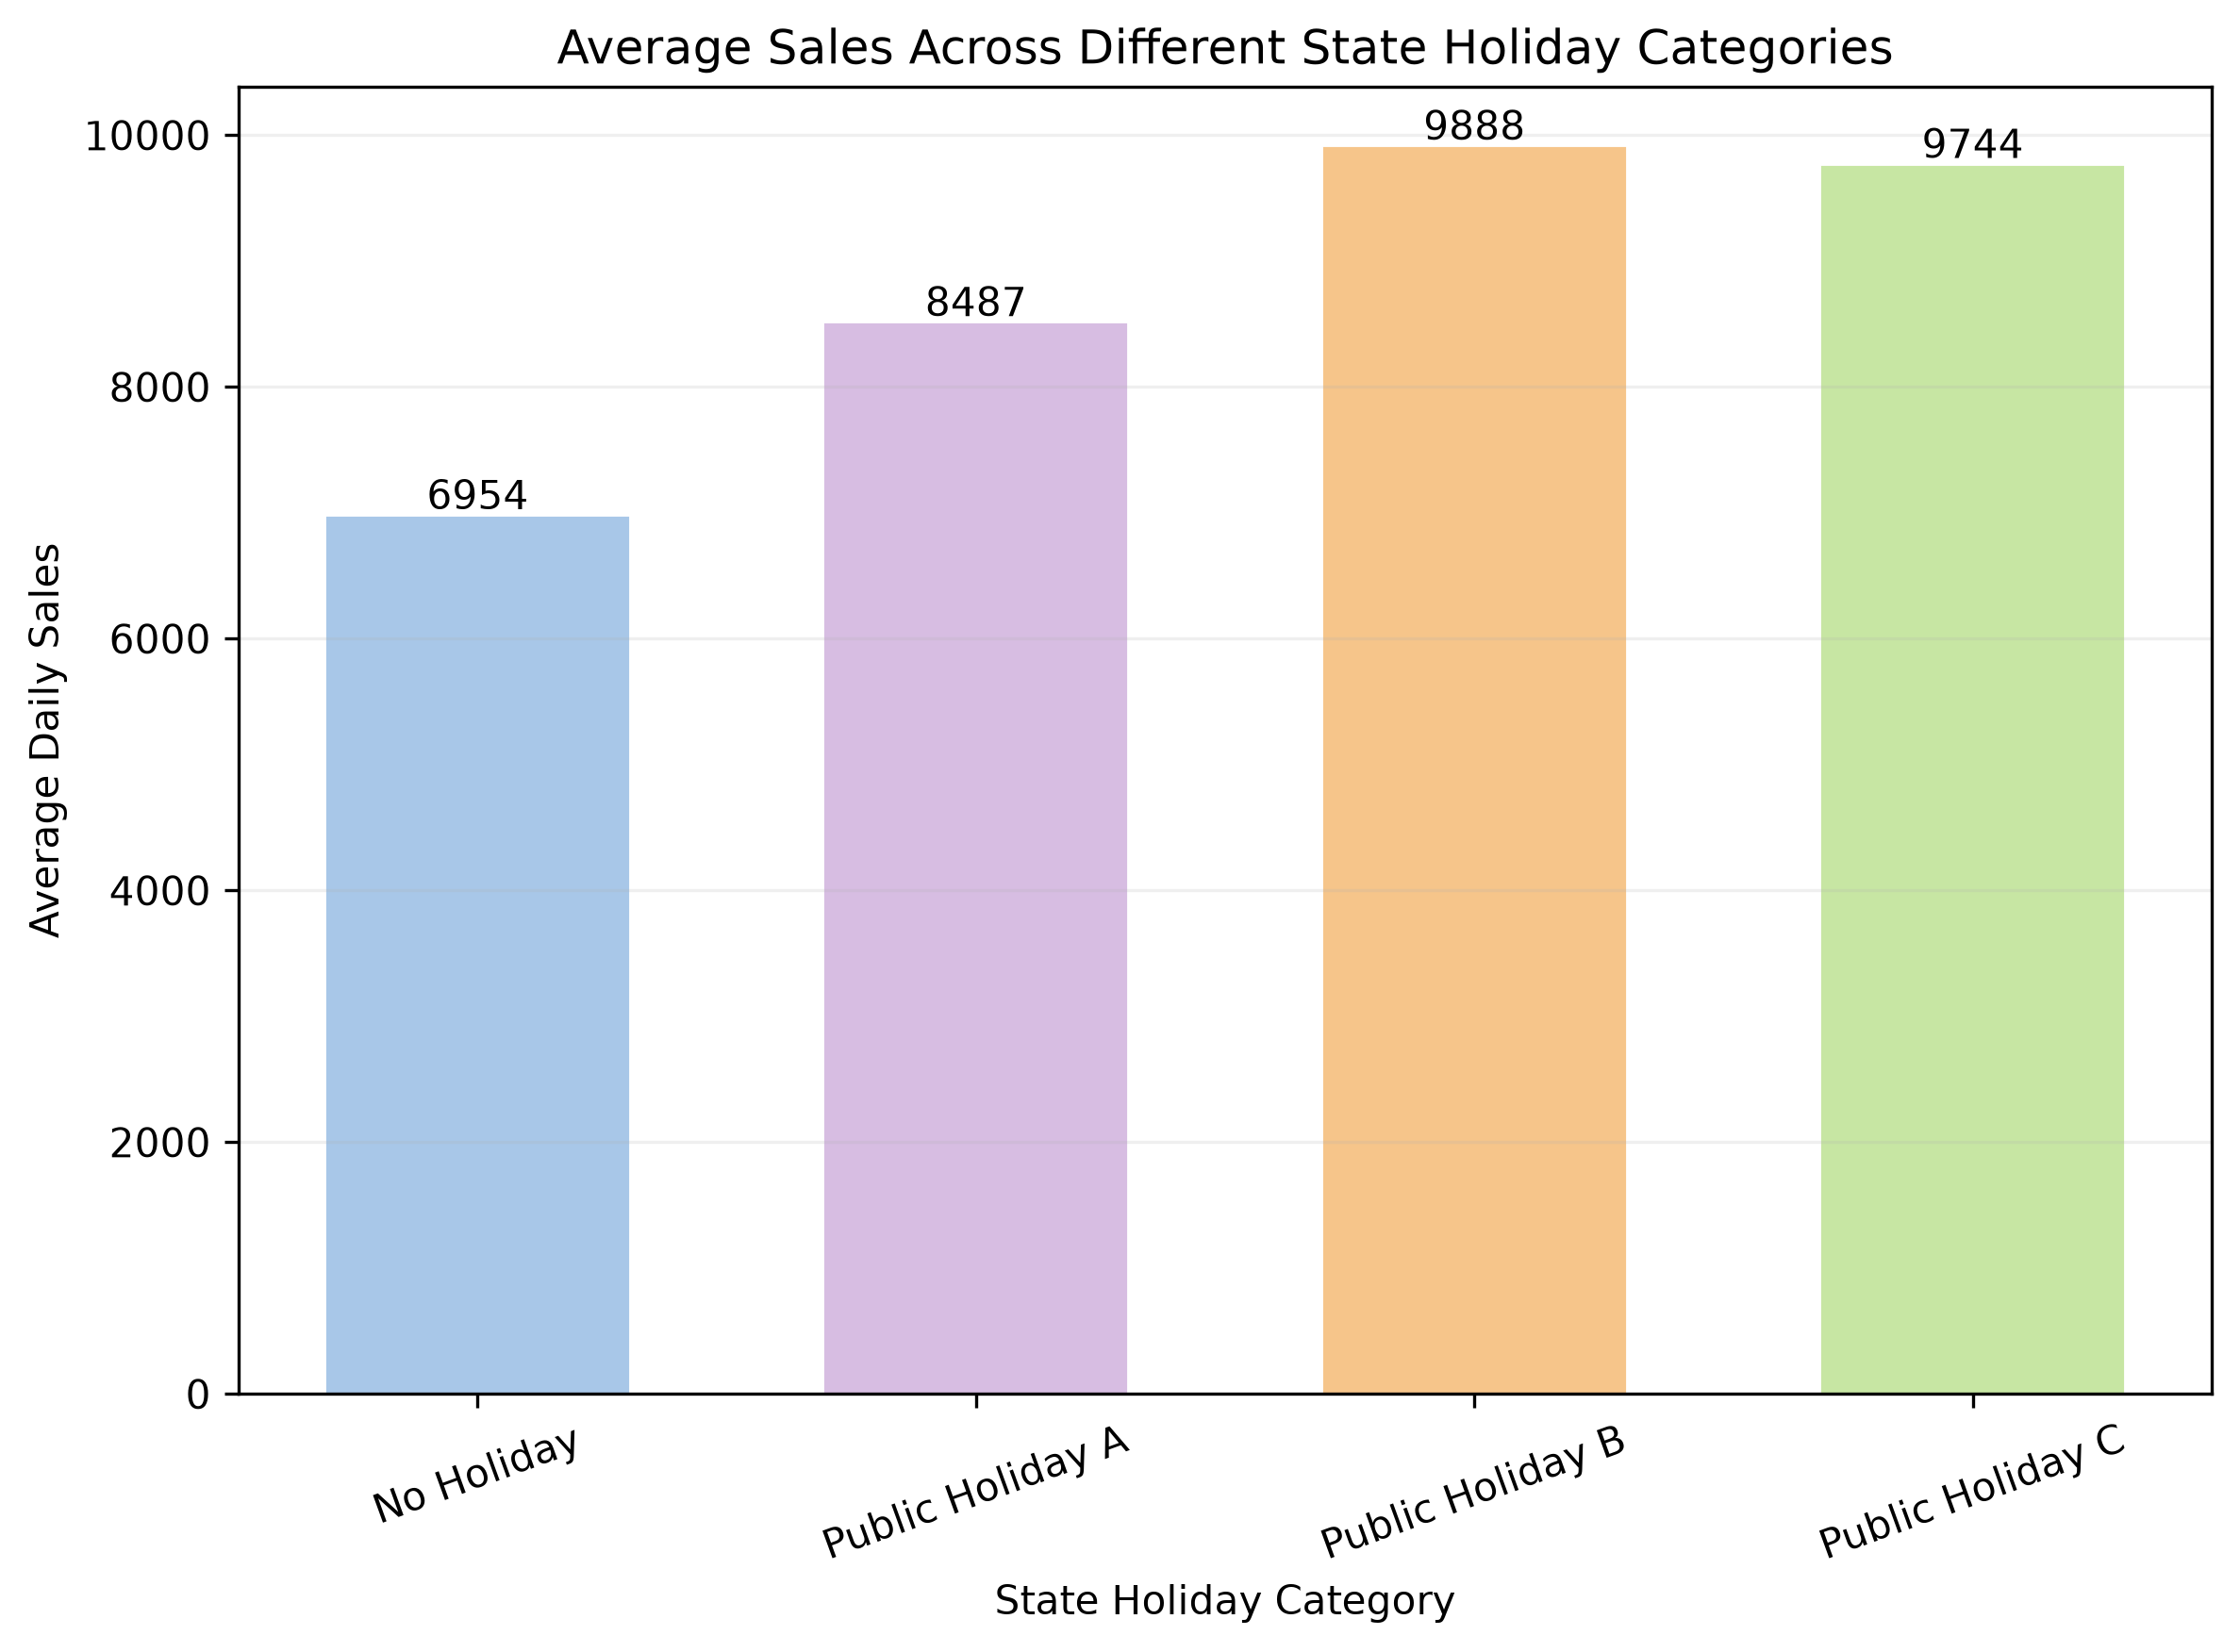

In [8]:
# ============================================================
# 8. Impact of State Holidays on Sales Performance
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


# ------------------------------------------------------------
# 1. Load cleaned dataset
# ------------------------------------------------------------

train_clean = pd.read_csv(
    "../data/processed/train_clean.csv",
    dtype={
        "StateHoliday": "string"
    },
    low_memory=False
)


# ------------------------------------------------------------
# 2. Select operating-day observations
# ------------------------------------------------------------

train_open = train_clean.loc[
    train_clean["Open"] == 1
].copy()


# ------------------------------------------------------------
# 3. Standardize StateHoliday categories
# ------------------------------------------------------------
# Previous checking showed that StateHoliday contains
# mixed representations:
# numeric 0 and string "0".
#
# The values are standardized before analysis.
# ------------------------------------------------------------

train_open["StateHoliday"] = (
    train_open["StateHoliday"]
    .astype(str)
)


train_open["StateHoliday"] = (
    train_open["StateHoliday"]
    .replace(
        {
            "0": "No Holiday",
            "a": "Public Holiday A",
            "b": "Public Holiday B",
            "c": "Public Holiday C"
        }
    )
)



# ------------------------------------------------------------
# 4. Calculate summary statistics
# ------------------------------------------------------------

holiday_summary = (
    train_open
    .groupby("StateHoliday")["Sales"]
    .agg(
        [
            "count",
            "mean",
            "median",
            "std"
        ]
    )
)


# Keep category order
holiday_order = [
    "No Holiday",
    "Public Holiday A",
    "Public Holiday B",
    "Public Holiday C"
]


holiday_summary = (
    holiday_summary
    .reindex(
        holiday_order
    )
)


print(
    holiday_summary
)



# ------------------------------------------------------------
# 5. Prepare figure directory
# ------------------------------------------------------------

FIGURE_DIR = Path(
    "../outputs/figures"
)

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True
)



# ------------------------------------------------------------
# 6. Bar chart of average sales
# ------------------------------------------------------------

plt.figure(
    figsize=(9,6),
    dpi=300
)


bars = plt.bar(
    holiday_summary.index,
    holiday_summary["mean"],
    width=0.6
)



# ------------------------------------------------------------
# 7. Apply pastel colours
# ------------------------------------------------------------

colors = [
    "#A8C7E8",   # pastel blue
    "#D7BDE2",   # pastel purple
    "#F6C58A",   # pastel orange
    "#C7E6A3"    # pastel green
]


for bar, color in zip(
    bars,
    colors
):
    bar.set_color(
        color
    )



# ------------------------------------------------------------
# 8. Add value labels
# ------------------------------------------------------------

for bar, value in zip(
    bars,
    holiday_summary["mean"]
):

    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{value:.0f}",
        ha="center",
        va="bottom",
        fontsize=10
    )



plt.ylabel(
    "Average Daily Sales"
)


plt.xlabel(
    "State Holiday Category"
)


plt.title(
    "Average Sales Across Different State Holiday Categories"
)


plt.xticks(
    rotation=20
)


plt.grid(
    axis="y",
    alpha=0.2
)



# ------------------------------------------------------------
# 9. Save figure
# ------------------------------------------------------------

plt.savefig(
    FIGURE_DIR / "average_sales_stateholiday.png",
    bbox_inches="tight"
)


plt.show()

# 8.2 Impact of School Holidays on Sales Performance

## Purpose

In addition to public holidays, school holidays may influence retail demand by changing customer shopping behaviour and family activities.

This section investigates whether sales performance differs between school holiday and non-school holiday periods.

The analysis provides further evidence about whether holiday-related variables should be included as predictive features in the neural network model.

## Input

The analysis uses:

- `train_clean`

Only operating-day observations are considered:

$$
Open=1
$$

because closed stores generate structural zero sales.

The key variable is:

`SchoolHoliday`

where:

- 0: No school holiday;
- 1: School holiday.

## Method

Sales distributions are compared between school holiday and non-school holiday periods.

The following statistics are calculated:

- Number of observations;
- Mean sales;
- Median sales;
- Standard deviation.

The mean sales is calculated as:

$$
\bar{S}
=
\frac{1}{n}
\sum_{i=1}^{n}S_i
$$

where:

- \(S_i\) represents daily sales;
- \(n\) represents the number of observations.

## Visualization

A boxplot is used because the objective is to compare the distributional characteristics of sales under two conditions.

Mean values are additionally marked to provide a direct comparison of average sales levels.

The figure follows the project visualization requirements:

- clear data interpretation;
- clean SCI-style appearance;
- pastel colours;
- saved to:


                count         mean  median          std
SchoolHoliday                                          
0              680935  6896.782411  6326.0  3083.774828
1              163457  7200.181650  6562.0  3176.299634


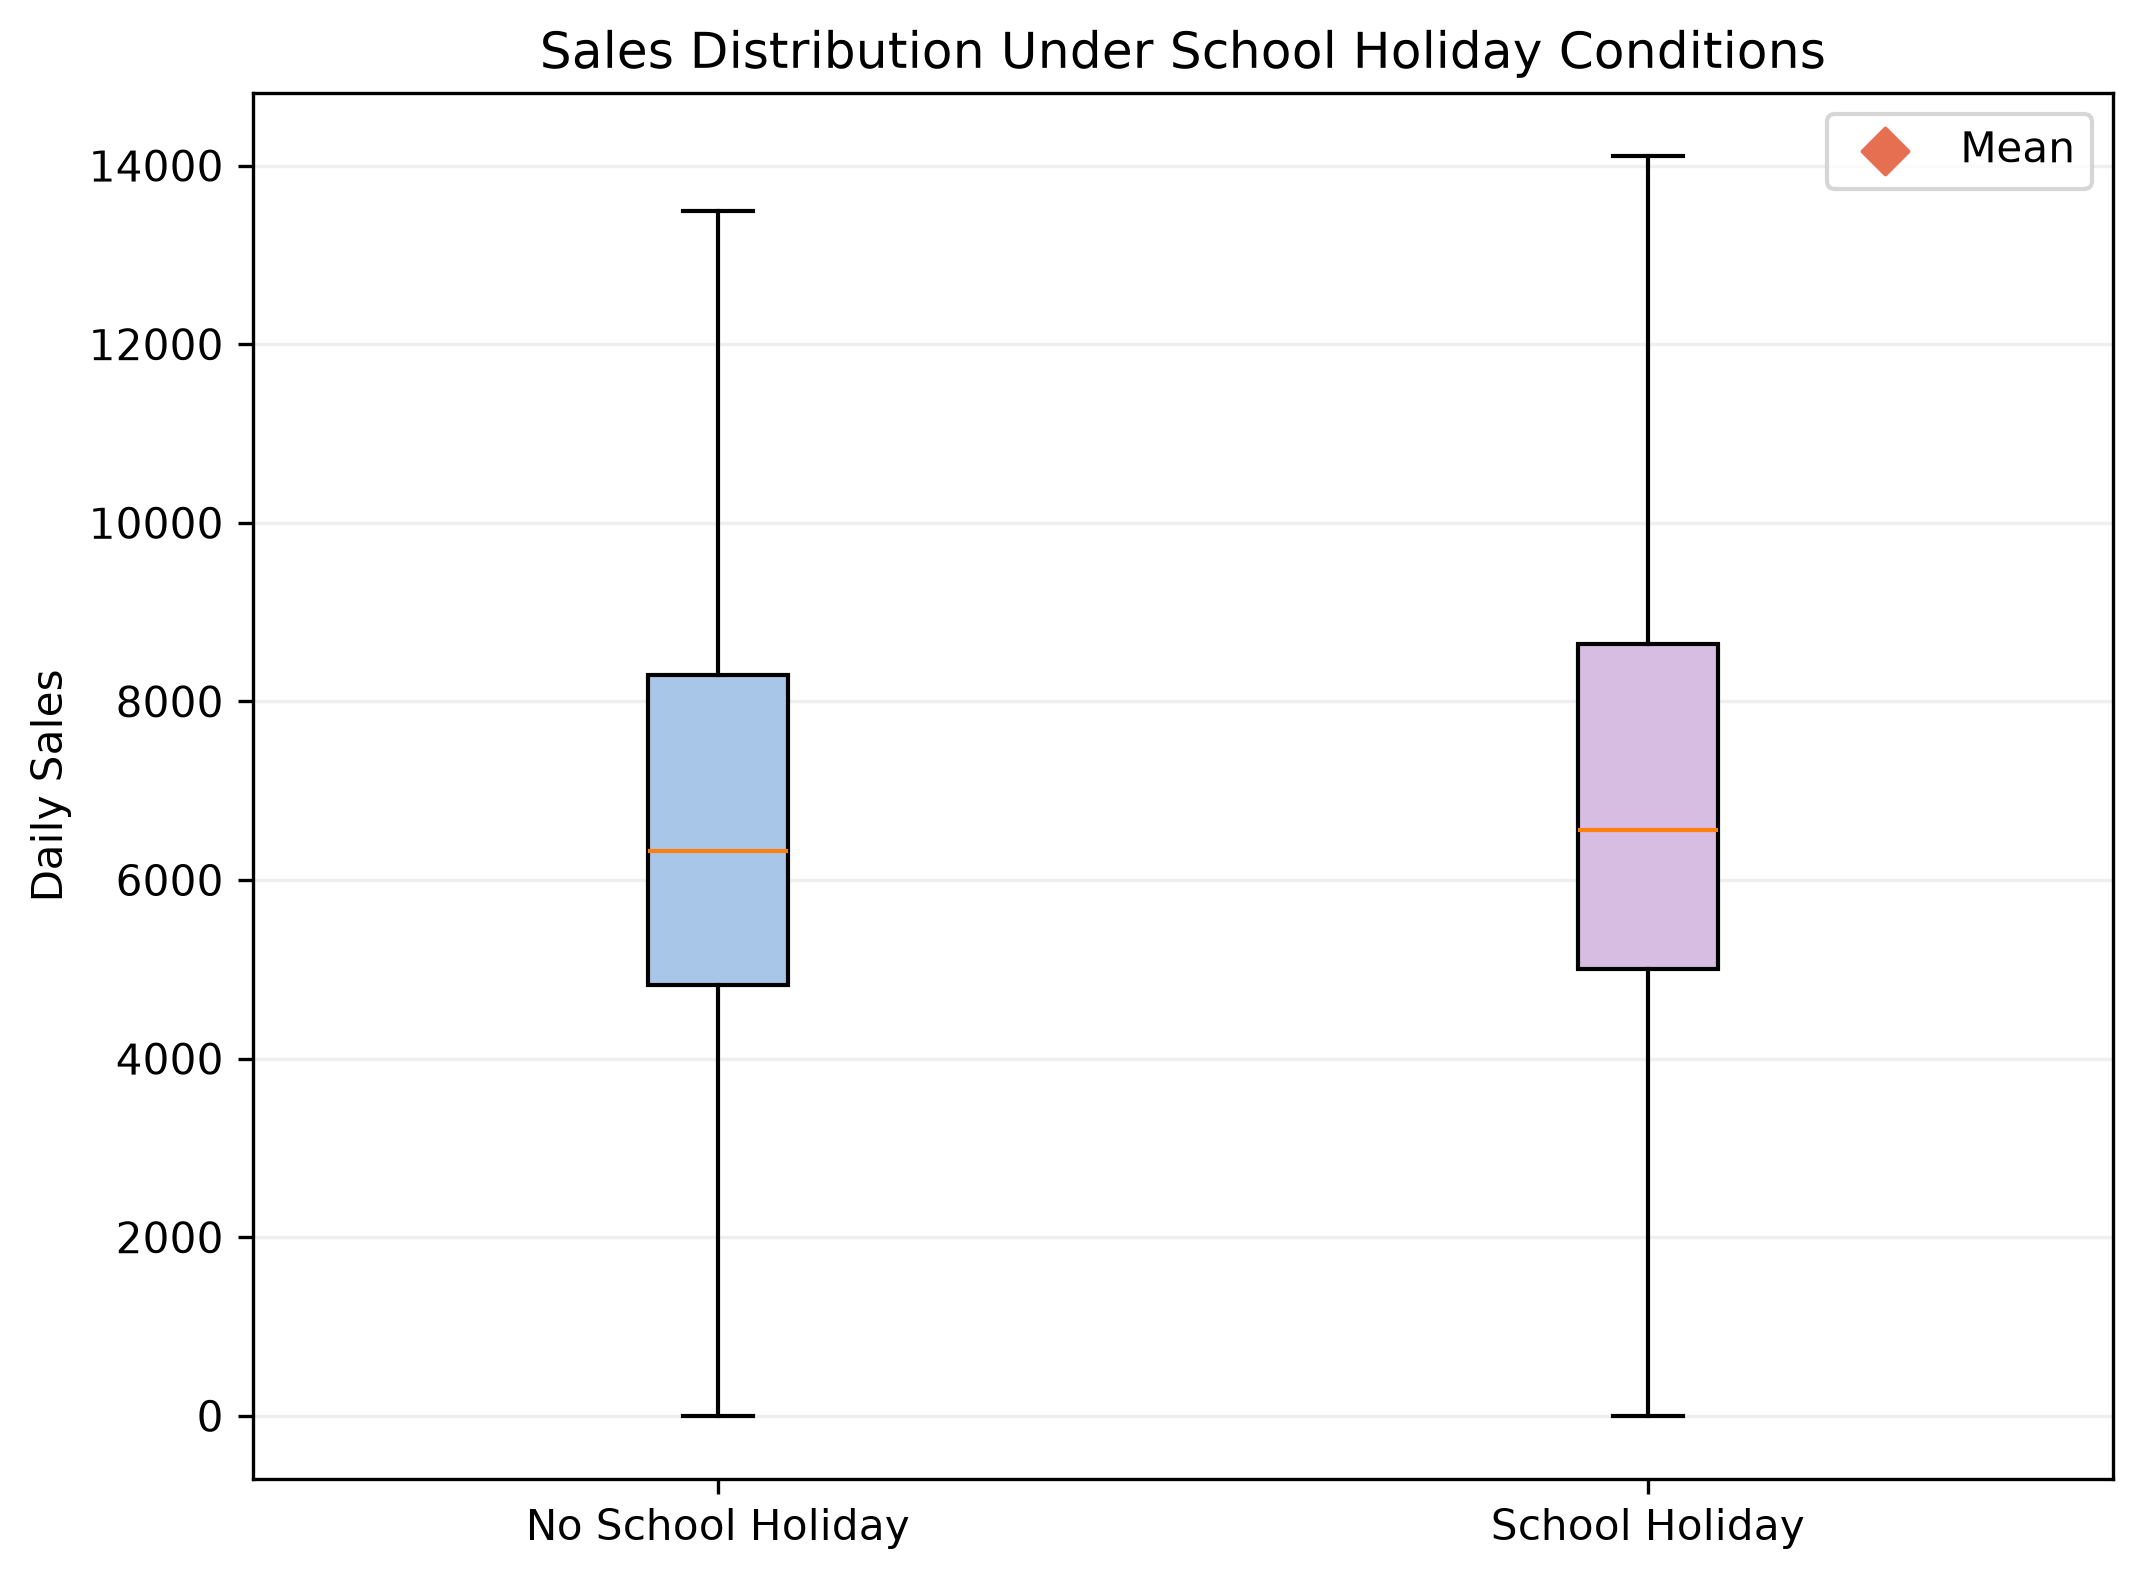

In [9]:
# ============================================================
# 8.2 Impact of School Holidays on Sales Performance
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


# ------------------------------------------------------------
# 1. Load cleaned dataset
# ------------------------------------------------------------

train_clean = pd.read_csv(
    "../data/processed/train_clean.csv",
    dtype={
        "StateHoliday": "string"
    },
    low_memory=False
)



# ------------------------------------------------------------
# 2. Select operating-day observations
# ------------------------------------------------------------

train_open = train_clean.loc[
    train_clean["Open"] == 1
].copy()



# ------------------------------------------------------------
# 3. Summary statistics
# ------------------------------------------------------------

school_summary = (
    train_open
    .groupby("SchoolHoliday")["Sales"]
    .agg(
        [
            "count",
            "mean",
            "median",
            "std"
        ]
    )
)


print(
    school_summary
)



# ------------------------------------------------------------
# 4. Prepare figure directory
# ------------------------------------------------------------

FIGURE_DIR = Path(
    "../outputs/figures"
)

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True
)



# ------------------------------------------------------------
# 5. Prepare groups
# ------------------------------------------------------------

no_school = train_open.loc[
    train_open["SchoolHoliday"] == 0,
    "Sales"
]


school = train_open.loc[
    train_open["SchoolHoliday"] == 1,
    "Sales"
]



# ------------------------------------------------------------
# 6. Boxplot visualization
# ------------------------------------------------------------

plt.figure(
    figsize=(8,6),
    dpi=300
)


box = plt.boxplot(
    [
        no_school,
        school
    ],
    tick_labels=[
        "No School Holiday",
        "School Holiday"
    ],
    showfliers=False,
    patch_artist=True
)



# ------------------------------------------------------------
# 7. Pastel colors
# ------------------------------------------------------------

colors = [
    "#A8C7E8",
    "#D7BDE2"
]


for patch, color in zip(
    box["boxes"],
    colors
):
    patch.set_facecolor(
        color
    )



# ------------------------------------------------------------
# 8. Add mean markers
# ------------------------------------------------------------

means = [
    no_school.mean(),
    school.mean()
]


plt.scatter(
    [1, 2],
    means,
    marker="D",
    s=60,
    color="#E76F51",
    label="Mean"
)



plt.ylabel(
    "Daily Sales"
)


plt.title(
    "Sales Distribution Under School Holiday Conditions"
)


plt.legend()


plt.grid(
    axis="y",
    alpha=0.2
)



# ------------------------------------------------------------
# 9. Save figure
# ------------------------------------------------------------

plt.savefig(
    FIGURE_DIR / "sales_schoolholiday_boxplot.png",
    bbox_inches="tight"
)


plt.show()

# 9. Store Characteristics Analysis

## 9.1 Impact of Store Type on Sales Performance

## Purpose

Previous analyses focused mainly on daily operational factors, including customer traffic, promotion activities, and holidays.

However, stores have different structural characteristics that may influence long-term sales performance.

This section investigates whether different store types exhibit different sales levels.

Understanding store characteristics is important because store-level attributes represent relatively stable features and can provide additional information for the later neural network prediction model.

## Input

The analysis combines:

- `train_clean`
- `store_clean`

The datasets are merged through:

The key variable analysed is:

`StoreType`

which represents different store categories.

Only operating-day observations are considered:

$$
Open=1
$$

because closed stores contain structural zero sales.

## Method

Average daily sales are calculated for each store type.

The mean sales is defined as:

$$
\bar{S}
=
\frac{1}{n}
\sum_{i=1}^{n}S_i
$$

where:

- \(S_i\) represents daily sales;
- \(n\) represents observations within each store type.

The number of stores in each category is also calculated to provide context.

## Visualization

A bar chart is used because `StoreType` is a categorical variable.

The chart compares:

- average daily sales;
- number of stores.

Visualization requirements:

- scientific and clean style;
- pastel colours;
- clear labels;
- figures saved under:


           Average_Sales  Median_Sales  Number_of_Stores  Observations
StoreType                                                             
b           10231.407505        9130.0                17         15563
c            6932.512755        6407.0               148        112978
a            6925.167661        6285.0               602        457077
d            6822.141881        6395.0               348        258774


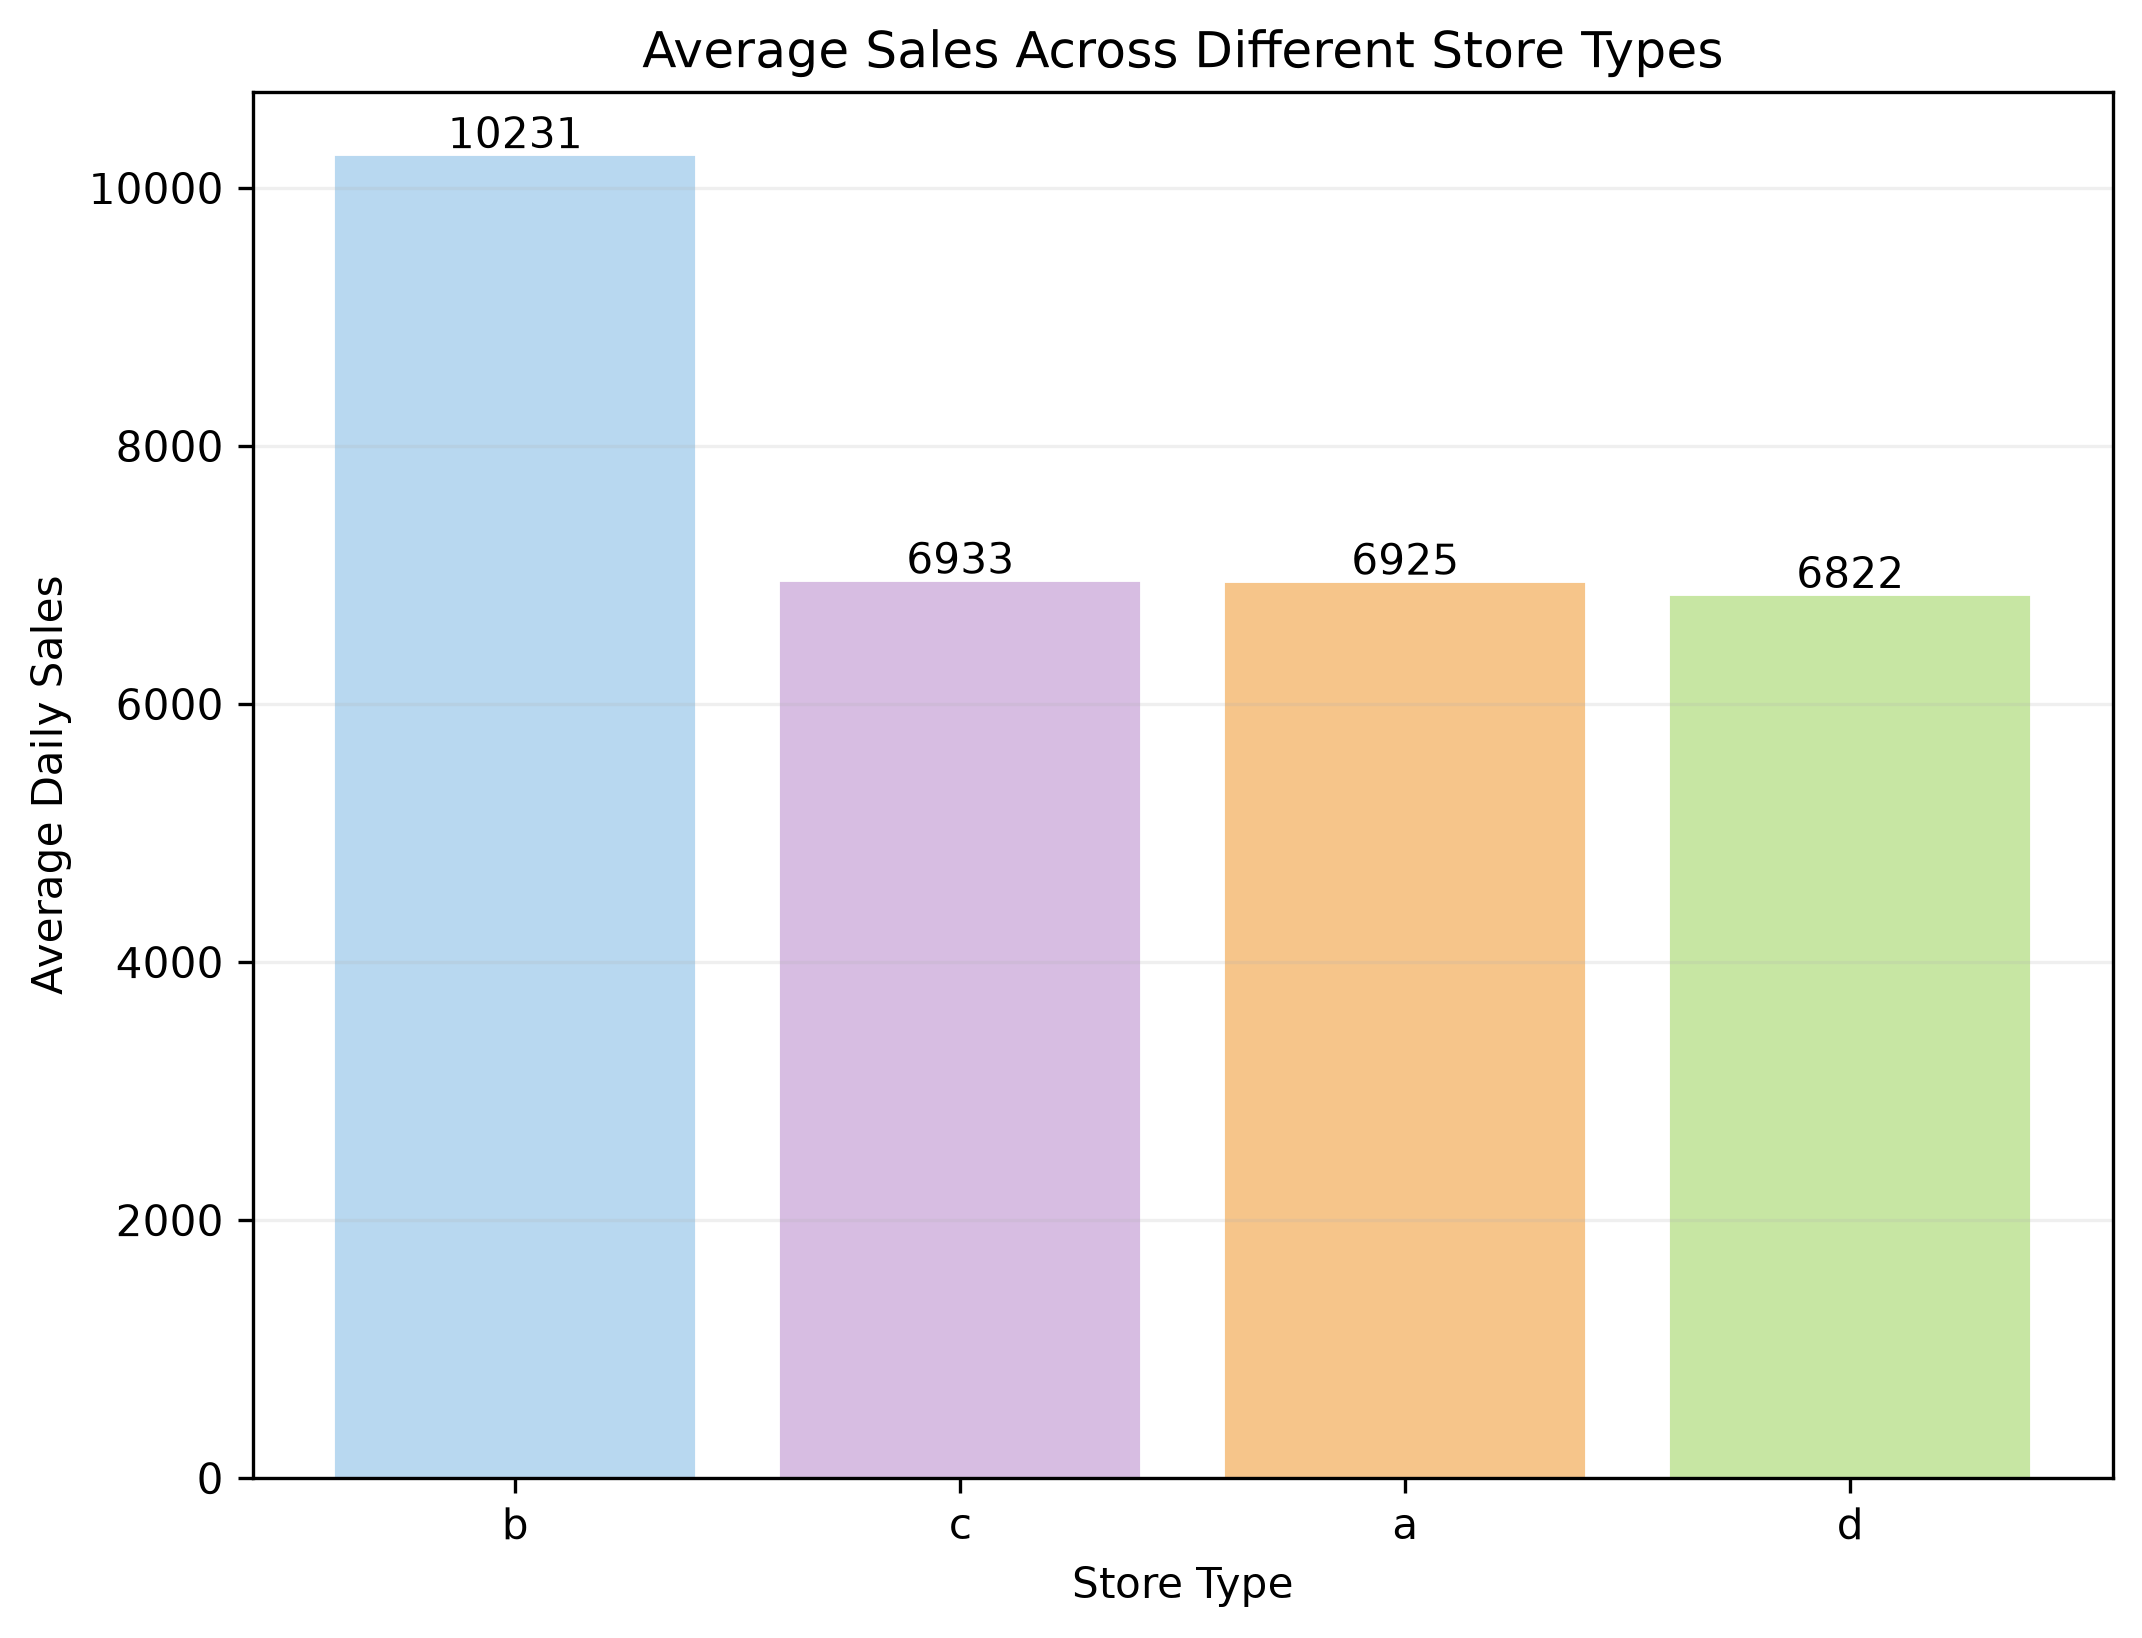

In [10]:
# ============================================================
# 9.1 Impact of Store Type on Sales Performance
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


# ------------------------------------------------------------
# 1. Load cleaned datasets
# ------------------------------------------------------------

train_clean = pd.read_csv(
    "../data/processed/train_clean.csv",
    dtype={
        "StateHoliday": "string"
    },
    low_memory=False
)


store_clean = pd.read_csv(
    "../data/processed/store_clean.csv",
    low_memory=False
)



# ------------------------------------------------------------
# 2. Merge store information
# ------------------------------------------------------------

df_store = train_clean.merge(
    store_clean,
    on="Store",
    how="left"
)



# ------------------------------------------------------------
# 3. Select operating-day observations
# ------------------------------------------------------------

df_open = df_store.loc[
    df_store["Open"] == 1
].copy()



# ------------------------------------------------------------
# 4. Summary statistics by StoreType
# ------------------------------------------------------------

storetype_summary = (
    df_open
    .groupby("StoreType")
    .agg(
        Average_Sales=("Sales", "mean"),
        Median_Sales=("Sales", "median"),
        Number_of_Stores=("Store", "nunique"),
        Observations=("Sales", "count")
    )
    .sort_values(
        "Average_Sales",
        ascending=False
    )
)


print(
    storetype_summary
)



# ------------------------------------------------------------
# 5. Prepare figure directory
# ------------------------------------------------------------

FIGURE_DIR = Path(
    "../outputs/figures"
)

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True
)



# ------------------------------------------------------------
# 6. Average sales bar chart
# ------------------------------------------------------------

plt.figure(
    figsize=(8,6),
    dpi=300
)


bars = plt.bar(
    storetype_summary.index,
    storetype_summary["Average_Sales"]
)



# ------------------------------------------------------------
# 7. Pastel colors
# ------------------------------------------------------------

colors = [
    "#B8D8F0",
    "#D7BDE2",
    "#F6C58A",
    "#C7E6A3"
]


for bar, color in zip(
    bars,
    colors
):
    bar.set_color(
        color
    )



# ------------------------------------------------------------
# 8. Add value labels
# ------------------------------------------------------------

for bar, value in zip(
    bars,
    storetype_summary["Average_Sales"]
):

    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f"{value:.0f}",
        ha="center",
        va="bottom",
        fontsize=10
    )



plt.xlabel(
    "Store Type"
)

plt.ylabel(
    "Average Daily Sales"
)

plt.title(
    "Average Sales Across Different Store Types"
)


plt.grid(
    axis="y",
    alpha=0.2
)



# ------------------------------------------------------------
# 9. Save figure
# ------------------------------------------------------------

plt.savefig(
    FIGURE_DIR / "average_sales_storetype.png",
    bbox_inches="tight"
)


plt.show()

# 9.2 Impact of Assortment Type on Sales Performance

## Purpose

Store characteristics provide relatively stable information about retail operations.

After analysing store types, this section further investigates whether different product assortment strategies are associated with different sales performance.

The assortment category reflects the type and range of products provided by each store. Different assortment strategies may attract different customer groups and generate different sales patterns.

This analysis helps determine whether assortment information should be considered as an input feature for the later neural network model.

## Input

The analysis combines:

- `train_clean`
- `store_clean`

The datasets are merged through:


Only operating-day observations are considered:

$$
Open=1
$$

because closed stores contain structural zero sales.

The key variable is:

`Assortment`

## Method

Two aspects are analysed:

1. Distribution of stores among different assortment categories;
2. Average daily sales performance of each assortment category.

The mean sales value is calculated as:

$$
\bar{S}
=
\frac{1}{n}
\sum_{i=1}^{n}S_i
$$

where:

- \(S_i\) represents daily sales;
- \(n\) represents observations within each assortment category.

## Visualization

Two bar charts are used:

1. Store distribution across assortment categories;
2. Average daily sales across assortment categories.

This design separates:

- dataset structure;
- business performance comparison.

The figures follow project visualization requirements:

- clean SCI-style appearance;
- pastel colours;
- clear labels;
- saved under:


            Average_Sales  Median_Sales  Number_of_Stores  Observations
Assortment                                                             
a             6621.017039        6082.0               593        444909
b             8639.346322        8081.0                 9          8212
c             7300.526339        6675.0               513        391271


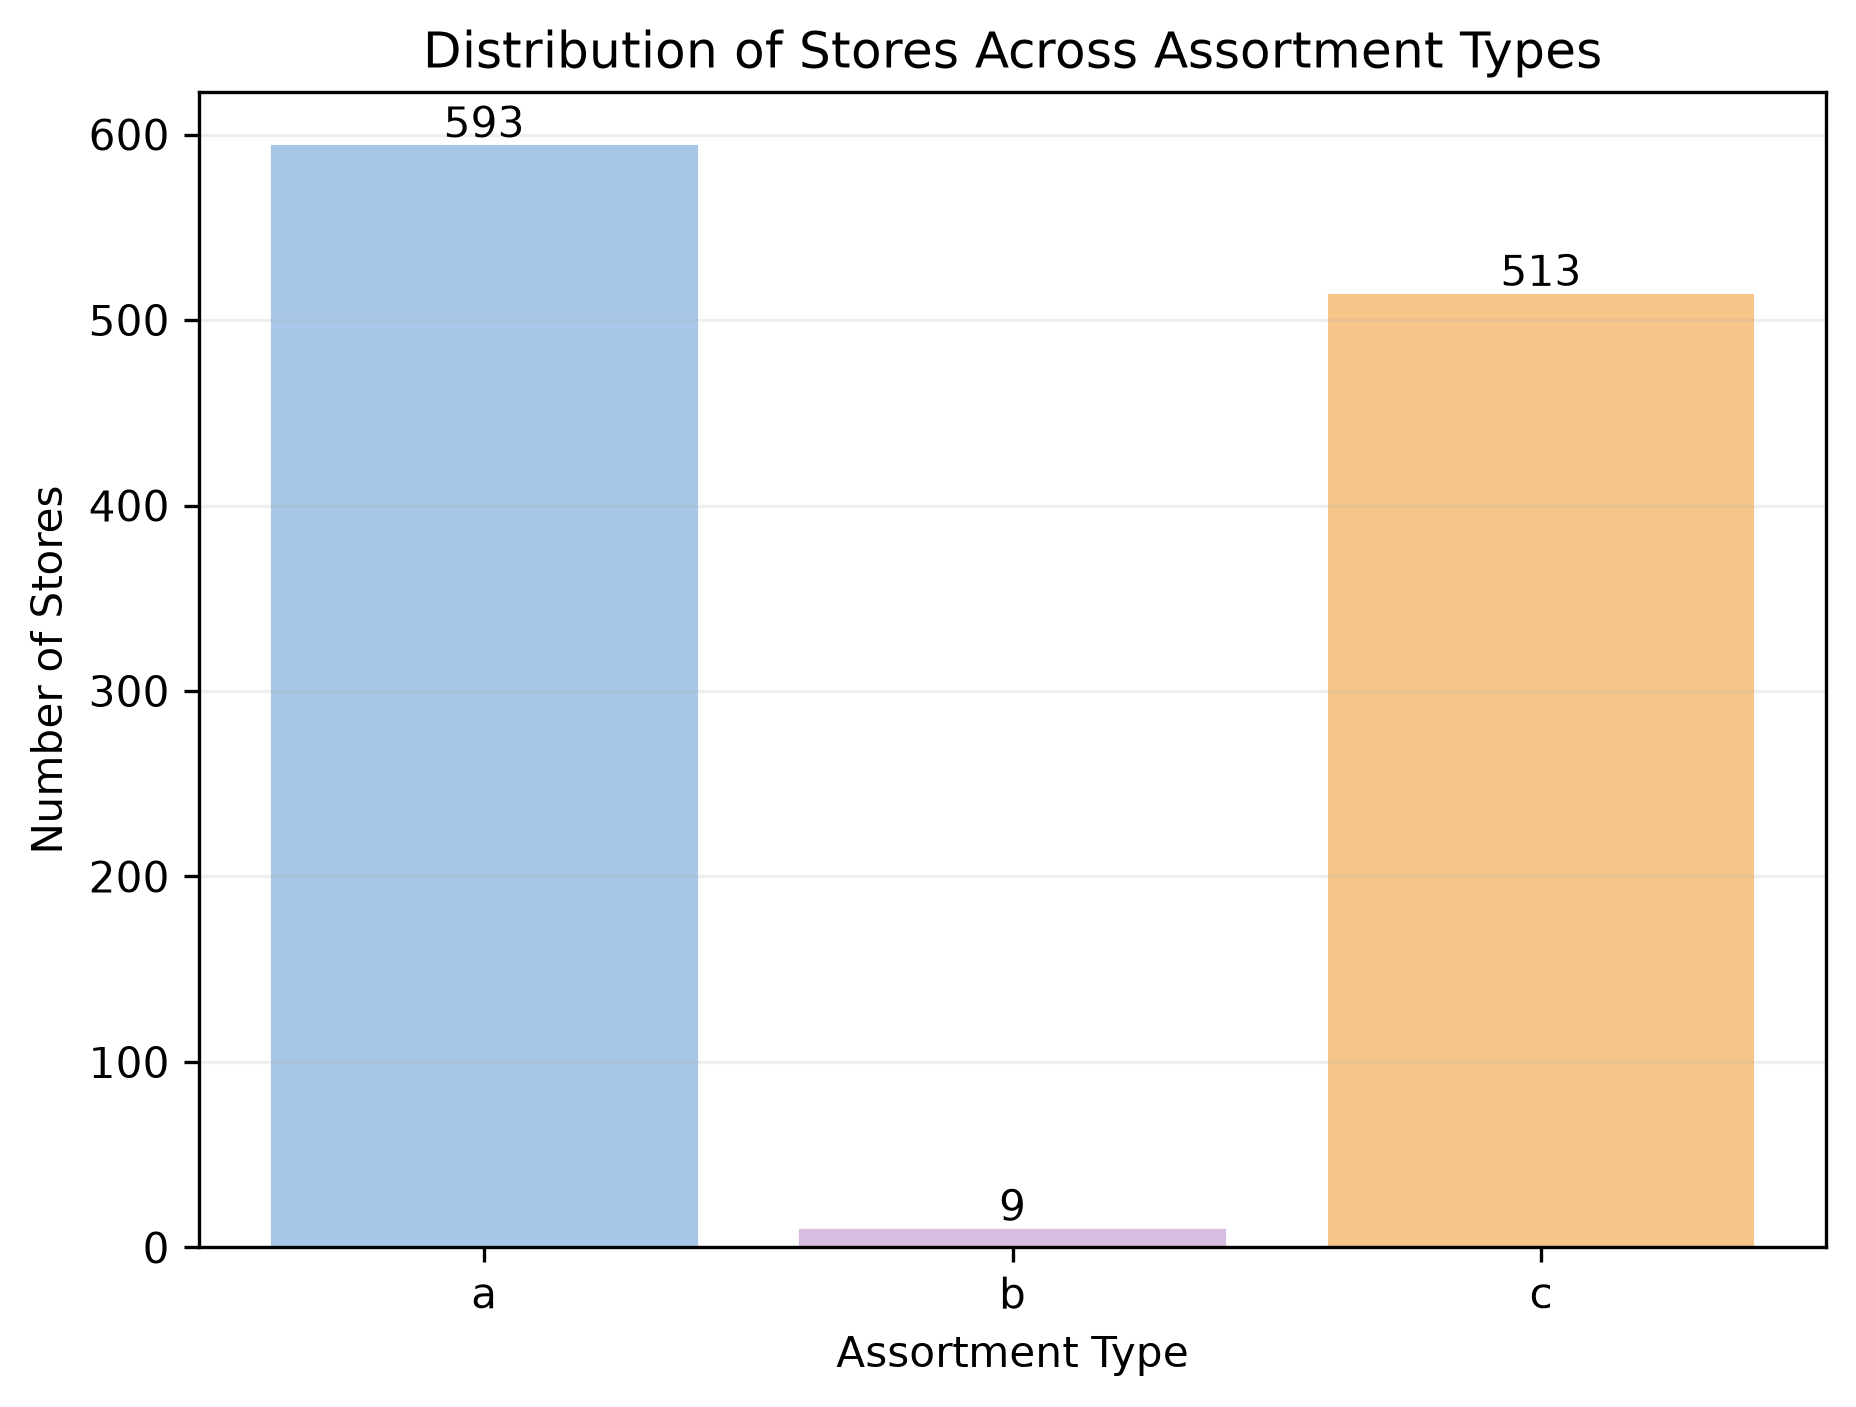

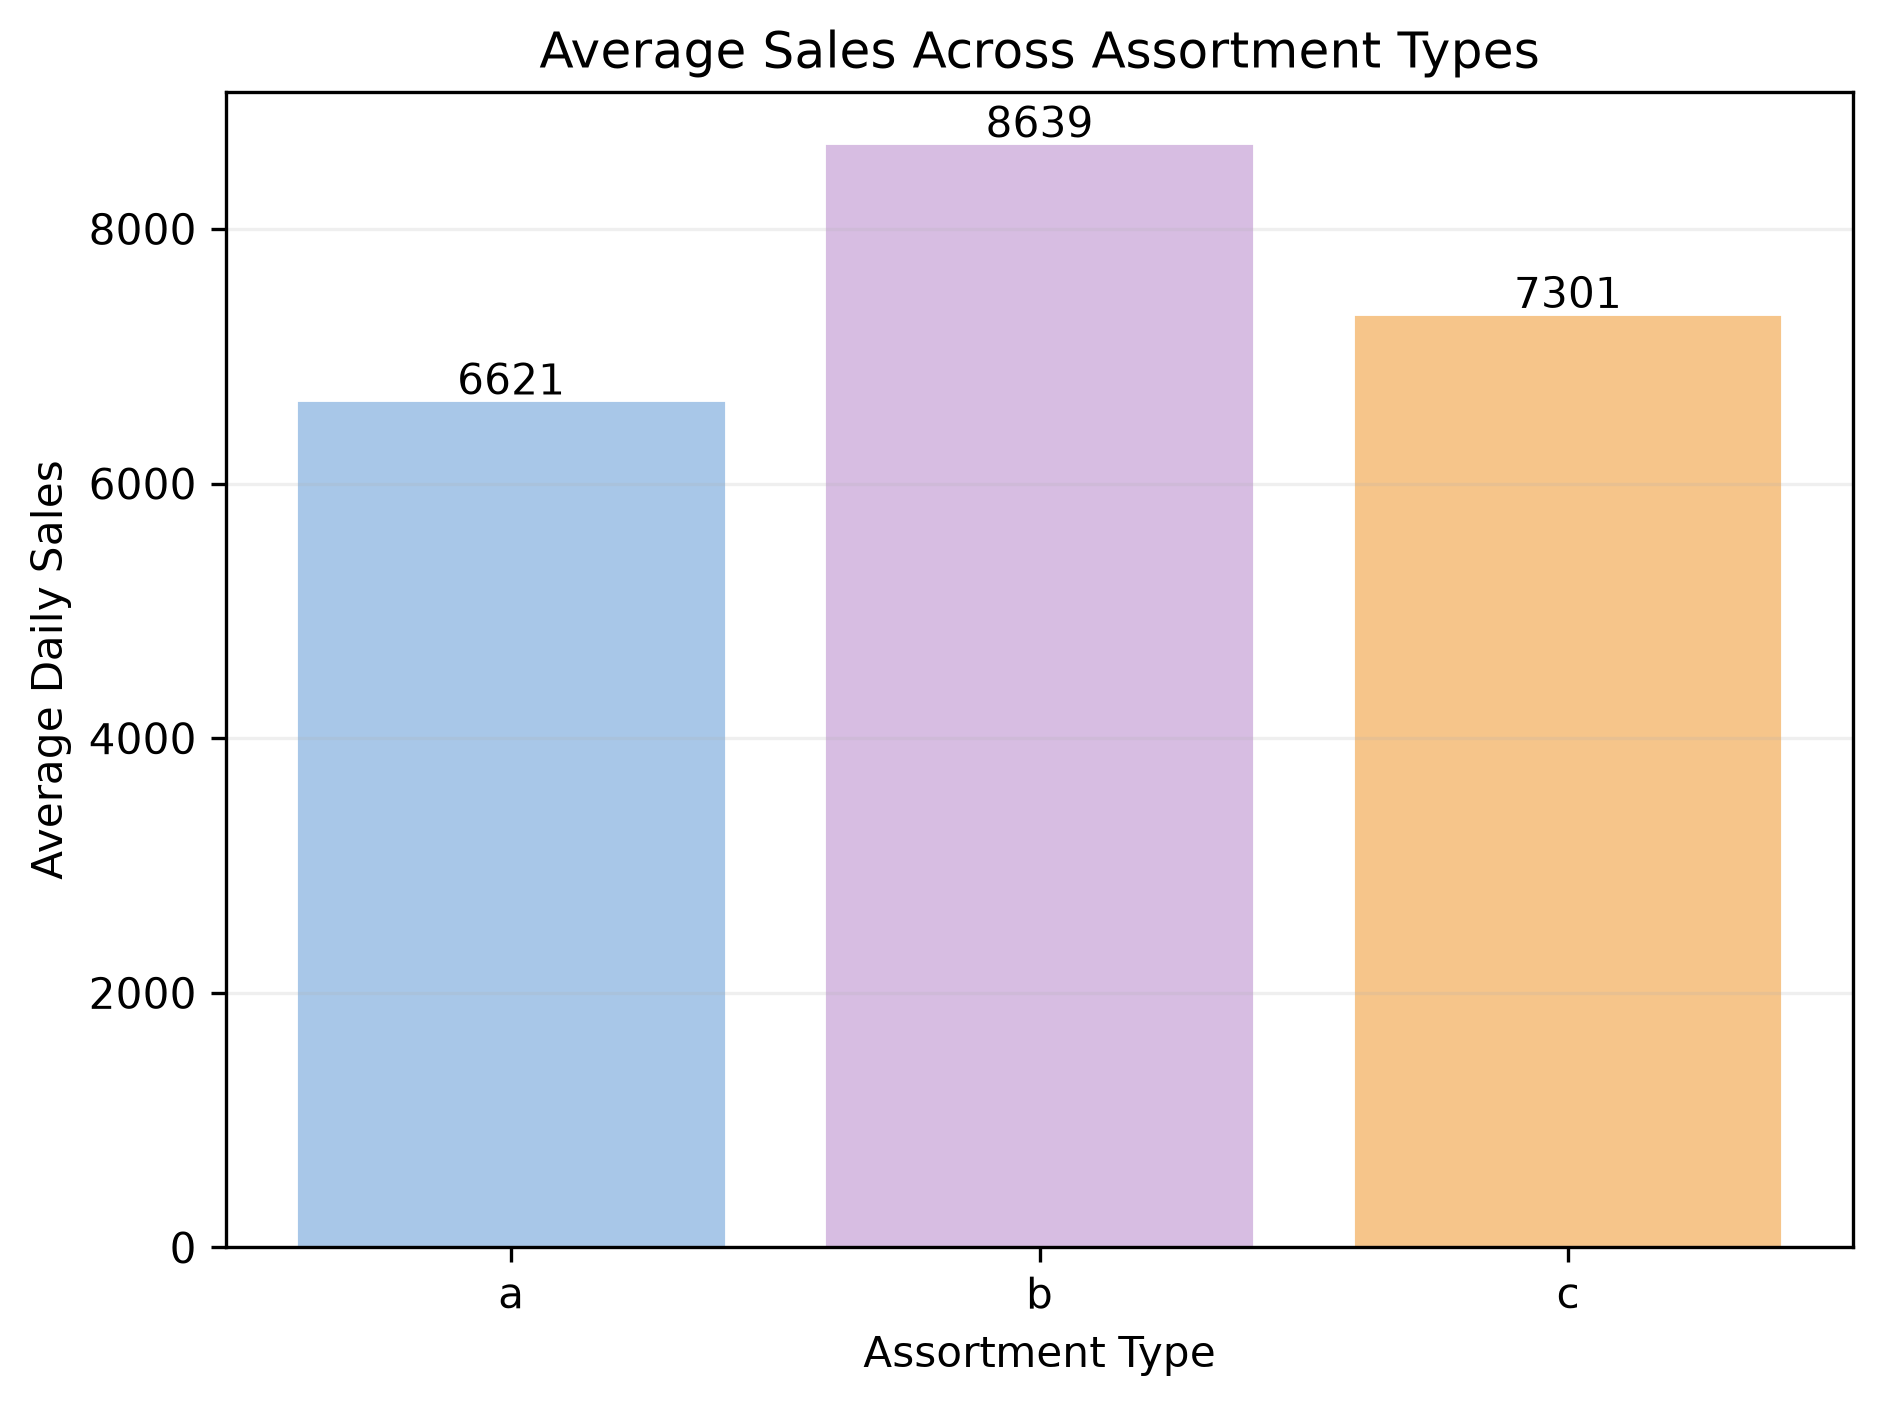

In [11]:
# ============================================================
# 9.2 Impact of Assortment Type on Sales Performance
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


# ------------------------------------------------------------
# 1. Load datasets
# ------------------------------------------------------------

train_clean = pd.read_csv(
    "../data/processed/train_clean.csv",
    dtype={
        "StateHoliday": "string"
    },
    low_memory=False
)


store_clean = pd.read_csv(
    "../data/processed/store_clean.csv",
    low_memory=False
)



# ------------------------------------------------------------
# 2. Merge store information
# ------------------------------------------------------------

df_store = train_clean.merge(
    store_clean,
    on="Store",
    how="left"
)



# ------------------------------------------------------------
# 3. Select operating-day observations
# ------------------------------------------------------------

df_open = df_store.loc[
    df_store["Open"] == 1
].copy()



# ------------------------------------------------------------
# 4. Assortment summary
# ------------------------------------------------------------

assortment_summary = (
    df_open
    .groupby("Assortment")
    .agg(
        Average_Sales=("Sales", "mean"),
        Median_Sales=("Sales", "median"),
        Number_of_Stores=("Store", "nunique"),
        Observations=("Sales", "count")
    )
)


print(
    assortment_summary
)



# ------------------------------------------------------------
# 5. Figure directory
# ------------------------------------------------------------

FIGURE_DIR = Path(
    "../outputs/figures"
)

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True
)



# ============================================================
# Figure 1: Store distribution
# ============================================================

plt.figure(
    figsize=(7,5),
    dpi=300
)


bars = plt.bar(
    assortment_summary.index,
    assortment_summary["Number_of_Stores"]
)


colors = [
    "#A8C7E8",
    "#D7BDE2",
    "#F6C58A"
]


for bar, color in zip(
    bars,
    colors
):
    bar.set_color(
        color
    )


for bar, value in zip(
    bars,
    assortment_summary["Number_of_Stores"]
):

    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f"{value}",
        ha="center",
        va="bottom"
    )


plt.xlabel(
    "Assortment Type"
)

plt.ylabel(
    "Number of Stores"
)

plt.title(
    "Distribution of Stores Across Assortment Types"
)


plt.grid(
    axis="y",
    alpha=0.2
)


plt.savefig(
    FIGURE_DIR / "store_distribution_assortment.png",
    bbox_inches="tight"
)


plt.show()



# ============================================================
# Figure 2: Average sales
# ============================================================

plt.figure(
    figsize=(7,5),
    dpi=300
)


bars = plt.bar(
    assortment_summary.index,
    assortment_summary["Average_Sales"]
)


for bar, color in zip(
    bars,
    colors
):
    bar.set_color(
        color
    )


for bar, value in zip(
    bars,
    assortment_summary["Average_Sales"]
):

    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f"{value:.0f}",
        ha="center",
        va="bottom"
    )


plt.xlabel(
    "Assortment Type"
)

plt.ylabel(
    "Average Daily Sales"
)

plt.title(
    "Average Sales Across Assortment Types"
)


plt.grid(
    axis="y",
    alpha=0.2
)


plt.savefig(
    FIGURE_DIR / "average_sales_assortment.png",
    bbox_inches="tight"
)


plt.show()


# 10. Impact of Competition Distance on Sales Performance

## Purpose

Store characteristics analysed previously describe the internal structure of stores.

However, external market competition may also influence retail performance.

`CompetitionDistance` represents the distance to the nearest competing store and can be considered an indicator of local competitive pressure.

This section investigates whether competition distance is associated with sales performance.

Understanding this relationship helps determine whether competition-related variables should be included in the later neural network model.

## Input

The analysis combines:

- `train_clean`
- `store_clean`

The datasets are merged through:


Only operating-day observations are considered:

$$
Open=1
$$

because closed stores contain structural zero sales.

The key variable is:

`CompetitionDistance`

## Method

Two analyses are performed:

1. Distribution analysis of competition distance;
2. Relationship analysis between competition distance and daily sales.

The Pearson correlation coefficient is calculated as:

$$
r =
\frac{
\sum_{i=1}^{n}(x_i-\bar{x})(y_i-\bar{y})
}
{
\sqrt{\sum_{i=1}^{n}(x_i-\bar{x})^2}
\sqrt{\sum_{i=1}^{n}(y_i-\bar{y})^2}
}
$$

where:

- \(x_i\) represents competition distance;
- \(y_i\) represents daily sales.

## Visualization

Two visualization methods are used:

1. Histogram:
   - to understand the distribution of competition distance;

2. Scatter plot:
   - to observe the relationship between competition distance and sales.

Because the dataset contains a large number of observations, random sampling is applied for scatter visualization.

The figures follow project requirements:

- clean SCI-style appearance;
- pastel colour design;
- accurate representation of data characteristics;
- saved under:


count    842206.000000
mean       5457.979627
std        7809.437311
min          20.000000
25%         710.000000
50%        2320.000000
75%        6890.000000
max       75860.000000
Name: CompetitionDistance, dtype: float64
Pearson correlation between Competition Distance and Sales: -0.0364


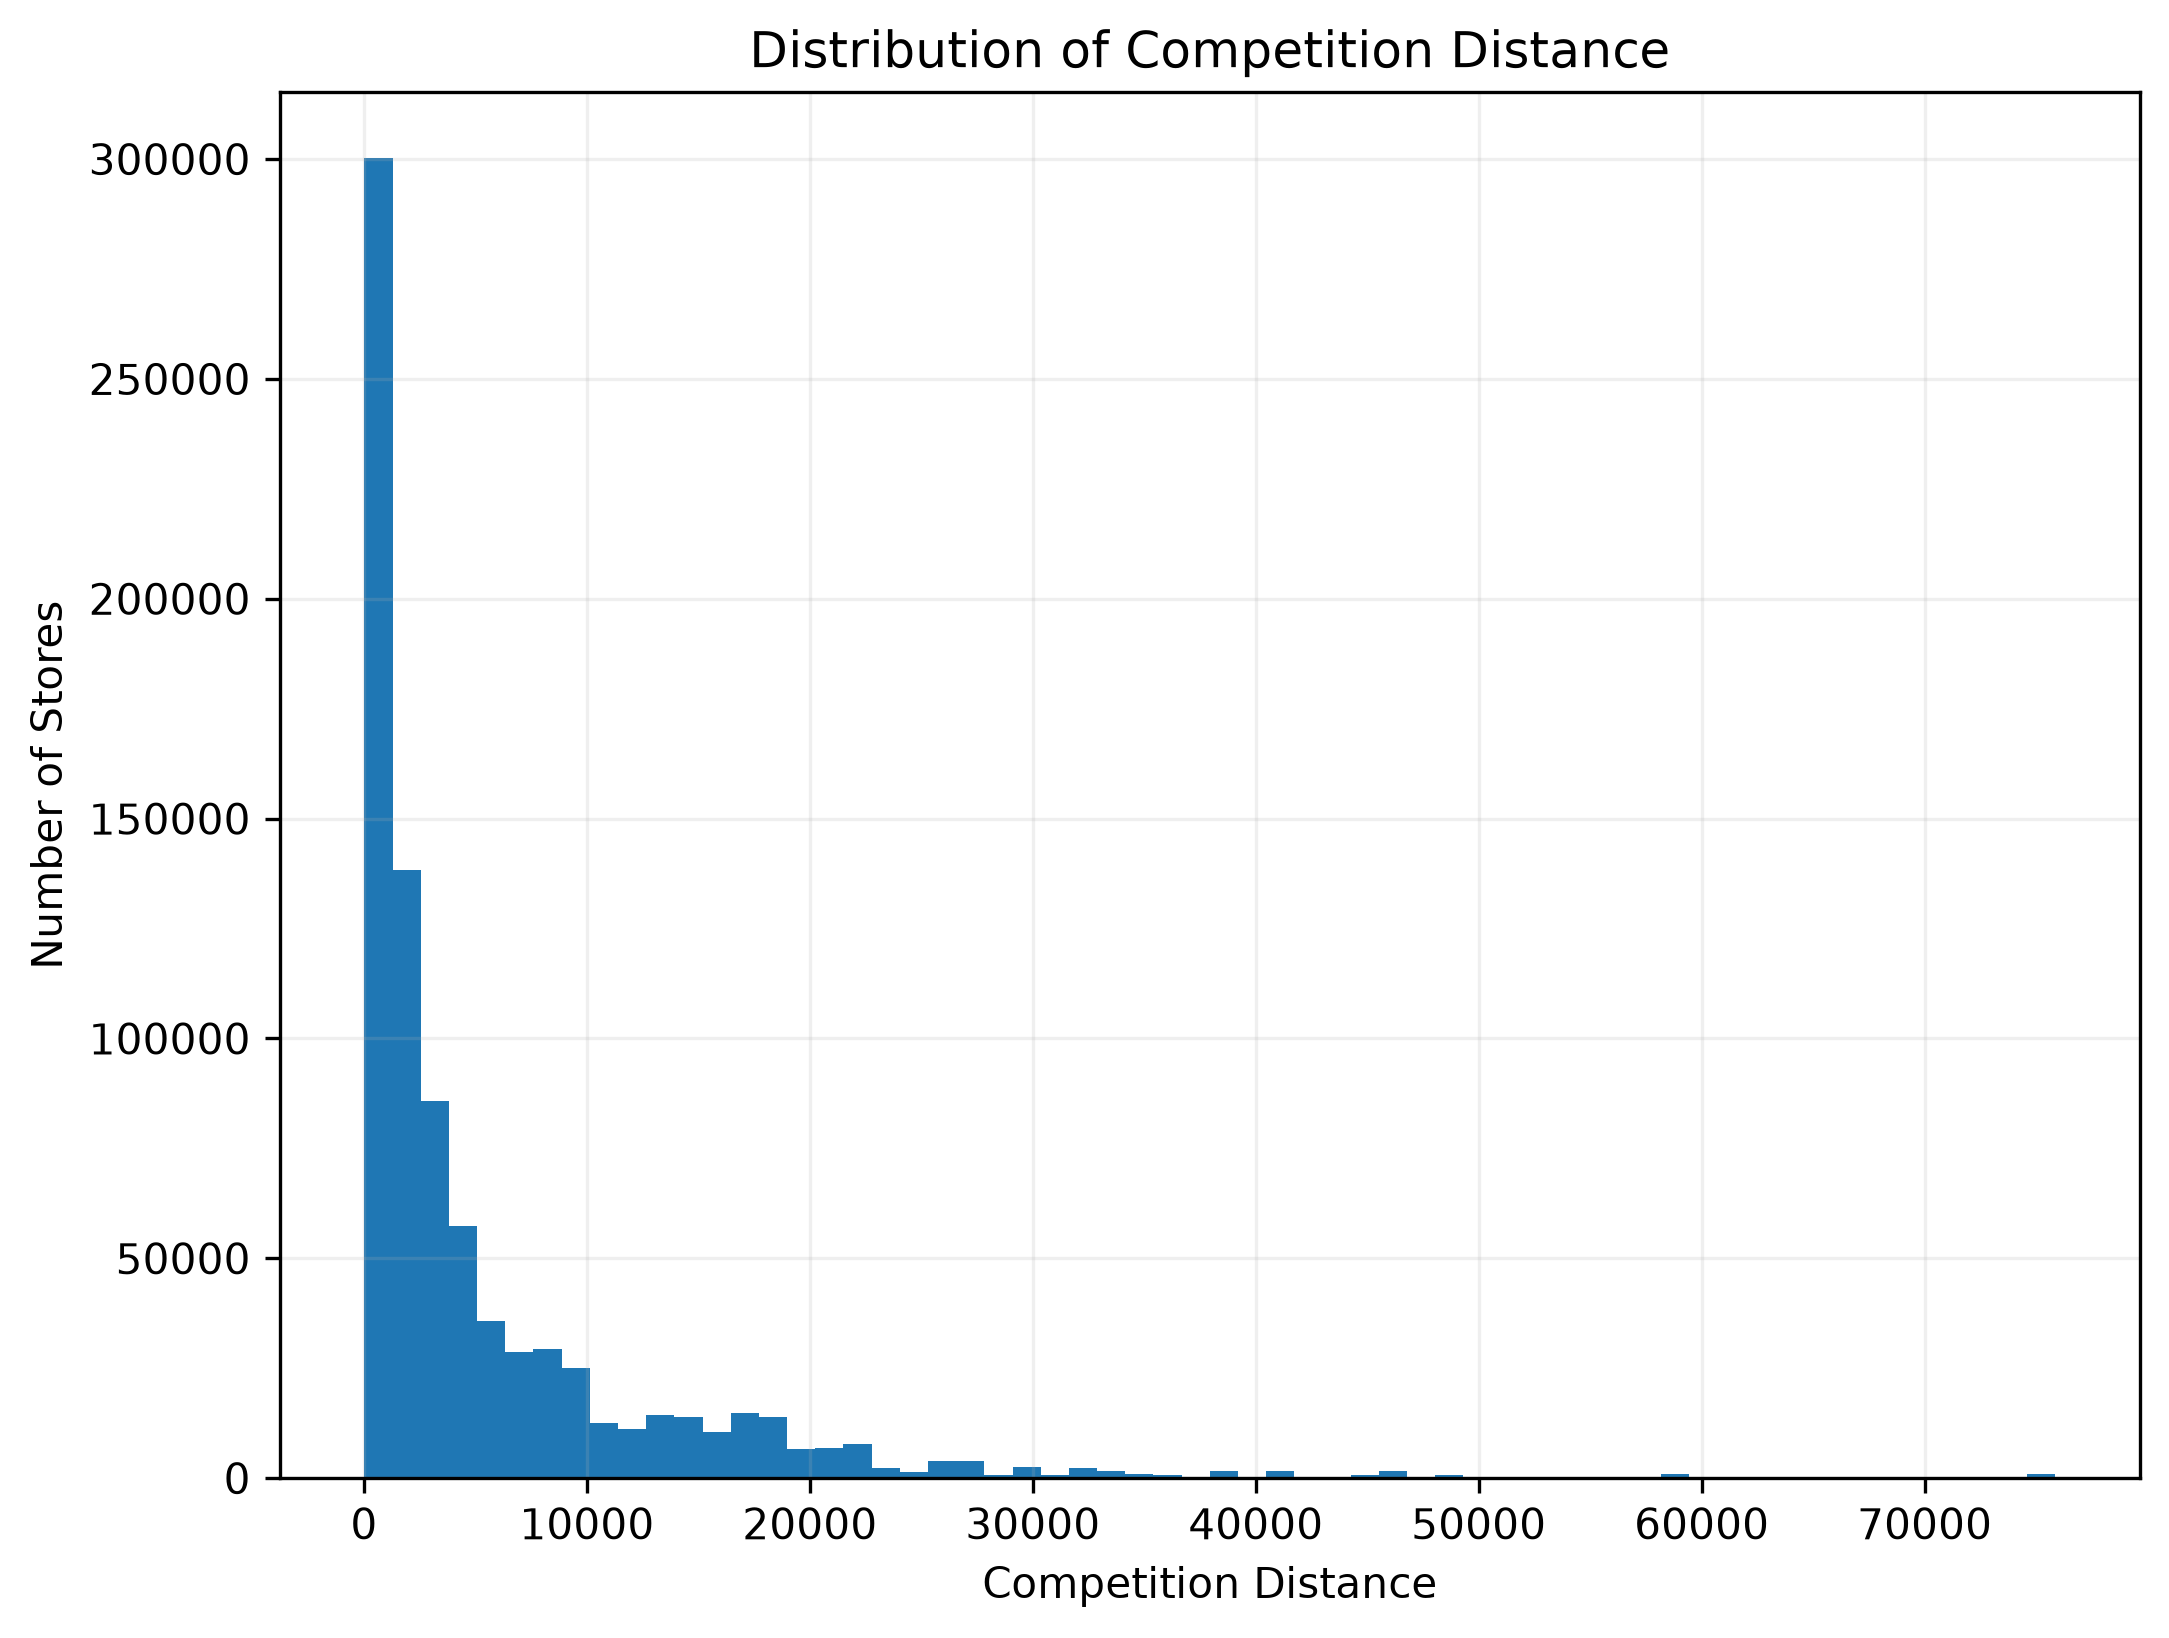

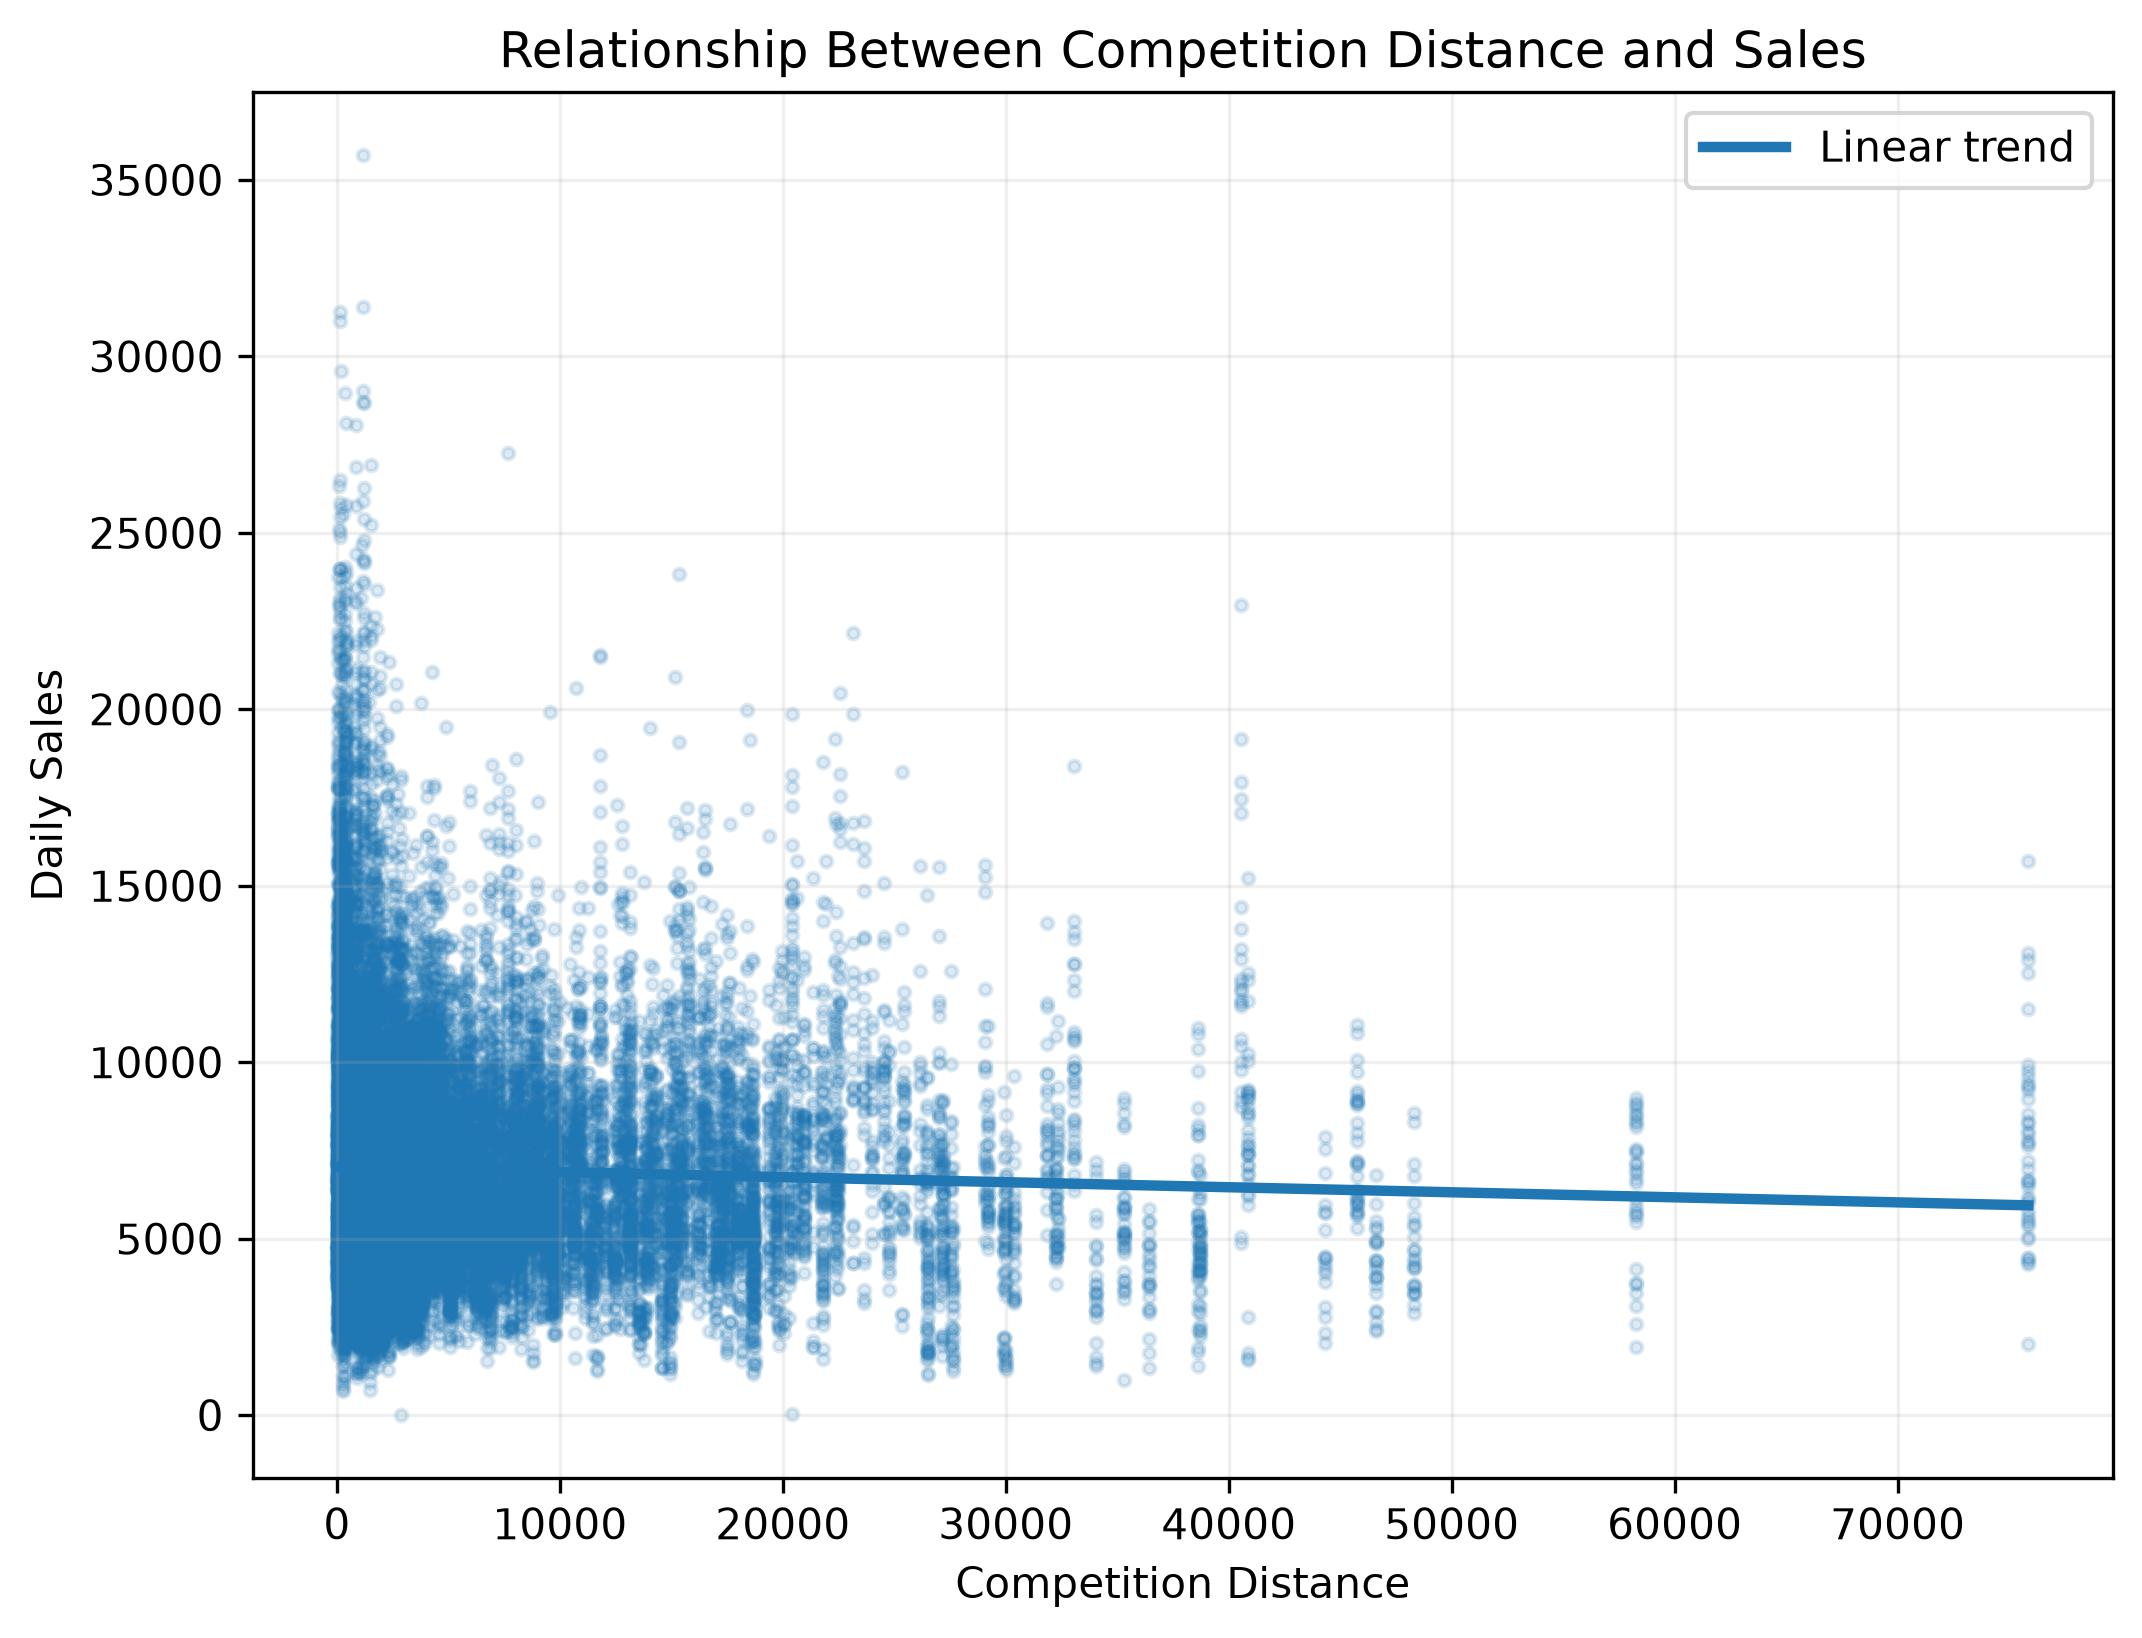

In [12]:
# ============================================================
# 10. Impact of Competition Distance on Sales Performance
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


# ------------------------------------------------------------
# 1. Load datasets
# ------------------------------------------------------------

train_clean = pd.read_csv(
    "../data/processed/train_clean.csv",
    dtype={
        "StateHoliday": "string"
    },
    low_memory=False
)


store_clean = pd.read_csv(
    "../data/processed/store_clean.csv",
    low_memory=False
)



# ------------------------------------------------------------
# 2. Merge datasets
# ------------------------------------------------------------

df_store = train_clean.merge(
    store_clean,
    on="Store",
    how="left"
)



# ------------------------------------------------------------
# 3. Select operating days
# ------------------------------------------------------------

df_open = df_store.loc[
    df_store["Open"] == 1
].copy()



# ------------------------------------------------------------
# 4. Remove missing competition distance
# ------------------------------------------------------------

competition_df = df_open.loc[
    df_open["CompetitionDistance"].notna()
].copy()



# ------------------------------------------------------------
# 5. Summary statistics
# ------------------------------------------------------------

print(
    competition_df[
        "CompetitionDistance"
    ].describe()
)



competition_corr = (
    competition_df[
        "CompetitionDistance"
    ]
    .corr(
        competition_df["Sales"],
        method="pearson"
    )
)


print(
    f"Pearson correlation between Competition Distance and Sales: "
    f"{competition_corr:.4f}"
)



# ------------------------------------------------------------
# 6. Figure directory
# ------------------------------------------------------------

FIGURE_DIR = Path(
    "../outputs/figures"
)

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True
)



# ============================================================
# Figure 1: Competition distance distribution
# ============================================================

plt.figure(
    figsize=(8,6),
    dpi=300
)


plt.hist(
    competition_df["CompetitionDistance"],
    bins=60
)


plt.xlabel(
    "Competition Distance"
)


plt.ylabel(
    "Number of Stores"
)


plt.title(
    "Distribution of Competition Distance"
)


plt.grid(
    alpha=0.2
)


plt.savefig(
    FIGURE_DIR / "competition_distance_distribution.png",
    bbox_inches="tight"
)


plt.show()



# ============================================================
# Figure 2: Competition distance vs Sales
# ============================================================

sample_size = min(
    30000,
    len(competition_df)
)


sample_df = competition_df.sample(
    n=sample_size,
    random_state=42
)



plt.figure(
    figsize=(8,6),
    dpi=300
)


plt.scatter(
    sample_df["CompetitionDistance"],
    sample_df["Sales"],
    alpha=0.15,
    s=8
)



# Linear trend

z = np.polyfit(
    sample_df["CompetitionDistance"],
    sample_df["Sales"],
    1
)


p = np.poly1d(z)


x_line = np.linspace(
    sample_df["CompetitionDistance"].min(),
    sample_df["CompetitionDistance"].max(),
    200
)


plt.plot(
    x_line,
    p(x_line),
    linewidth=2.5,
    color="#1F77B4",
    label="Linear trend"
)



plt.xlabel(
    "Competition Distance"
)


plt.ylabel(
    "Daily Sales"
)


plt.title(
    "Relationship Between Competition Distance and Sales"
)


plt.legend()


plt.grid(
    alpha=0.2
)



plt.savefig(
    FIGURE_DIR / "competition_distance_sales_scatter.png",
    bbox_inches="tight"
)


plt.show()

# 11. Relationship Between Promotion and Customer Traffic

## Purpose

Previous analyses showed that both customer traffic and promotion activity are important factors related to daily sales performance.

However, higher sales during promotion periods may result from different mechanisms:

1. attracting more customers;
2. increasing purchasing behaviour among existing customers;
3. a combination of both effects.

Since the dataset does not directly provide average basket size, analysing customer traffic changes under promotion conditions provides additional insight into how promotions influence sales.

## Input

The analysis uses:

- `train_clean`

Only operating-day observations are considered:

$$
Open=1
$$

because closed stores naturally have zero customers.

The key variables are:

- `Promo`
- `Customers`

where:

- `Promo=1`: promotion active;
- `Promo=0`: no promotion.

## Method

Customer distributions are compared between promotion and non-promotion periods.

The mean customer number is calculated as:

$$
\bar{C}
=
\frac{1}{n}
\sum_{i=1}^{n}C_i
$$

where:

- \(C_i\) represents daily customer numbers;
- \(n\) represents the number of observations.

## Visualization

A boxplot with mean markers is used to compare customer traffic distributions under different promotion conditions.

This visualization allows comparison of:

- median customer traffic;
- distribution spread;
- average customer level.

The figure follows project requirements:

- clean SCI-style appearance;
- pastel colours;
- clear interpretation;
- saved under:


        count        mean  median         std
Promo                                        
0      467496  696.856886   610.0  388.912683
1      376896  844.434401   757.0  401.242732


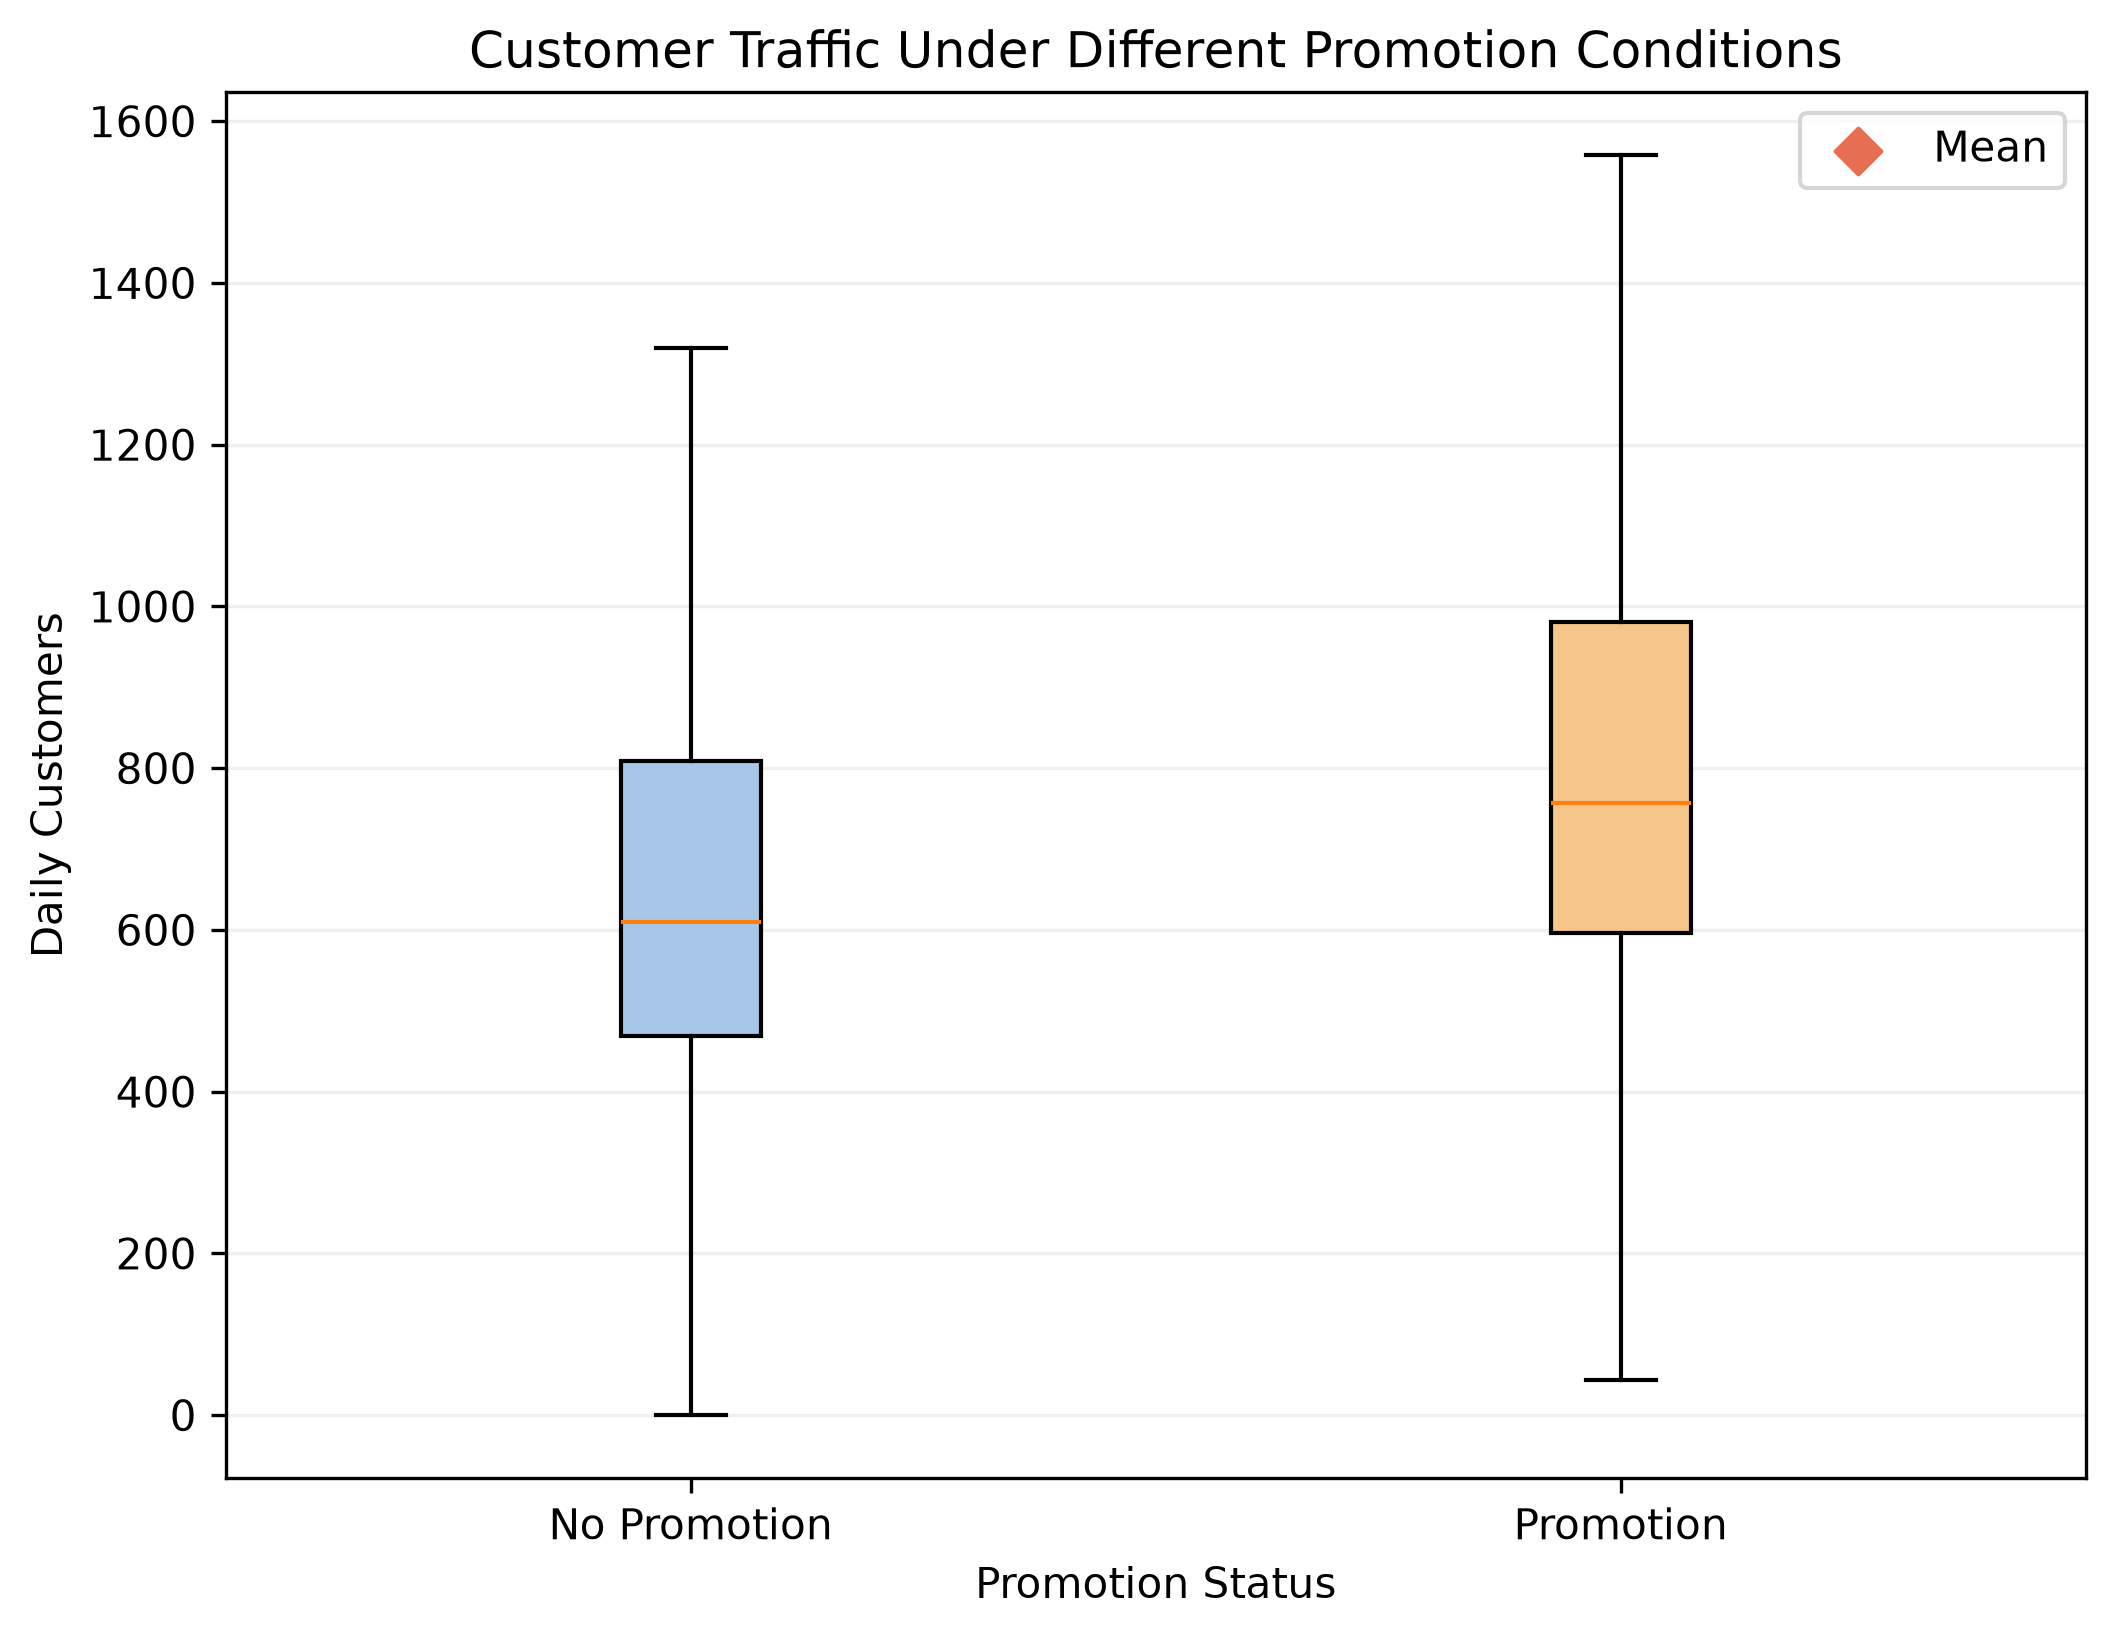

: 

In [ ]:
# ============================================================
# 11. Relationship Between Promotion and Customer Traffic
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


# ------------------------------------------------------------
# 1. Load cleaned dataset
# ------------------------------------------------------------

train_clean = pd.read_csv(
    "../data/processed/train_clean.csv",
    dtype={
        "StateHoliday": "string"
    },
    low_memory=False
)



# ------------------------------------------------------------
# 2. Select operating-day observations
# ------------------------------------------------------------

train_open = train_clean.loc[
    train_clean["Open"] == 1
].copy()



# ------------------------------------------------------------
# 3. Summary statistics
# ------------------------------------------------------------

promo_customer_summary = (
    train_open
    .groupby("Promo")["Customers"]
    .agg(
        [
            "count",
            "mean",
            "median",
            "std"
        ]
    )
)


print(
    promo_customer_summary
)



# ------------------------------------------------------------
# 4. Figure directory
# ------------------------------------------------------------

FIGURE_DIR = Path(
    "../outputs/figures"
)

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True
)



# ------------------------------------------------------------
# 5. Prepare groups
# ------------------------------------------------------------

customers_no_promo = train_open.loc[
    train_open["Promo"] == 0,
    "Customers"
]


customers_promo = train_open.loc[
    train_open["Promo"] == 1,
    "Customers"
]



# ------------------------------------------------------------
# 6. Boxplot
# ------------------------------------------------------------

plt.figure(
    figsize=(8,6),
    dpi=300
)


box = plt.boxplot(
    [
        customers_no_promo,
        customers_promo
    ],
    tick_labels=[
        "No Promotion",
        "Promotion"
    ],
    showfliers=False,
    patch_artist=True
)



# ------------------------------------------------------------
# 7. Pastel colors
# ------------------------------------------------------------

colors = [
    "#A8C7E8",
    "#F6C58A"
]


for patch, color in zip(
    box["boxes"],
    colors
):
    patch.set_facecolor(
        color
    )



# ------------------------------------------------------------
# 8. Mean markers
# ------------------------------------------------------------

means = [
    customers_no_promo.mean(),
    customers_promo.mean()
]


plt.scatter(
    [1,2],
    means,
    marker="D",
    s=60,
    color="#E76F51",
    label="Mean"
)



plt.xlabel(
    "Promotion Status"
)


plt.ylabel(
    "Daily Customers"
)


plt.title(
    "Customer Traffic Under Different Promotion Conditions"
)


plt.legend()


plt.grid(
    axis="y",
    alpha=0.2
)



# ------------------------------------------------------------
# 9. Save figure
# ------------------------------------------------------------

plt.savefig(
    FIGURE_DIR / "customers_promotion_boxplot.png",
    bbox_inches="tight"
)


plt.show()

# Summary of Exploratory Data Analysis

## Overview

This notebook performed exploratory data analysis on the cleaned Rossmann sales dataset.

The main objectives were:

1. Understand the statistical characteristics of daily sales;
2. Identify important temporal and operational factors related to sales variation;
3. Explore store-level and external competition factors;
4. Provide evidence for feature selection in the following feature engineering stage.

All analyses focused on understanding patterns and relationships in the data rather than establishing causal relationships.

---

## Main Findings

### 1. Sales and Customer Distribution Characteristics

The dataset contains:

- 1,017,209 daily store observations;
- 844,392 operating-day observations.

Because closed stores naturally generate zero sales and zero customers, operating-day observations (`Open = 1`) were mainly used for performance analysis.

Daily sales and customer numbers both showed positively skewed distributions.

For operating days:

- Average sales were higher than median sales;
- A small number of high-sales observations existed.

Potential extreme values were retained because they may represent genuine high-performing stores or high-demand periods rather than data errors.

---

### 2. Temporal Patterns

Sales performance showed clear temporal variation.

Daily and weekly analyses indicated that:

- Sales changed over time;
- Different weekdays exhibited different sales levels.

Therefore, time-related variables are expected to provide useful predictive information.

Potential features include:

- Year;
- Month;
- Week;
- Day of Week.

---

### 3. Relationship Between Customers and Sales

Customer traffic showed a strong positive relationship with sales.

The Pearson correlation coefficient between Customers and Sales was:

$$
r = 0.8236
$$

This indicates that customer volume is one of the most important factors associated with daily sales.

However, the scatter distribution also showed increasing variability at higher customer levels, suggesting that customer traffic alone cannot fully explain sales differences.

Therefore, additional operational and store-level features are required.

---

### 4. Promotion Effects

Promotion activity was strongly associated with higher sales performance.

The average daily sales were:

- No Promotion:

$$
5929.41
$$

- Promotion:

$$
8228.28
$$

Promotion periods showed approximately 38.8% higher average sales compared with non-promotion periods.

Further analysis indicated that promotion also affected customer traffic, suggesting that promotion may increase sales partly through attracting more customers.

The promotion variable should therefore be considered an important predictive feature.

---

### 5. Holiday Effects

Both state holidays and school holidays showed differences in sales performance.

The results suggest that holiday-related variables contain useful information about demand changes.

Potential features include:

- StateHoliday;
- SchoolHoliday.

---

### 6. Store Characteristics

Store-level characteristics influenced sales performance.

Analysis of:

- StoreType;
- Assortment;

showed differences in average sales among categories.

These variables describe relatively stable store characteristics and should be included as potential model features.

---

### 7. Competition Effects

Competition distance showed variation among stores.

The relationship between CompetitionDistance and Sales was not simply linear, suggesting that local competition effects may be influenced by other factors such as store location and market environment.

Competition-related variables should be retained for modelling rather than removed.

---

## Feature Engineering Implications

Based on the EDA results, the following variables are considered valuable candidates for the next feature engineering stage:

### Temporal Features

- Year;
- Month;
- Week;
- DayOfWeek.

### Customer and Promotion Features

- Customers;
- Promo.

### Holiday Features

- StateHoliday;
- SchoolHoliday.

### Store Characteristics

- StoreType;
- Assortment.

### Competition Features

- CompetitionDistance.

These variables will be further transformed and prepared in the next notebook before neural network modelling.

---

## Conclusion

The exploratory analysis demonstrates that Rossmann sales variation is influenced by multiple factors, including customer traffic, promotion activity, temporal patterns, store characteristics, and competitive environment.

No single variable can fully explain sales variation. Therefore, the subsequent feature engineering stage will combine temporal, operational, store-level, and external market information to construct comprehensive input features for the neural network prediction model.